# Nevada — Comprehensive Watershed Report

A complete hydrologic analysis of Nevada's Great Basin rivers: the driest
state in the nation, where every major river terminates in a desert sink
or lake — none reach the ocean. Snow-fed from the Sierra Nevada and Ruby
Mountains, these rivers sustain cities, agriculture, and terminal lake
ecosystems in one of North America's most water-stressed landscapes.

**Rivers:**
- Humboldt River near Carlin (Nevada's longest river — sinks into the Humboldt Sink)
- Truckee River at Reno (Lake Tahoe → Pyramid Lake, terminal)
- Carson River near Fort Churchill (→ Carson Sink, terminal)

**Data:** USGS NWIS daily-value discharge (federal public domain),
ONI (ENSO) and PDO climate indices.

**HUC4s:** 1501, 1503, 1602, 1604, 1605, 1606, 1704, 1705, 1712, 1808, 1809

In [1]:
# ── imports & paths ──────────────────────────────────────────────────────
import sys
from pathlib import Path

REPO = Path(".").resolve().parent
sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

from src import flow_metrics as fm
from tools.nwis_gauge import GaugeProvider
from tools.climate_index import ClimateIndexProvider
from tools.monthly_flow import MONTH_ABBR

NAS_ROOT = "/Volumes/home/data/hydro-art"
if not Path(NAS_ROOT).exists():
    NAS_ROOT = str(REPO / "cache")
    Path(NAS_ROOT).mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#07080c",
    "axes.facecolor": "#10121b",
    "axes.edgecolor": "#232838",
    "axes.labelcolor": "#e6ebf5",
    "text.color": "#e6ebf5",
    "xtick.color": "#8891a8",
    "ytick.color": "#8891a8",
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "font.size": 10,
})

# neon palette
CYAN = "#00ffff"
MAGENTA = "#ff4d9a"
LIME = "#00ff9c"
VIOLET = "#9d00ff"
AMBER = "#ff9c3a"
RED = "#ff4d5e"
COOL_BLUE = "#00e5ff"
MUTED = "#8891a8"
LIGHT = "#e6ebf5"

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

def complete_years(obs):
    """Filter to years where all 12 months are finite (no NaN gaps)."""
    return {y: v for y, v in obs.items() if np.all(np.isfinite(v))}

def save(fig, name):
    fig.savefig(FIGURES / f"nevada_{name}.png", bbox_inches="tight", pad_inches=0.3)

print("hydro-art Nevada Basin report — ready")

hydro-art Nevada Basin report — ready


## 1. Data Acquisition

Three USGS gauges span Nevada's major basins, chosen for record length
and hydrologic diversity:

| Gauge | Site | Drainage (mi²) | Record | Basin |
|-------|------|-----------------|--------|-------|
| Humboldt R. near Carlin | 10321000 | 5,930 | 1944–present | Great Basin (terminal) |
| Truckee R. at Reno | 10348000 | 1,067 | 1907–present | Truckee (→ Pyramid Lake) |
| Carson R. near Fort Churchill | 10312000 | 1,450 | 1911–present | Carson (→ Carson Sink) |

All three are **endorheic** — they drain into terminal sinks or lakes,
never reaching the ocean. The Truckee and Carson are Sierra Nevada
snowmelt rivers; the Humboldt is fed by the Ruby Mountains and
Independence Range in northeastern Nevada.

In [2]:
# ── gauge data ────────────────────────────────────────────────────────────
humboldt = GaugeProvider("10321000", NAS_ROOT)
humboldt_obs = humboldt.monthly_means(1944, 2024)
print(f"Humboldt River near Carlin: {humboldt.name}")
print(f"  {len(humboldt_obs)} years: {min(humboldt_obs)}–{max(humboldt_obs)}")

truckee = GaugeProvider("10348000", NAS_ROOT)
truckee_obs = truckee.monthly_means(1907, 2024)
print(f"\nTruckee River at Reno: {truckee.name}")
print(f"  {len(truckee_obs)} years: {min(truckee_obs)}–{max(truckee_obs)}")

carson = GaugeProvider("10312000", NAS_ROOT)
carson_obs = carson.monthly_means(1911, 2024)
print(f"\nCarson River near Fort Churchill: {carson.name}")
print(f"  {len(carson_obs)} years: {min(carson_obs)}–{max(carson_obs)}")

# ── climate indices ────────────────────────────────────────────────────────
oni_prov = ClimateIndexProvider("oni", NAS_ROOT)
pdo_prov = ClimateIndexProvider("pdo", NAS_ROOT)

oni = oni_prov.index_by_year(1900, 2024)
pdo = pdo_prov.index_by_year(1900, 2024)

print(f"\nONI (ENSO): {len(oni)} years")
print(f"PDO: {len(pdo)} years")

# Complete-year filtered copies
hum_c = complete_years(humboldt_obs)
tru_c = complete_years(truckee_obs)
car_c = complete_years(carson_obs)
print(f"\nComplete years — Humboldt: {len(hum_c)}, Truckee: {len(tru_c)}, Carson: {len(car_c)}")

Humboldt River near Carlin: USGS 10321000 HUMBOLDT RV NR CARLIN, NV
  81 years: 1944–2024

Truckee River at Reno: USGS 10348000 TRUCKEE RV AT RENO, NV
  102 years: 1907–2024

Carson River near Fort Churchill: USGS 10312000 CARSON RV NR FORT CHURCHILL, NV
  114 years: 1911–2024

ONI (ENSO): 75 years
PDO: 125 years

Complete years — Humboldt: 81, Truckee: 99, Carson: 113


In [3]:
# ── quick data summary table ──────────────────────────────────────────────
for name, obs in [("Humboldt", hum_c),
                   ("Truckee", tru_c),
                   ("Carson", car_c)]:
    years = sorted(obs.keys())
    annual = [float(np.nanmean(obs[y])) for y in years]
    print(f"{name:20s}  {years[0]}–{years[-1]}  "
          f"{len(years):>3d} yrs  "
          f"mean {np.mean(annual):>8,.0f} cfs  "
          f"peak {max(annual):>8,.0f} cfs")

Humboldt              1944–2024   81 yrs  mean      360 cfs  peak    1,692 cfs
Truckee               1907–2024   99 yrs  mean      676 cfs  peak    2,471 cfs
Carson                1912–2024  113 yrs  mean      376 cfs  peak    1,304 cfs


---
## 2. Year-over-Year Hydrographs

Every year's 12-month observed hydrograph overlaid. Nevada's snowmelt
regime is immediately visible: a sharp May–June peak as Sierra and Ruby
Mountain snowpack melts, followed by near-zero late-summer baseflow.
The Humboldt often runs dry by August in low-snow years.

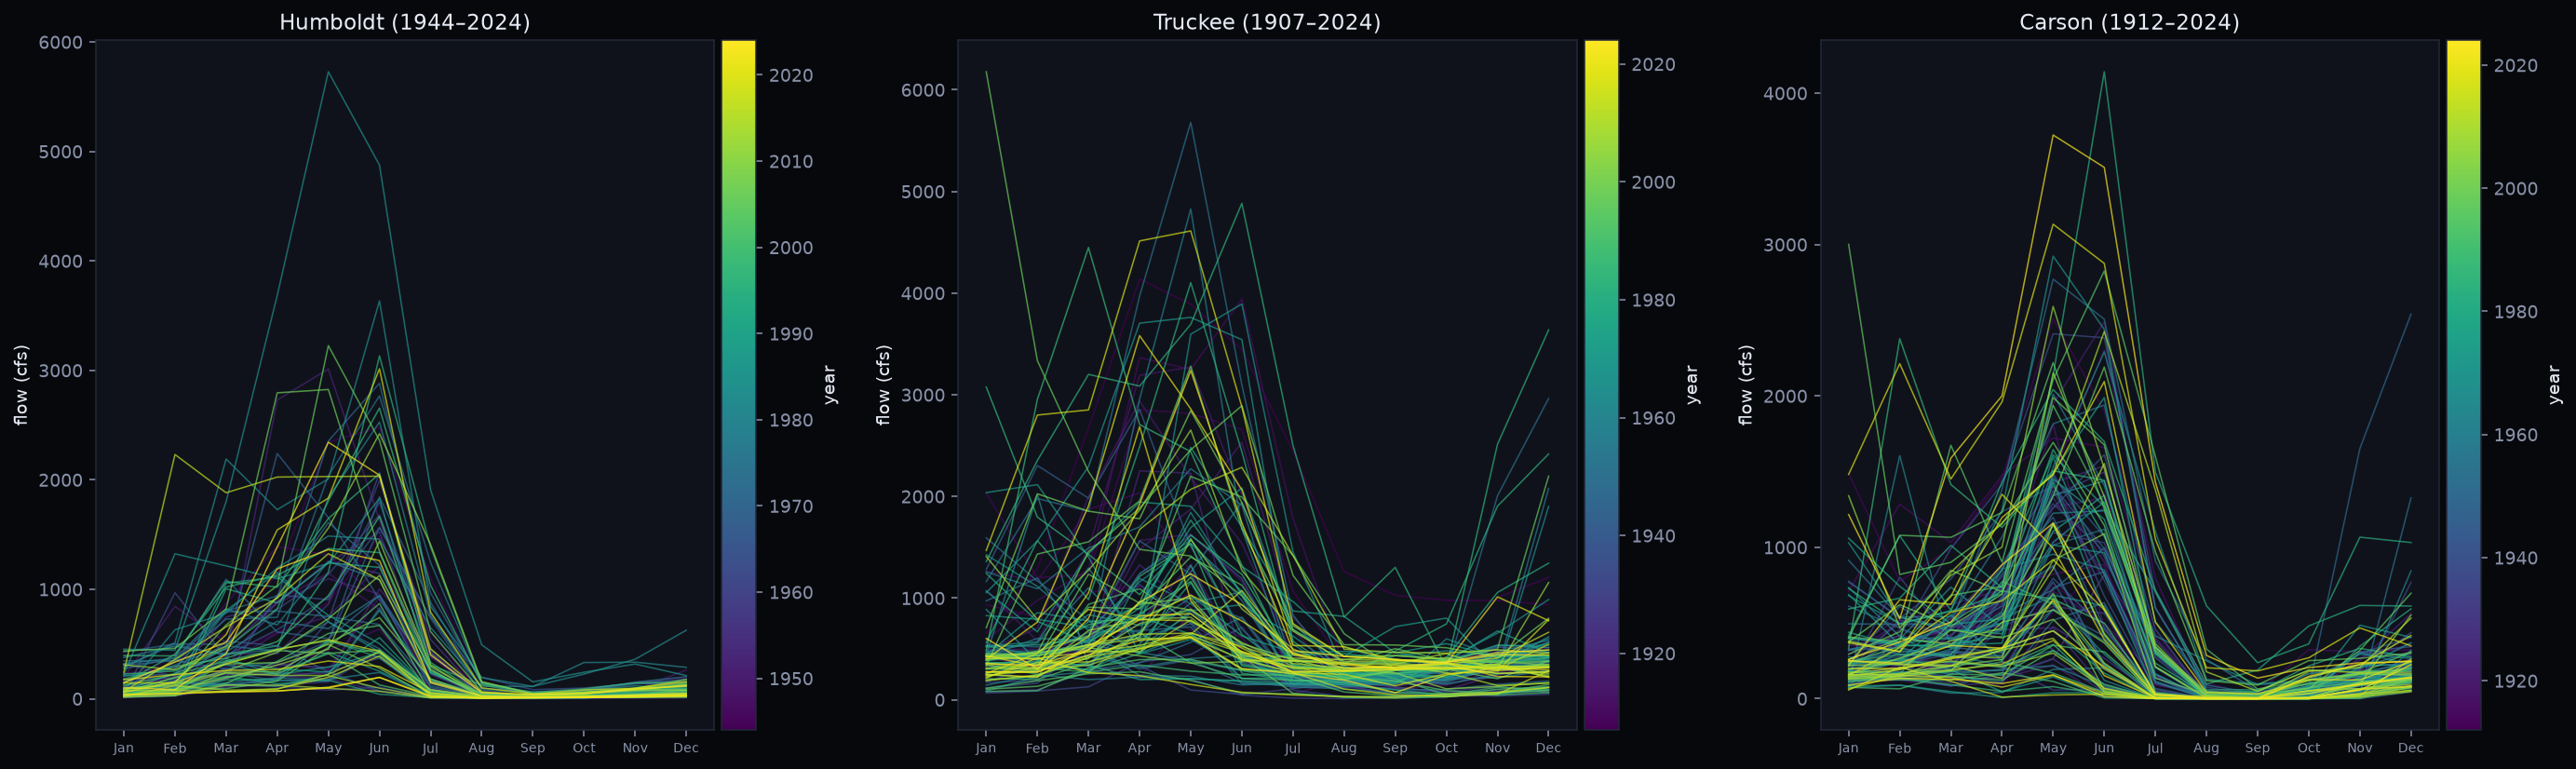

In [4]:
def plot_hydrographs(obs, title, ax):
    years = sorted(obs.keys())
    cmap = plt.get_cmap("viridis")
    span = max(years) - min(years) or 1
    for y in years:
        c = cmap((y - min(years)) / span)
        ax.plot(range(1, 13), obs[y], color=c, lw=0.8, alpha=0.7)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    sm = plt.cm.ScalarMappable(cmap="viridis",
        norm=plt.Normalize(vmin=min(years), vmax=max(years)))
    ax.figure.colorbar(sm, ax=ax, label="year", pad=0.01)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_hydrographs(hum_c, f"Humboldt ({min(hum_c)}–{max(hum_c)})", axes[0])
plot_hydrographs(tru_c, f"Truckee ({min(tru_c)}–{max(tru_c)})", axes[1])
plot_hydrographs(car_c, f"Carson ({min(car_c)}–{max(car_c)})", axes[2])
plt.tight_layout()
save(fig, "hydrographs")
plt.show()

---
## 3. Typical Year — Mean Monthly Hydrograph + Confidence Band

The average seasonal shape with P10–P90 spread. Nevada's rivers show
a classic arid snowmelt regime: near-zero winter flow (frozen or
snow-stored), explosive spring melt (May–June), and rapid recession
to baseflow by July. The Truckee, buffered by Lake Tahoe, has the
most stable baseflow; the Humboldt has the most extreme seasonality.

In [ ]:
def plot_typical_year(obs, title, ax):
    years = sorted(obs.keys())
    stack = np.array([obs[y] for y in years])
    mean = np.nanmean(stack, axis=0)
    p10 = np.nanpercentile(stack, 10, axis=0)
    p25 = np.nanpercentile(stack, 25, axis=0)
    p75 = np.nanpercentile(stack, 75, axis=0)
    p90 = np.nanpercentile(stack, 90, axis=0)
    m = range(1, 13)
    ax.fill_between(m, p10, p90, color=CYAN, alpha=0.08, label="P10–P90")
    ax.fill_between(m, p25, p75, color=CYAN, alpha=0.15, label="P25–P75")
    ax.plot(m, mean, color=CYAN, lw=2, label="mean")
    cot = fm.center_of_timing(mean)
    ax.axvline(cot, color=AMBER, ls="--", lw=1, label=f"center = {cot:.1f}")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_typical_year(hum_c, "Humboldt — Typical Year", axes[0])
plot_typical_year(tru_c, "Truckee — Typical Year", axes[1])
plot_typical_year(car_c, "Carson — Typical Year", axes[2])
plt.tight_layout()
save(fig, "typical_year")
plt.show()

---
## 4. Long-Record Trend — Annual Mean + Mann-Kendall / Sen's Slope

Is flow increasing or decreasing over the gauge record? The Truckee's
100+ year record captures the full arc of 20th-century water development:
upstream diversions, Newlands Project irrigation, and Pyramid Lake
restoration. The Carson record includes the Lahontan Reservoir era.

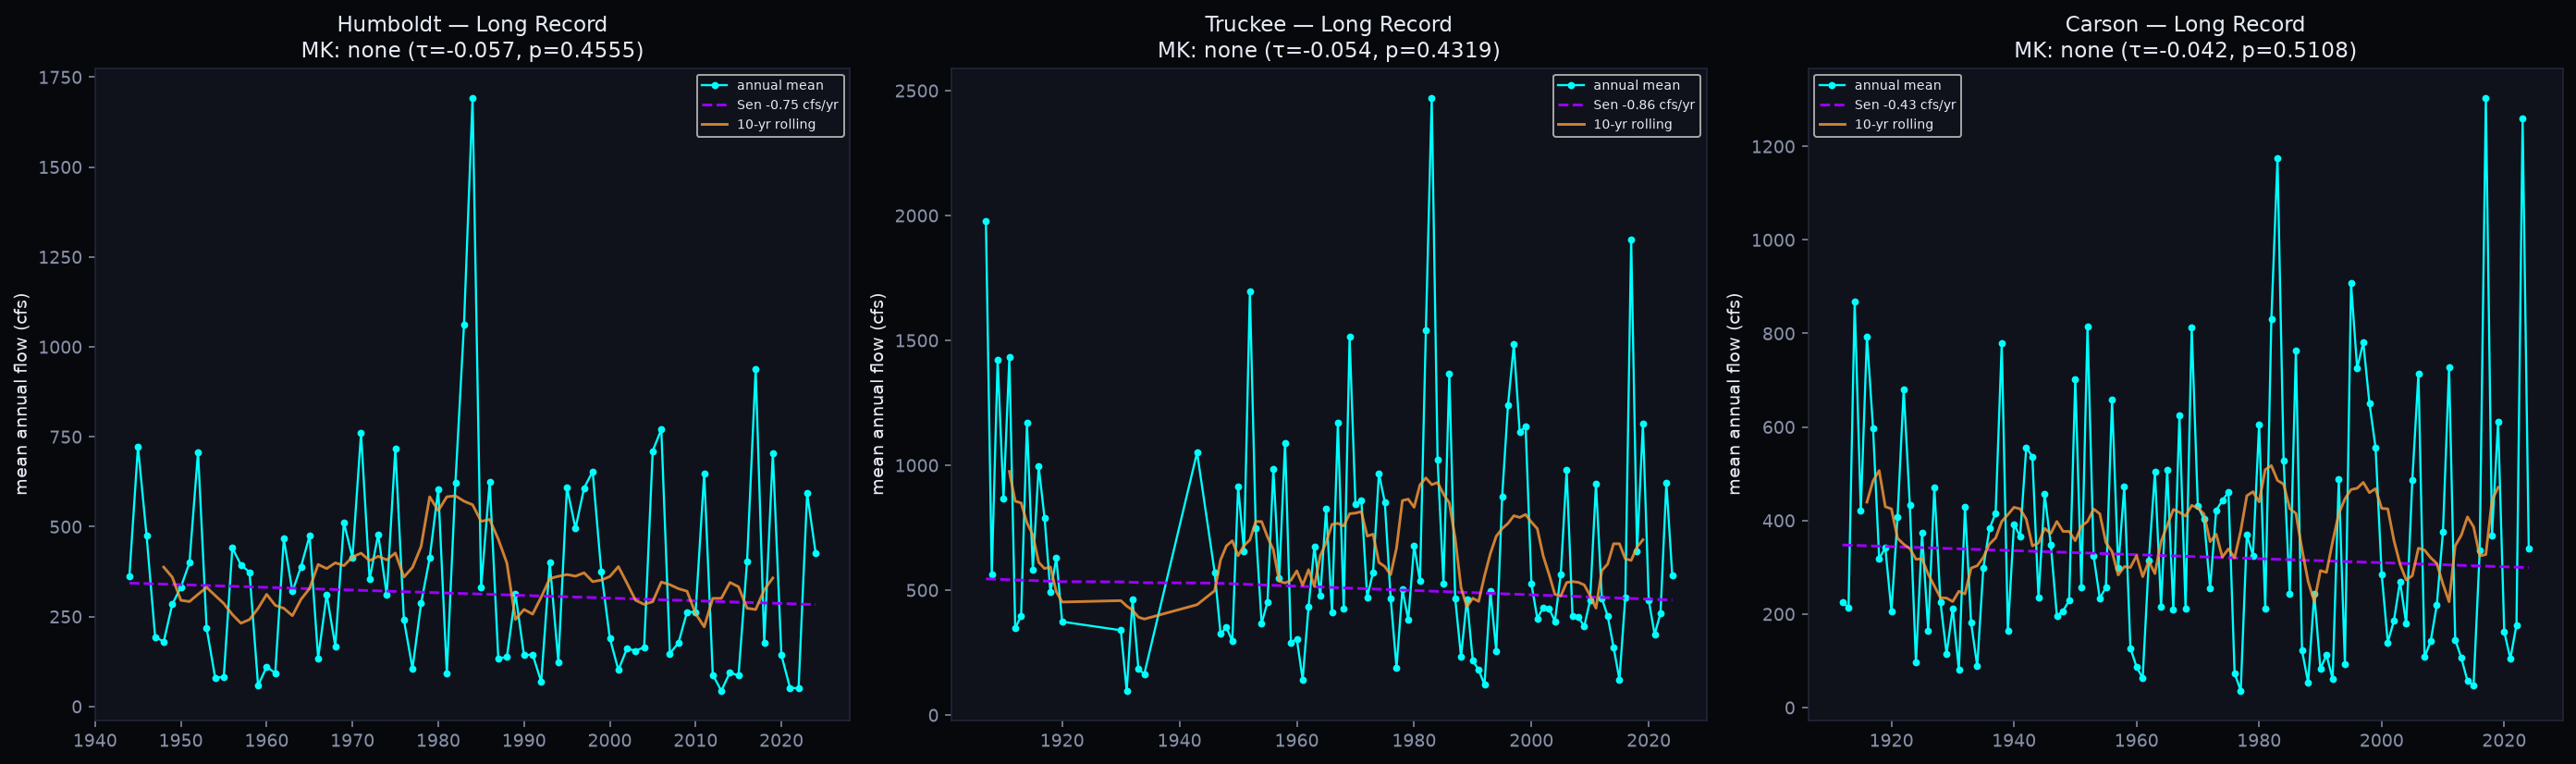

In [5]:
def plot_long_record(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    mk = fm.mann_kendall(annual)
    slope = fm.sens_slope(annual)
    x = np.arange(len(years))
    fit = np.median(annual) + slope * (x - np.median(x))
    ax.plot(years, annual, "o-", color=CYAN, lw=1.2, ms=3, label="annual mean")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.2f} cfs/yr")
    if len(years) >= 10:
        rm = np.convolve(annual, np.ones(10)/10, mode="valid")
        ax.plot(years[4:-5], rm, color=AMBER, lw=1.5, alpha=0.8, label="10-yr rolling")
    ax.set_ylabel("mean annual flow (cfs)")
    ax.set_title(f"{title}\nMK: {mk.trend} (τ={mk.tau:+.3f}, p={mk.p:.4f})")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_long_record(hum_c, "Humboldt — Long Record", axes[0])
plot_long_record(tru_c, "Truckee — Long Record", axes[1])
plot_long_record(car_c, "Carson — Long Record", axes[2])
plt.tight_layout()
save(fig, "long_record")
plt.show()

---
## 5. Summer Low-Flow Trend

Jul–Sep minimum — the drought-stress signal. In Nevada's terminal
basins, summer low flow is existential: it determines whether the
Humboldt reaches its sink, whether Pyramid Lake and Walker Lake
receive inflow, and whether the Lahontan cutthroat trout survive.

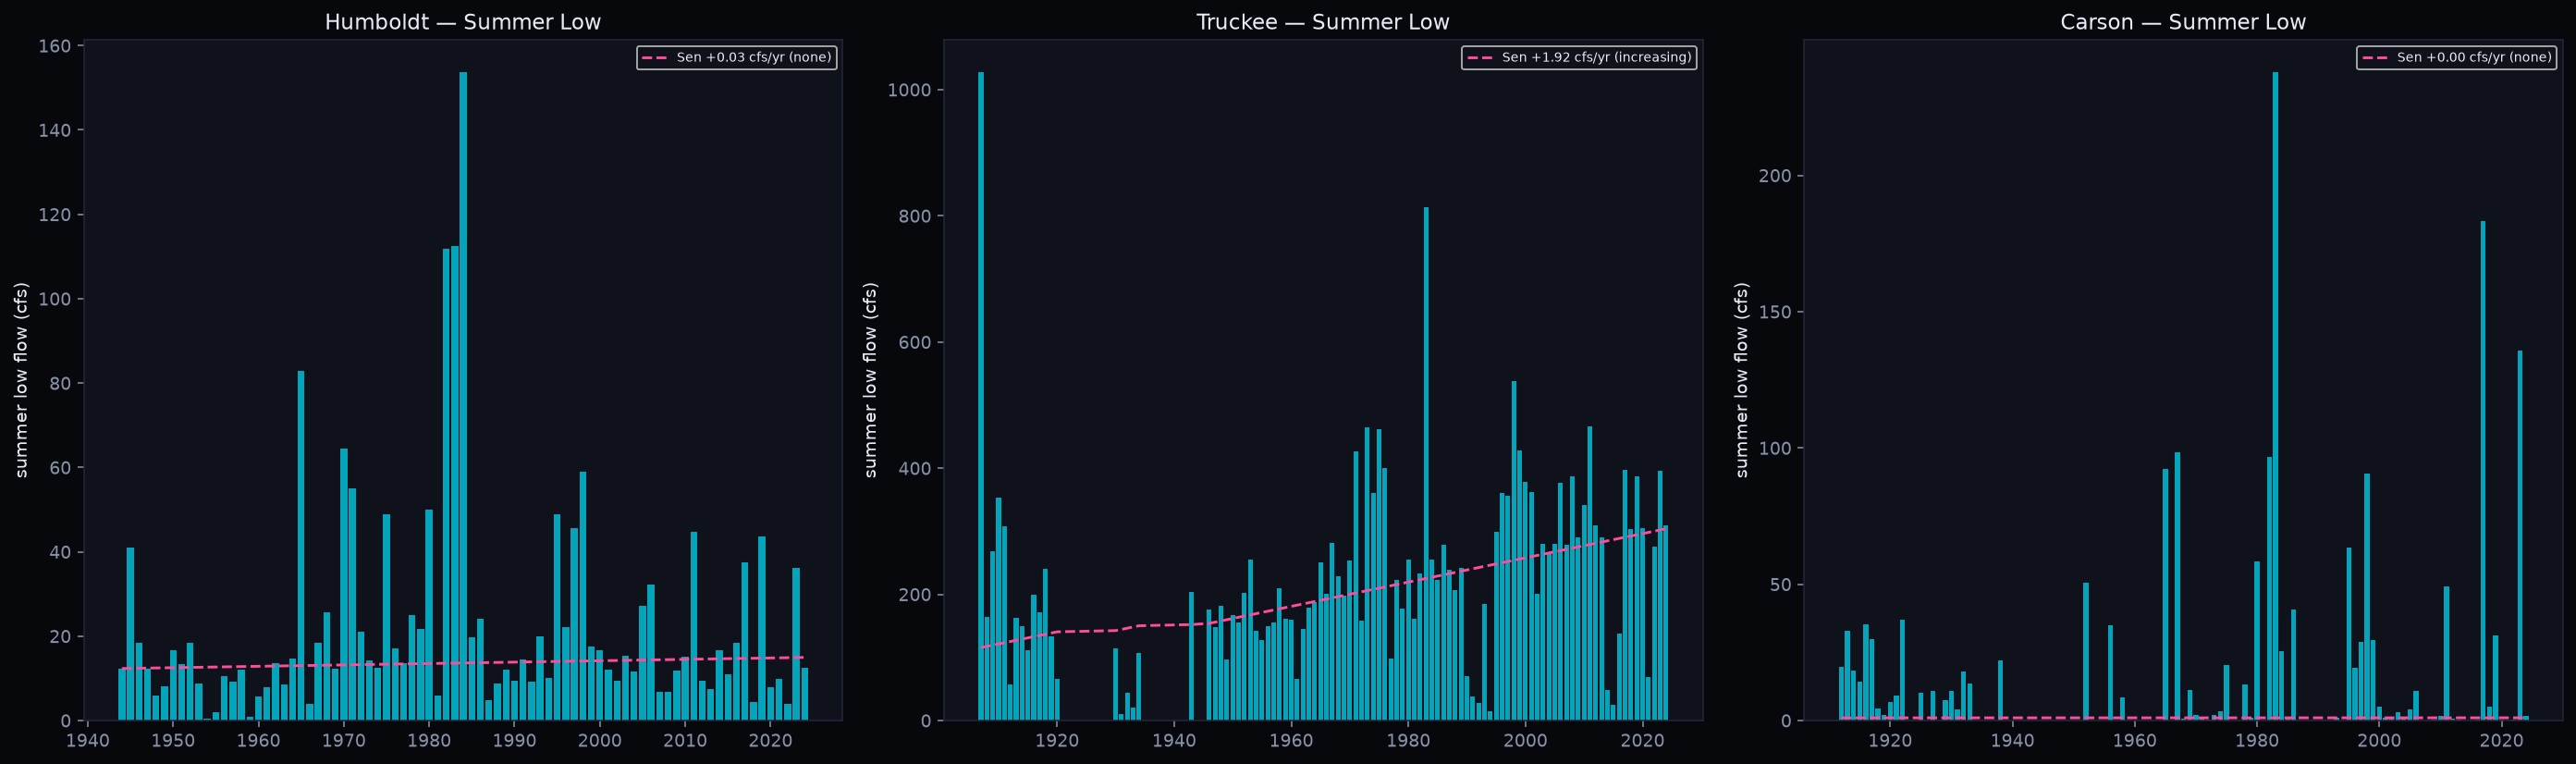

In [6]:
def plot_low_flow(obs, title, ax):
    years = sorted(obs.keys())
    low = np.array([float(np.nanmin(obs[y][6:9])) for y in years])
    mk = fm.mann_kendall(low)
    slope = fm.sens_slope(low)
    x = np.arange(len(years))
    fit = np.median(low) + slope * (x - np.median(x))
    ax.bar(years, low, color=COOL_BLUE, alpha=0.7, width=0.8)
    ax.plot(years, fit, "--", color=MAGENTA, lw=1.5,
            label=f"Sen {slope:+.2f} cfs/yr ({mk.trend})")
    ax.set_ylabel("summer low flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_low_flow(hum_c, "Humboldt — Summer Low", axes[0])
plot_low_flow(tru_c, "Truckee — Summer Low", axes[1])
plot_low_flow(car_c, "Carson — Summer Low", axes[2])
plt.tight_layout()
save(fig, "low_flow")
plt.show()

---
## 6. Peak Flow Trend

Annual maximum monthly flow — the flood/snowmelt signal. In Nevada,
peak flow is almost always May or June snowmelt. Rain-on-snow events
in the Sierra can produce exceptional peaks (1997, 2006, 2017).

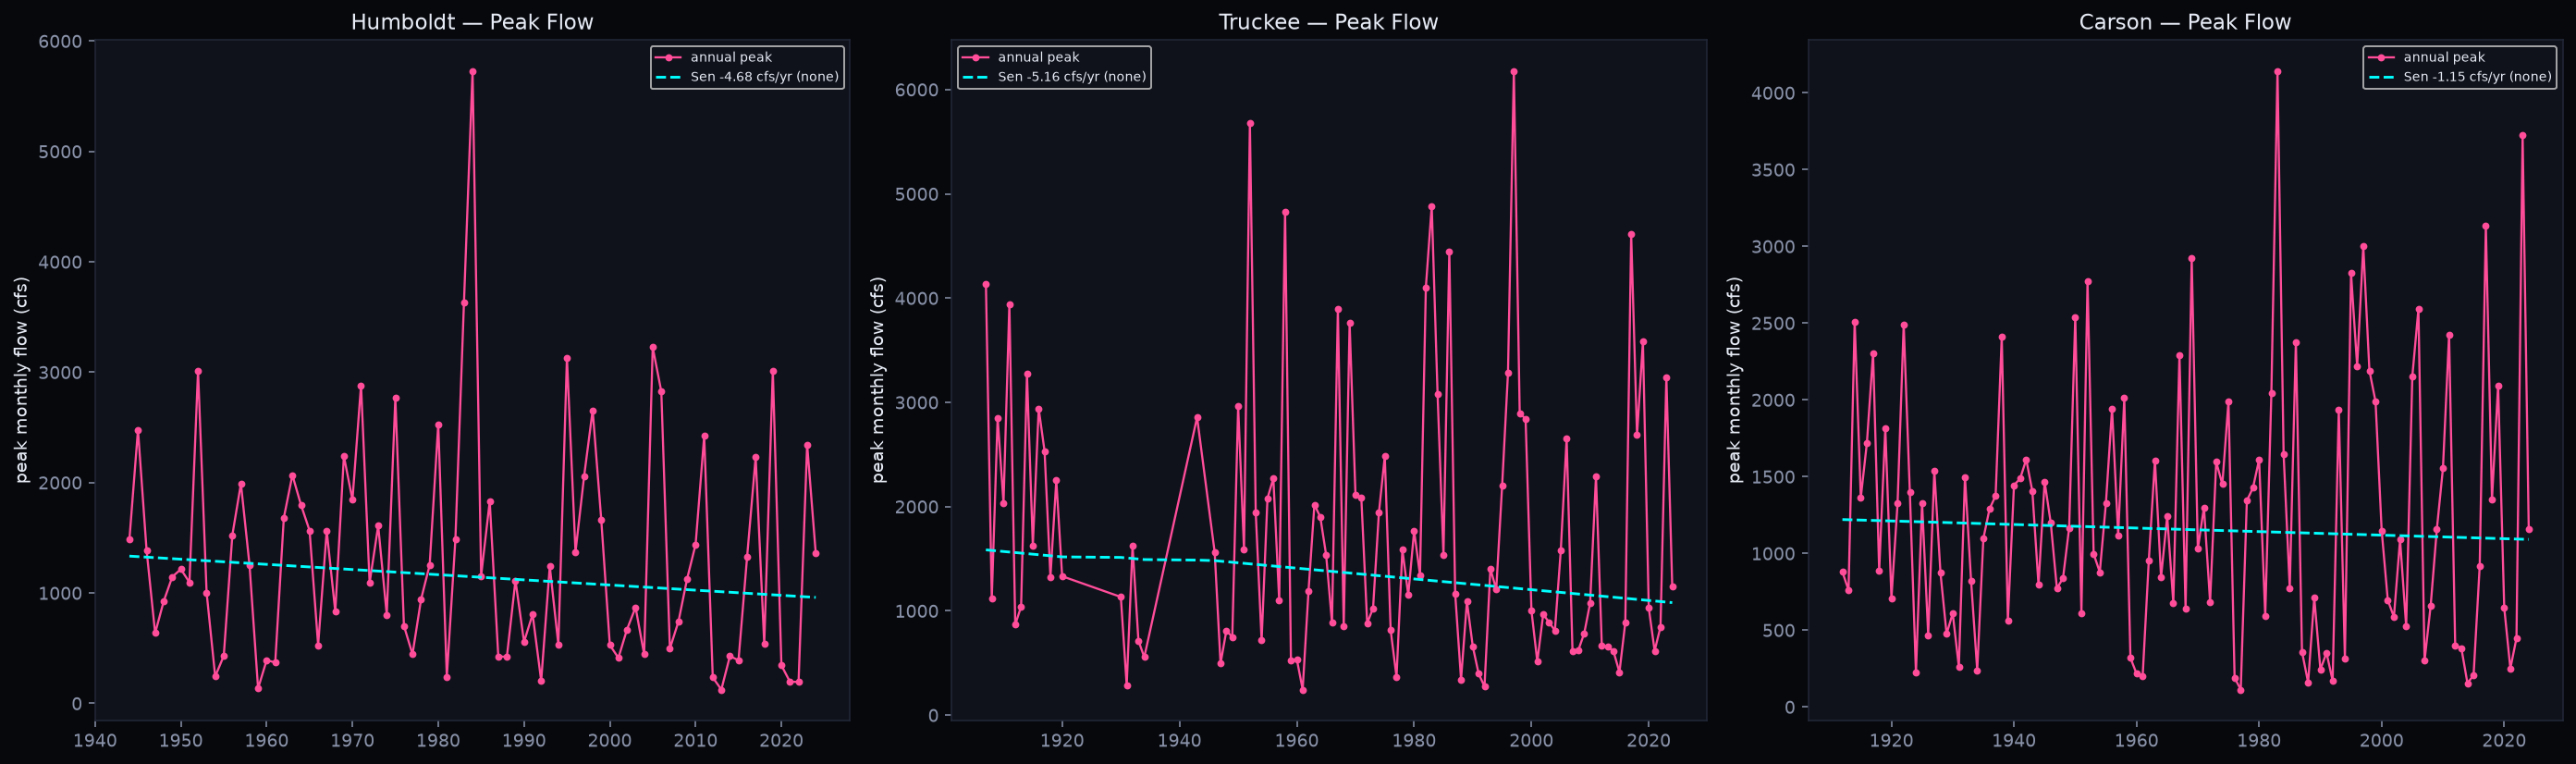

In [7]:
def plot_peak_flow(obs, title, ax):
    years = sorted(obs.keys())
    peak = np.array([float(np.nanmax(obs[y])) for y in years])
    mk = fm.mann_kendall(peak)
    slope = fm.sens_slope(peak)
    x = np.arange(len(years))
    fit = np.median(peak) + slope * (x - np.median(x))
    ax.plot(years, peak, "o-", color=MAGENTA, lw=1.2, ms=3, label="annual peak")
    ax.plot(years, fit, "--", color=CYAN, lw=1.5,
            label=f"Sen {slope:+.2f} cfs/yr ({mk.trend})")
    ax.set_ylabel("peak monthly flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_peak_flow(hum_c, "Humboldt — Peak Flow", axes[0])
plot_peak_flow(tru_c, "Truckee — Peak Flow", axes[1])
plot_peak_flow(car_c, "Carson — Peak Flow", axes[2])
plt.tight_layout()
save(fig, "peak_flow")
plt.show()

---
## 7. Timing Drift — Center of Timing per Year

Is the hydrograph's mass shifting earlier? In snowmelt-dominated
basins, warming advances the melt pulse. Nevada's rivers sit at the
southern edge of the snowmelt zone — they're among the most sensitive
to warming because a small temperature increase can flip snow to rain
at the elevation bands where most precipitation falls.

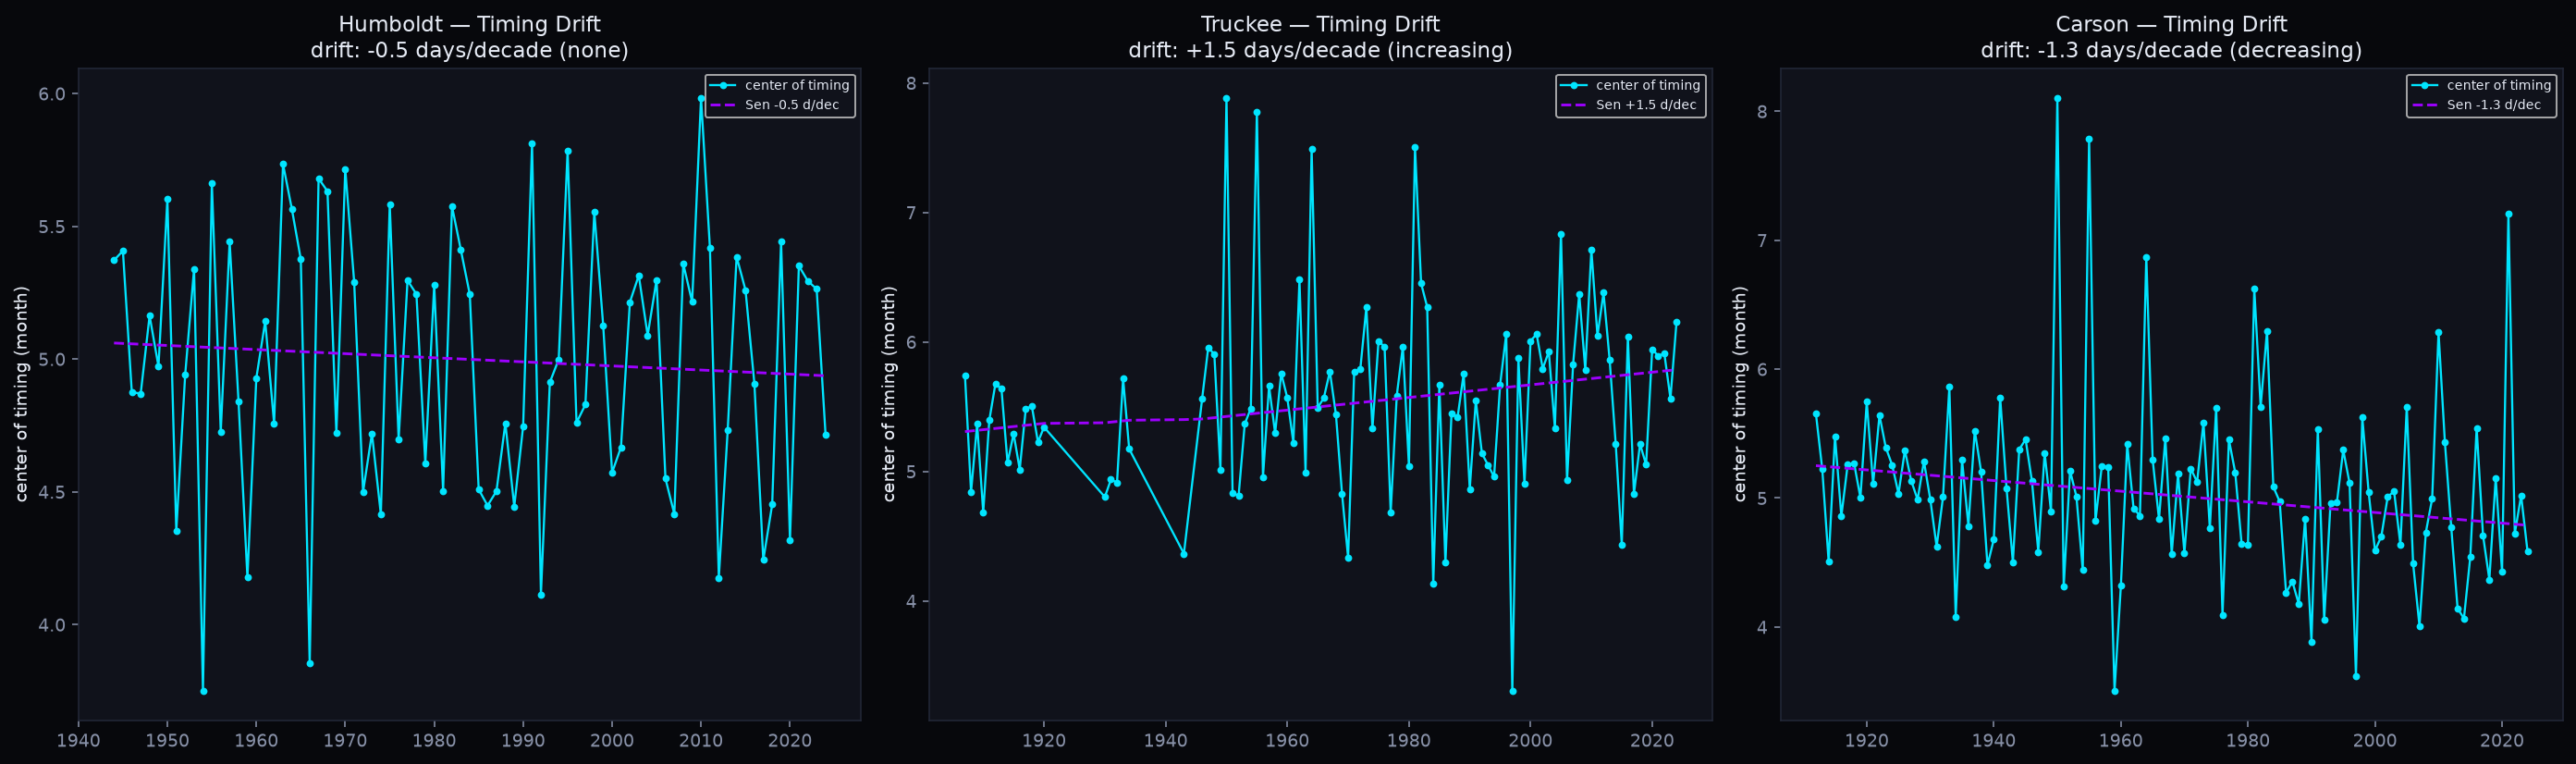

In [8]:
def plot_timing_drift(obs, title, ax):
    clean = complete_years(obs)
    tt = fm.center_of_timing_trend(clean)
    years = list(tt.years)
    centers = np.array(tt.center_months)
    ax.plot(years, centers, "o-", color=COOL_BLUE, lw=1.2, ms=3, label="center of timing")
    x = np.arange(len(years))
    fit = np.median(centers) + tt.slope_months_per_year * (x - np.median(x))
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {tt.days_per_decade:+.1f} d/dec")
    ax.set_ylabel("center of timing (month)")
    ax.set_title(f"{title}\ndrift: {tt.days_per_decade:+.1f} days/decade ({tt.trend})")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_timing_drift(hum_c, "Humboldt — Timing Drift", axes[0])
plot_timing_drift(tru_c, "Truckee — Timing Drift", axes[1])
plot_timing_drift(car_c, "Carson — Timing Drift", axes[2])
plt.tight_layout()
save(fig, "timing_drift")
plt.show()

---
## 8. ENSO Teleconnection — Peak Flow vs. ONI

Nevada sits in a strong ENSO teleconnection zone. El Niño winters
drive the Pacific jet south, delivering heavy Sierra snowpack and
wet conditions across the Great Basin. La Niña winters are typically
dry. This is one of the strongest ENSO signals in the continental US.

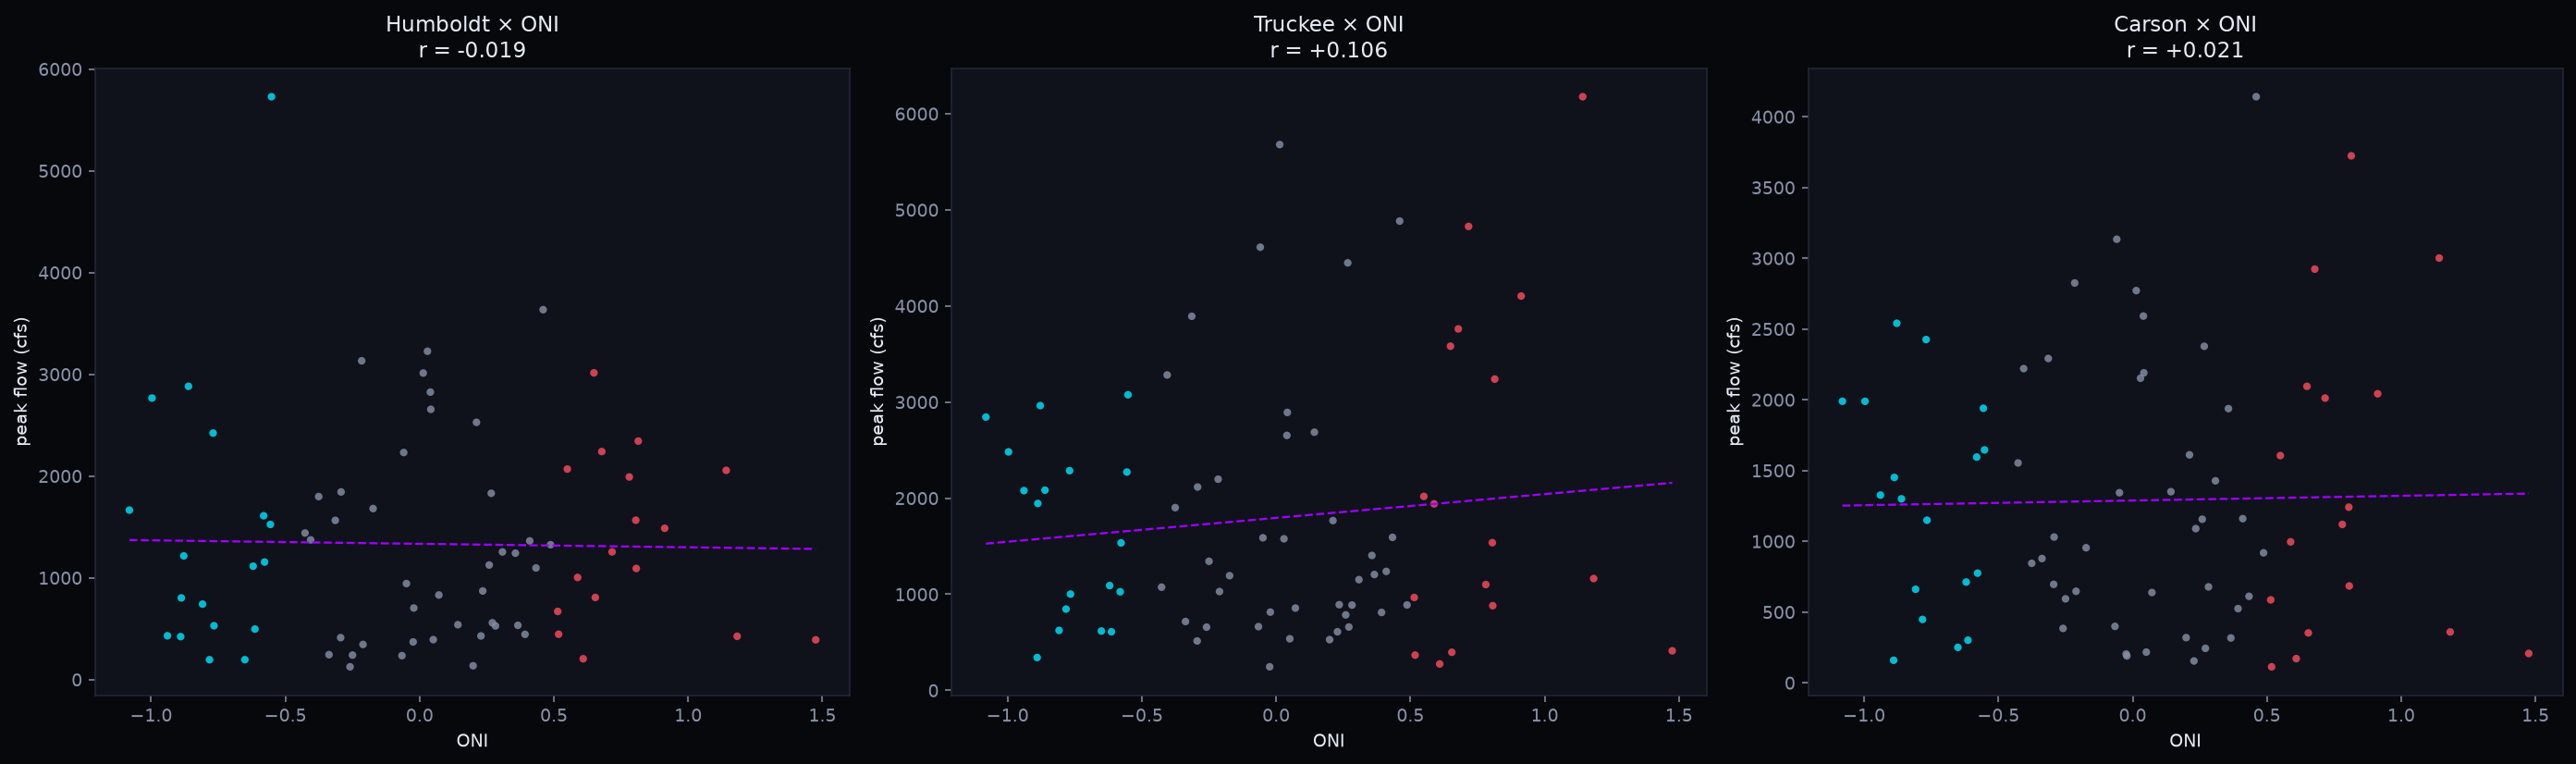

In [9]:
def plot_enso(obs, index_by_year, title, ax, *, index_name="ONI"):
    years = sorted(obs.keys())
    peak_by_year = {y: float(np.nanmax(obs[y])) for y in years}
    common = sorted(set(peak_by_year) & set(index_by_year))
    if len(common) < 10:
        ax.text(0.5, 0.5, "insufficient overlap", ha="center", va="center",
                transform=ax.transAxes, color=MUTED)
        return
    xs = [index_by_year[y] for y in common]
    ys = [peak_by_year[y] for y in common]
    r = fm.correlate(peak_by_year, index_by_year)
    colors = [RED if x > 0.5 else COOL_BLUE if x < -0.5 else MUTED for x in xs]
    ax.scatter(xs, ys, c=colors, s=18, alpha=0.8, edgecolors="none")
    z = np.polyfit(xs, ys, 1)
    xr = np.linspace(min(xs), max(xs), 50)
    ax.plot(xr, np.polyval(z, xr), "--", color=VIOLET, lw=1.2)
    ax.set_xlabel(index_name)
    ax.set_ylabel("peak flow (cfs)")
    ax.set_title(f"{title}\nr = {r:+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_enso(hum_c, oni, "Humboldt × ONI", axes[0])
plot_enso(tru_c, oni, "Truckee × ONI", axes[1])
plot_enso(car_c, oni, "Carson × ONI", axes[2])
plt.tight_layout()
save(fig, "enso")
plt.show()

---
## 9. ENSO Composite Hydrographs

Average seasonal shape for El Niño, neutral, and La Niña years.
In Nevada, the El Niño composite should show dramatically higher
spring peaks — the wet El Niño winters of 1982–83, 1997–98, and
2016–17 produced some of the largest flows on record.

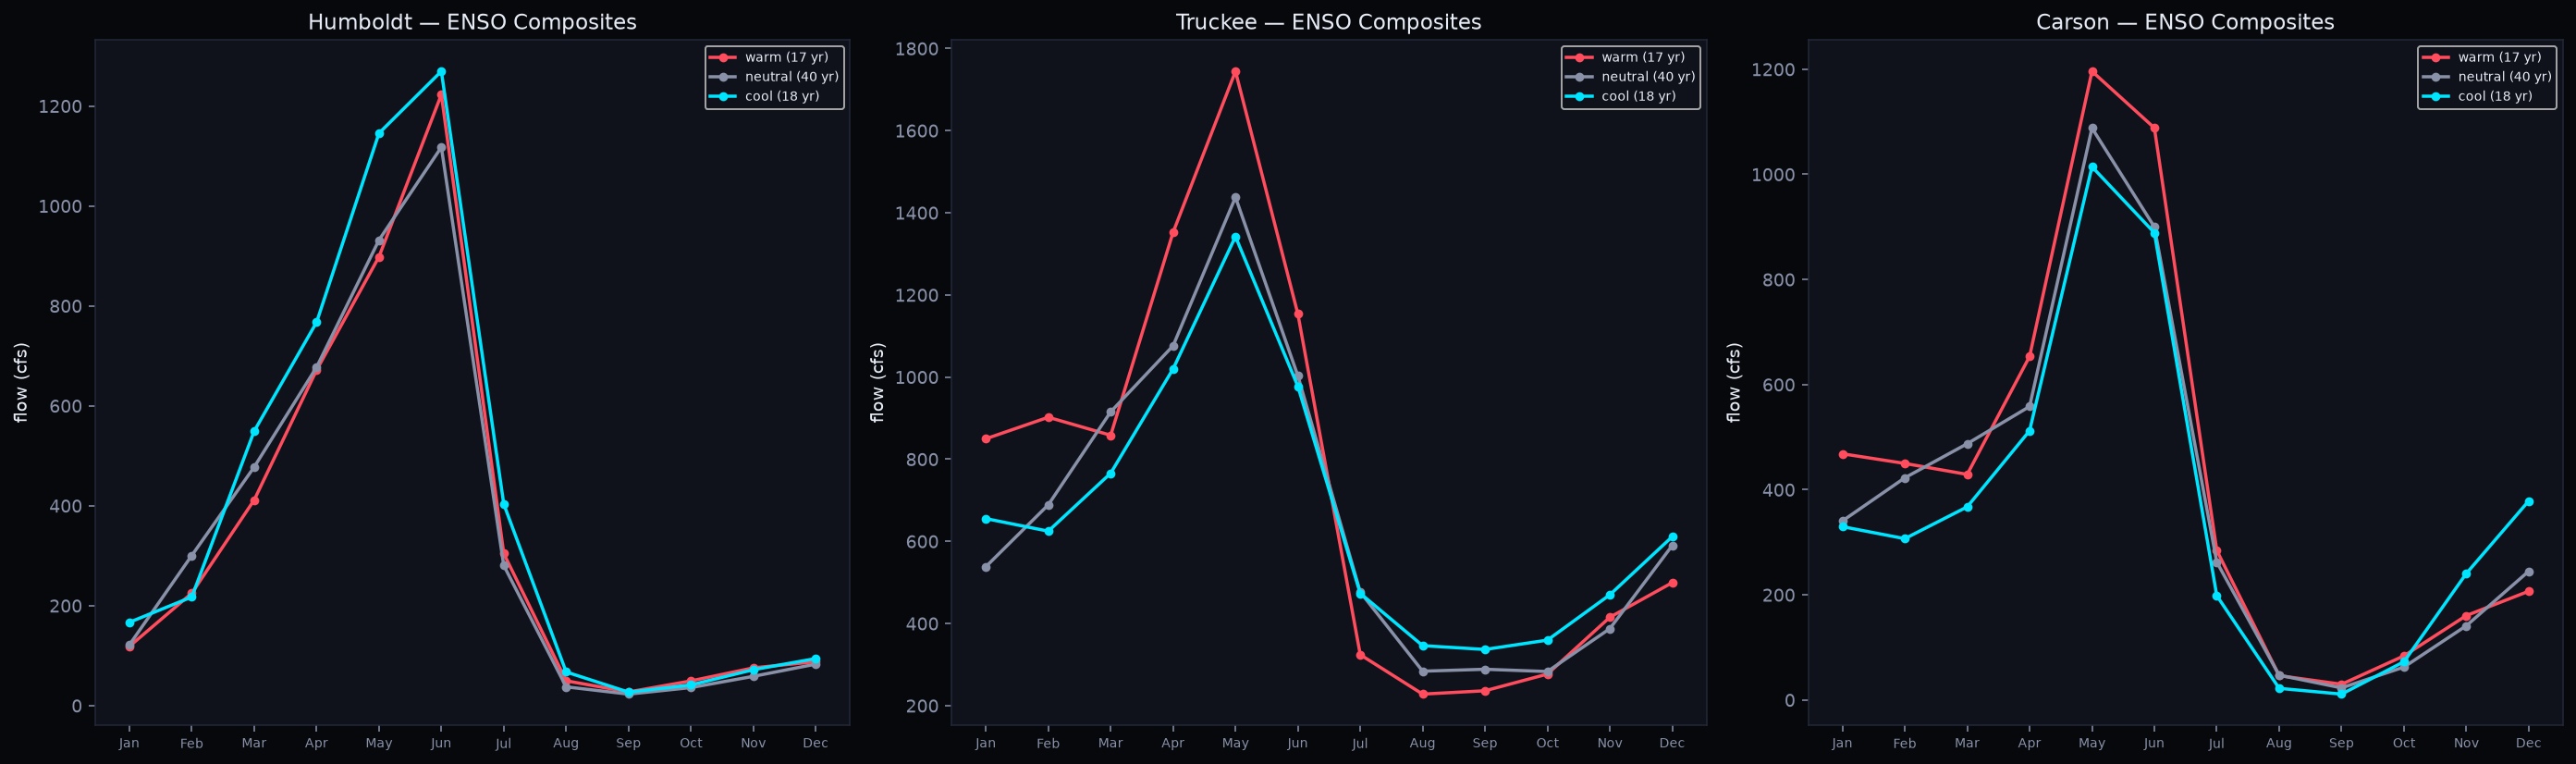

In [10]:
def plot_composites(obs, index_by_year, title, ax, *, index_name="ONI"):
    clean = complete_years(obs)
    pc = fm.composite_hydrographs(clean, index_by_year)
    m = range(1, 13)
    for label, vec, color in (("warm", pc.warm, RED),
                               ("neutral", pc.neutral, MUTED),
                               ("cool", pc.cool, COOL_BLUE)):
        if vec is not None:
            n_yrs = len(getattr(pc, label + "_years"))
            ax.plot(m, vec, "-o", ms=4, lw=1.8, color=color,
                    label=f"{label} ({n_yrs} yr)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_composites(hum_c, oni, "Humboldt — ENSO Composites", axes[0])
plot_composites(tru_c, oni, "Truckee — ENSO Composites", axes[1])
plot_composites(car_c, oni, "Carson — ENSO Composites", axes[2])
plt.tight_layout()
save(fig, "enso_composites")
plt.show()

---
## 10. Flow-Duration Curves by Decade

How has the entire flow distribution shifted over time? In arid
Nevada, the low end of the FDC is critical — shifts there reveal
changing drought severity and baseflow support.

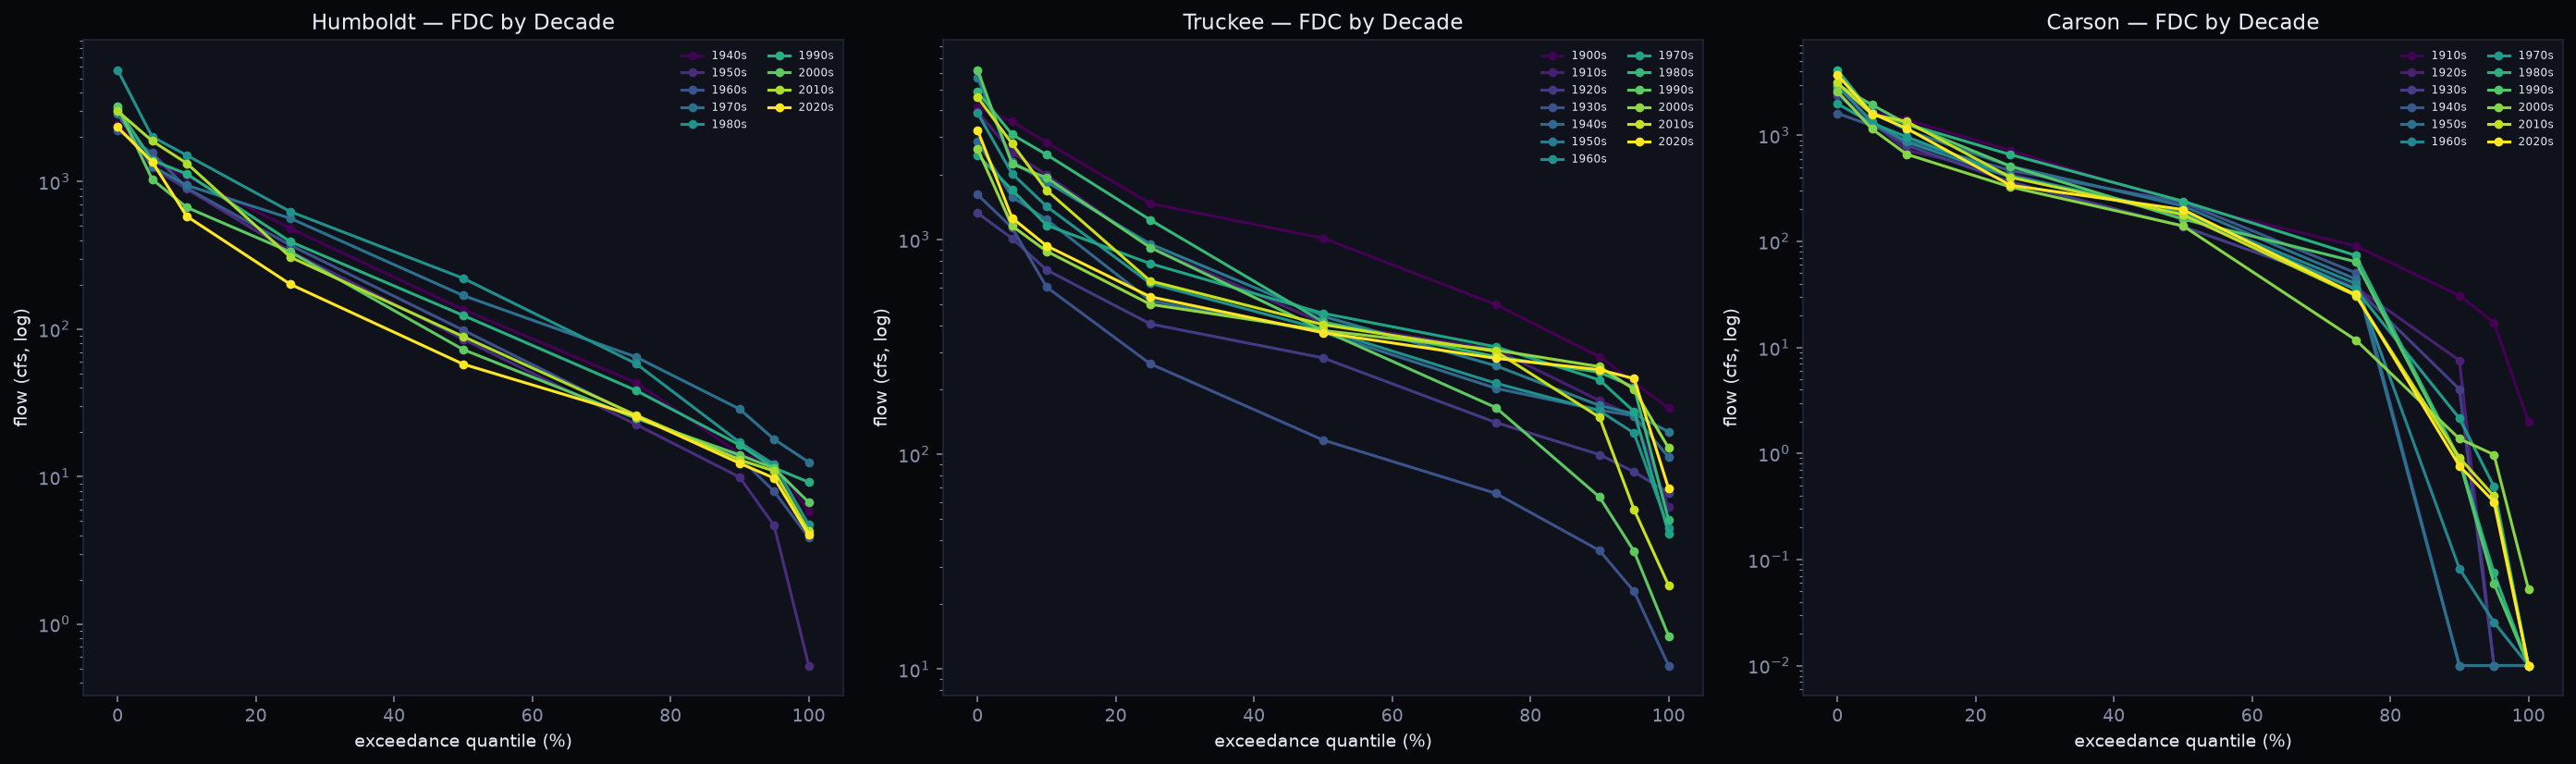

In [11]:
def plot_decade_fdc(obs, title, ax):
    clean = complete_years(obs)
    quantiles = [0, 5, 10, 25, 50, 75, 90, 95, 100]
    decades = fm.decade_flow_duration(clean, quantiles)
    cmap = plt.get_cmap("viridis")
    span = max(1, len(decades) - 1)
    for i, d in enumerate(decades):
        ax.plot(d.quantiles, np.clip(d.flows, 1e-2, None), "-o", ms=4,
                color=cmap(i / span), lw=1.6, label=f"{d.decade}s")
    ax.set_yscale("log")
    ax.set_xlabel("exceedance quantile (%)")
    ax.set_ylabel("flow (cfs, log)")
    ax.set_title(title)
    ax.legend(fontsize=6, ncol=2, frameon=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_decade_fdc(hum_c, "Humboldt — FDC by Decade", axes[0])
plot_decade_fdc(tru_c, "Truckee — FDC by Decade", axes[1])
plot_decade_fdc(car_c, "Carson — FDC by Decade", axes[2])
plt.tight_layout()
save(fig, "decade_fdc")
plt.show()

---
## 11. Analog Years — Most Similar Historical Shapes

Which historical years had the most similar seasonal shape to the most
recent year? In water-scarce Nevada, identifying analog years helps
water managers anticipate irrigation allocations and reservoir operations.

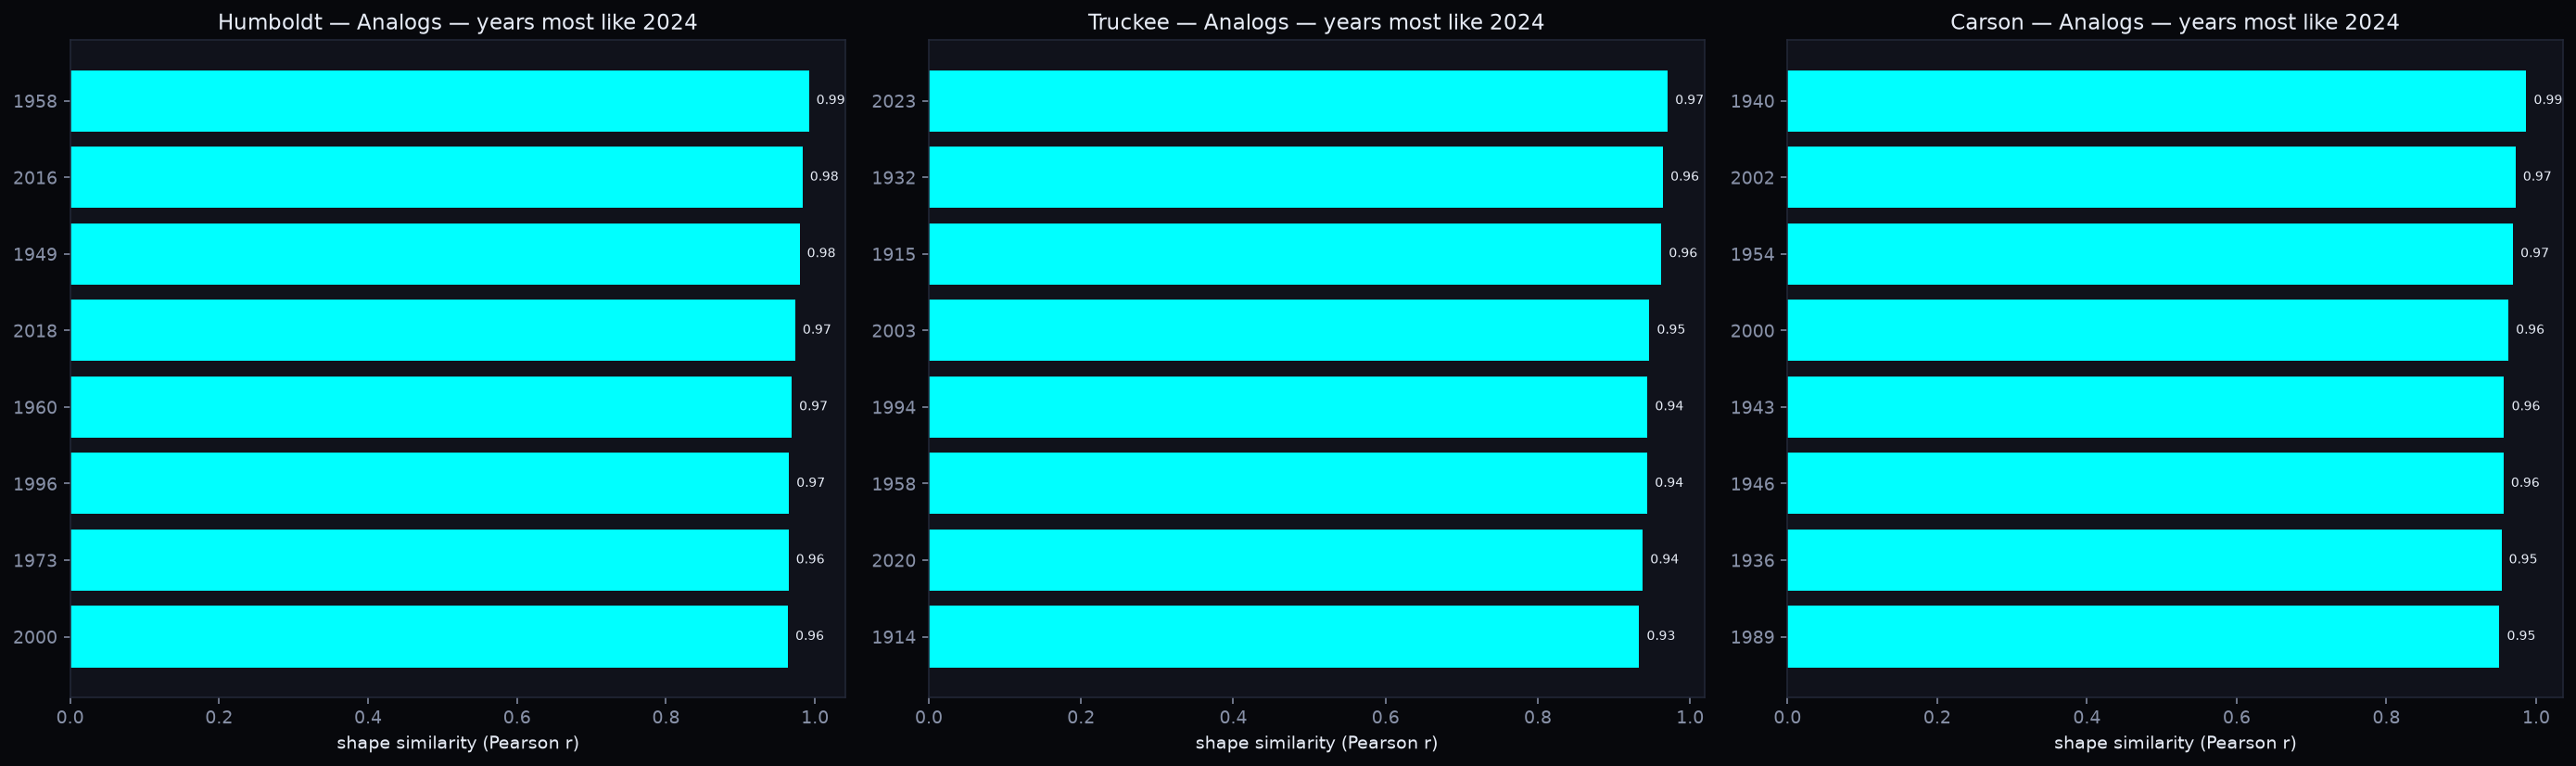

In [12]:
def plot_analog_years(obs, title, ax, *, n=8):
    clean = complete_years(obs)
    target = max(clean.keys())
    analogs = fm.analog_years(clean, target, n=n)
    labels = [str(a.year) for a in analogs]
    sims = [a.similarity for a in analogs]
    colors = [CYAN if s > 0.9 else COOL_BLUE if s > 0.7 else MUTED for s in sims]
    bars = ax.barh(labels, sims, color=colors)
    ax.invert_yaxis()
    ax.set_xlabel("shape similarity (Pearson r)")
    ax.set_title(f"{title} — years most like {target}")
    for bar, s in zip(bars, sims):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{s:.2f}", va="center", fontsize=7, color=LIGHT)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_analog_years(hum_c, "Humboldt — Analogs", axes[0])
plot_analog_years(tru_c, "Truckee — Analogs", axes[1])
plot_analog_years(car_c, "Carson — Analogs", axes[2])
plt.tight_layout()
save(fig, "analog_years")
plt.show()

---
## 12. Drought / Flood Record Book

Top-5 driest summers and wettest years. Nevada's droughts are legendary —
the 2012–2016 drought nearly emptied Walker Lake and stressed Pyramid
Lake's Lahontan cutthroat trout. The big flood years (1983, 1997, 2017)
coincide with strong El Niño events.

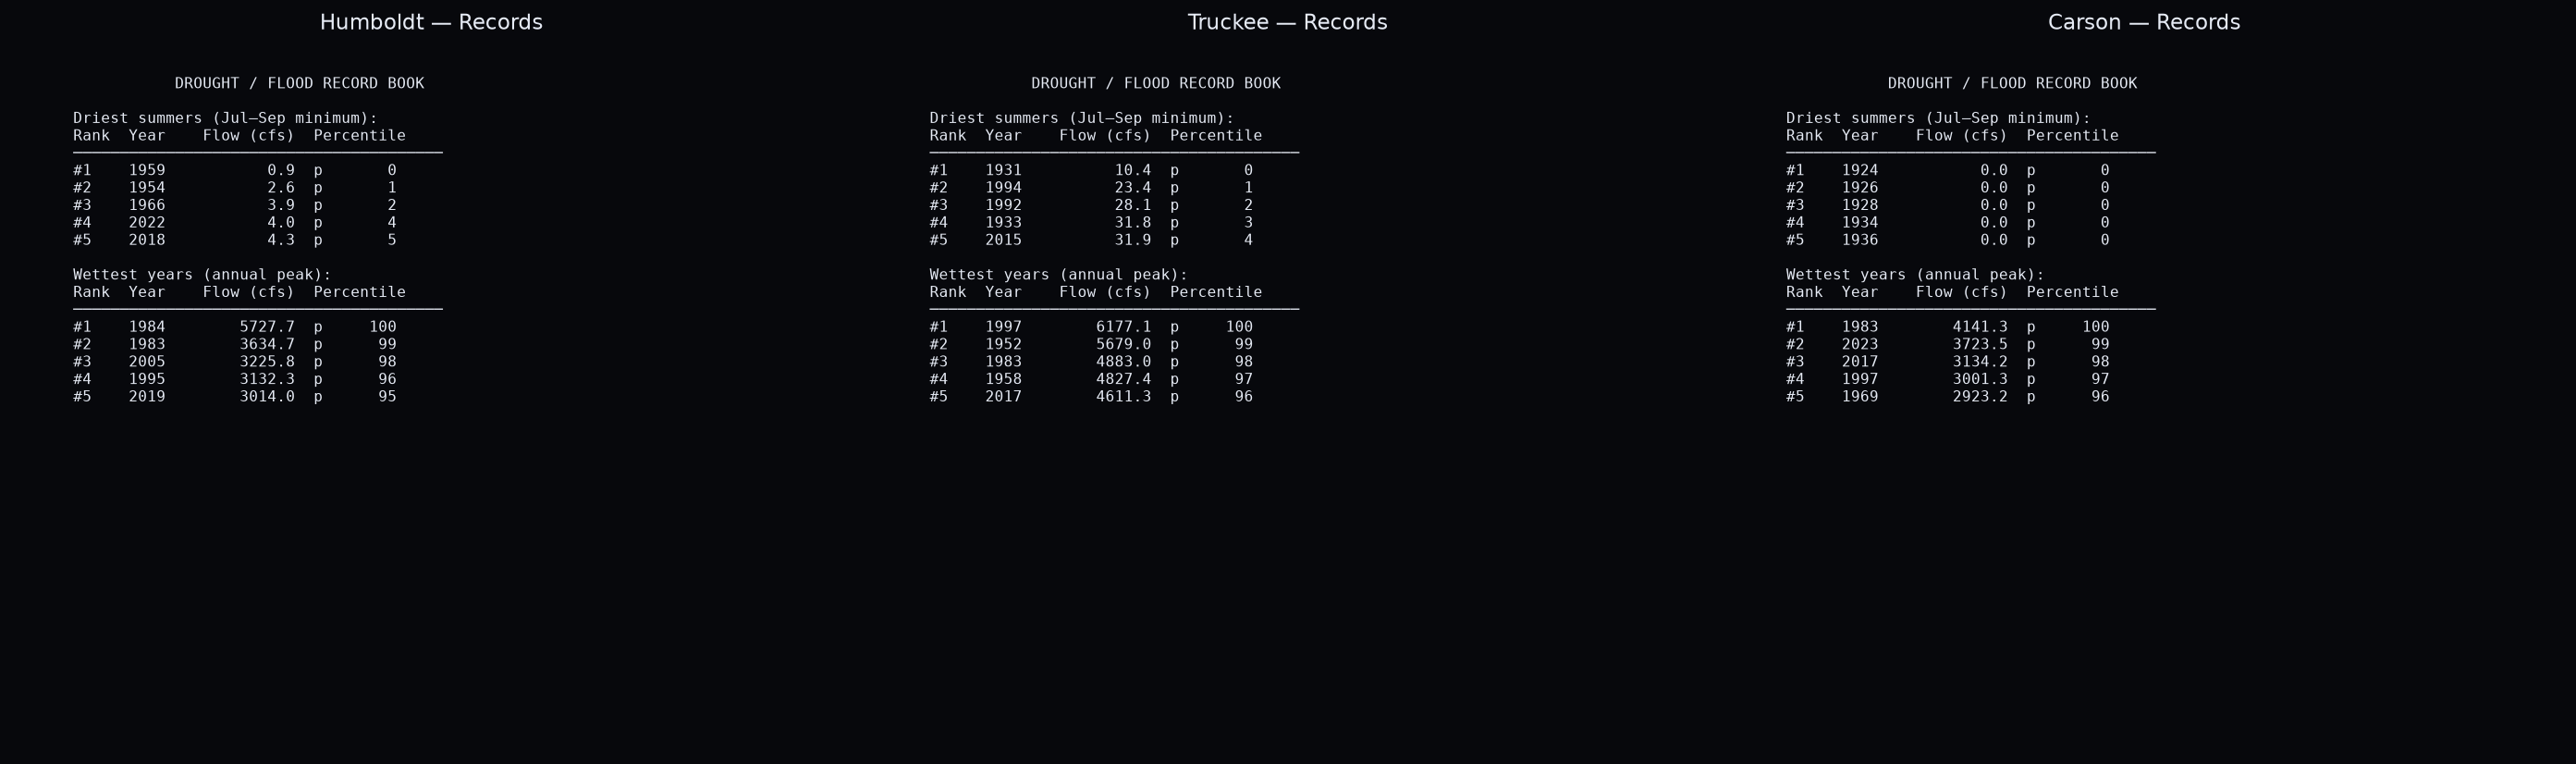

In [13]:
def plot_record_book(obs, title, ax):
    clean = complete_years(obs)
    rb = fm.record_book(clean, n=5)
    lines = [f"  {'DROUGHT / FLOOD RECORD BOOK':^50}", ""]
    lines.append("  Driest summers (Jul–Sep minimum):")
    lines.append(f"  {'Rank':>4}  {'Year':>4}  {'Flow (cfs)':>12}  {'Percentile':>10}")
    lines.append("  " + "─" * 40)
    for e in rb.driest_summers:
        lines.append(f"  #{e.rank:<3}  {e.year}  {e.value:>12.1f}  p{e.percentile*100:>8.0f}")
    lines += ["", "  Wettest years (annual peak):"]
    lines.append(f"  {'Rank':>4}  {'Year':>4}  {'Flow (cfs)':>12}  {'Percentile':>10}")
    lines.append("  " + "─" * 40)
    for e in rb.wettest_years:
        lines.append(f"  #{e.rank:<3}  {e.year}  {e.value:>12.1f}  p{e.percentile*100:>8.0f}")
    ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
            fontfamily="monospace", fontsize=8, va="top", color=LIGHT)
    ax.set_axis_off()
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_record_book(hum_c, "Humboldt — Records", axes[0])
plot_record_book(tru_c, "Truckee — Records", axes[1])
plot_record_book(car_c, "Carson — Records", axes[2])
plt.tight_layout()
save(fig, "record_book")
plt.show()

---
## 13. Seasonal Ratio — Wet/Dry Season Balance

Ratio of wet-season (Nov–Apr) to dry-season (May–Oct) mean flow.
Nevada's extreme seasonality should produce high ratios — virtually
all water arrives as spring snowmelt in a 2-3 month window.

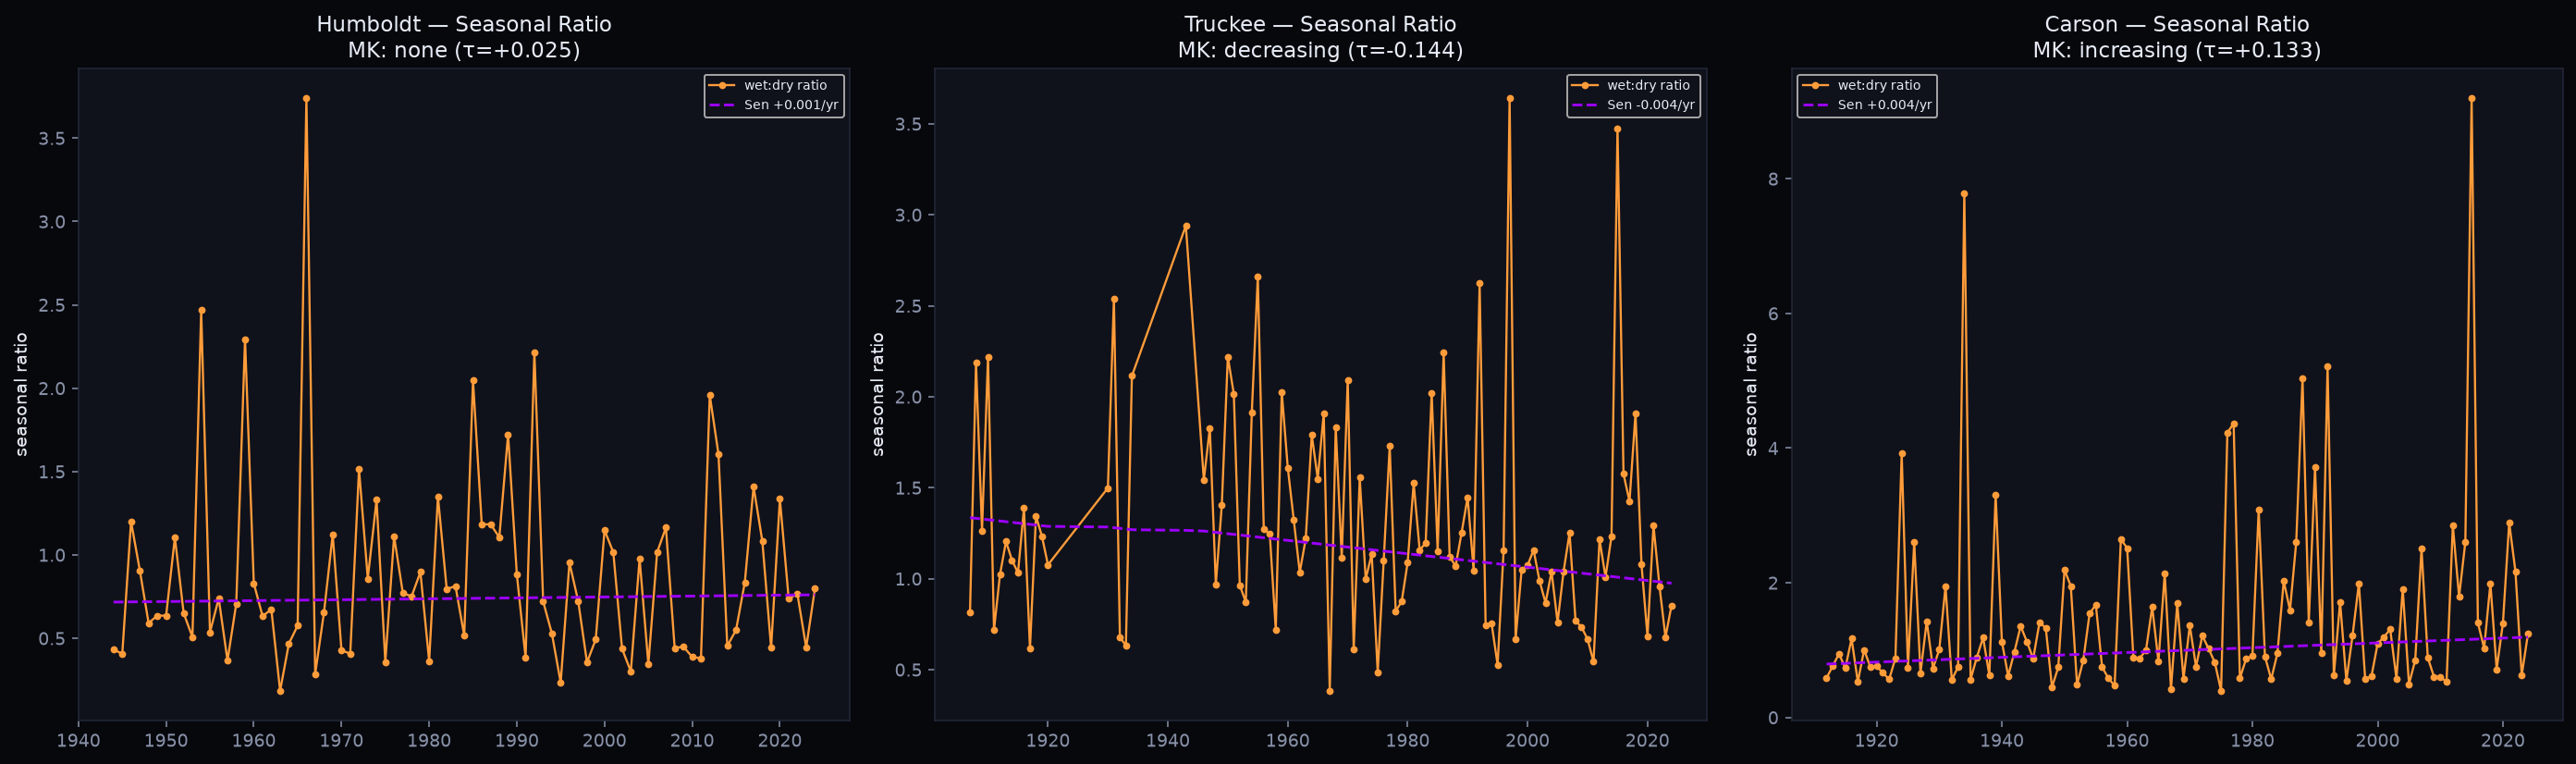

In [14]:
def plot_seasonal_ratio(obs, title, ax):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    ratios = [fm.seasonal_ratio(clean[y]) for y in years]
    mk = fm.mann_kendall(ratios)
    slope = fm.sens_slope(ratios)
    x = np.arange(len(years))
    fit = np.median(ratios) + slope * (x - np.median(x))
    ax.plot(years, ratios, "o-", color=AMBER, lw=1.2, ms=3, label="wet:dry ratio")
    ax.plot(years, fit, "--", color=VIOLET, lw=1.5,
            label=f"Sen {slope:+.3f}/yr")
    ax.set_ylabel("seasonal ratio")
    ax.set_title(f"{title}\nMK: {mk.trend} (τ={mk.tau:+.3f})")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_seasonal_ratio(hum_c, "Humboldt — Seasonal Ratio", axes[0])
plot_seasonal_ratio(tru_c, "Truckee — Seasonal Ratio", axes[1])
plot_seasonal_ratio(car_c, "Carson — Seasonal Ratio", axes[2])
plt.tight_layout()
save(fig, "seasonal_ratio")
plt.show()

---
## 14. Flashiness Index — Richards-Baker Variability

How spiky is each year's hydrograph? Nevada's rivers are naturally
flashy — a concentrated snowmelt pulse followed by months of near-zero
flow. The Humboldt, with no lake buffering, should be the flashiest.

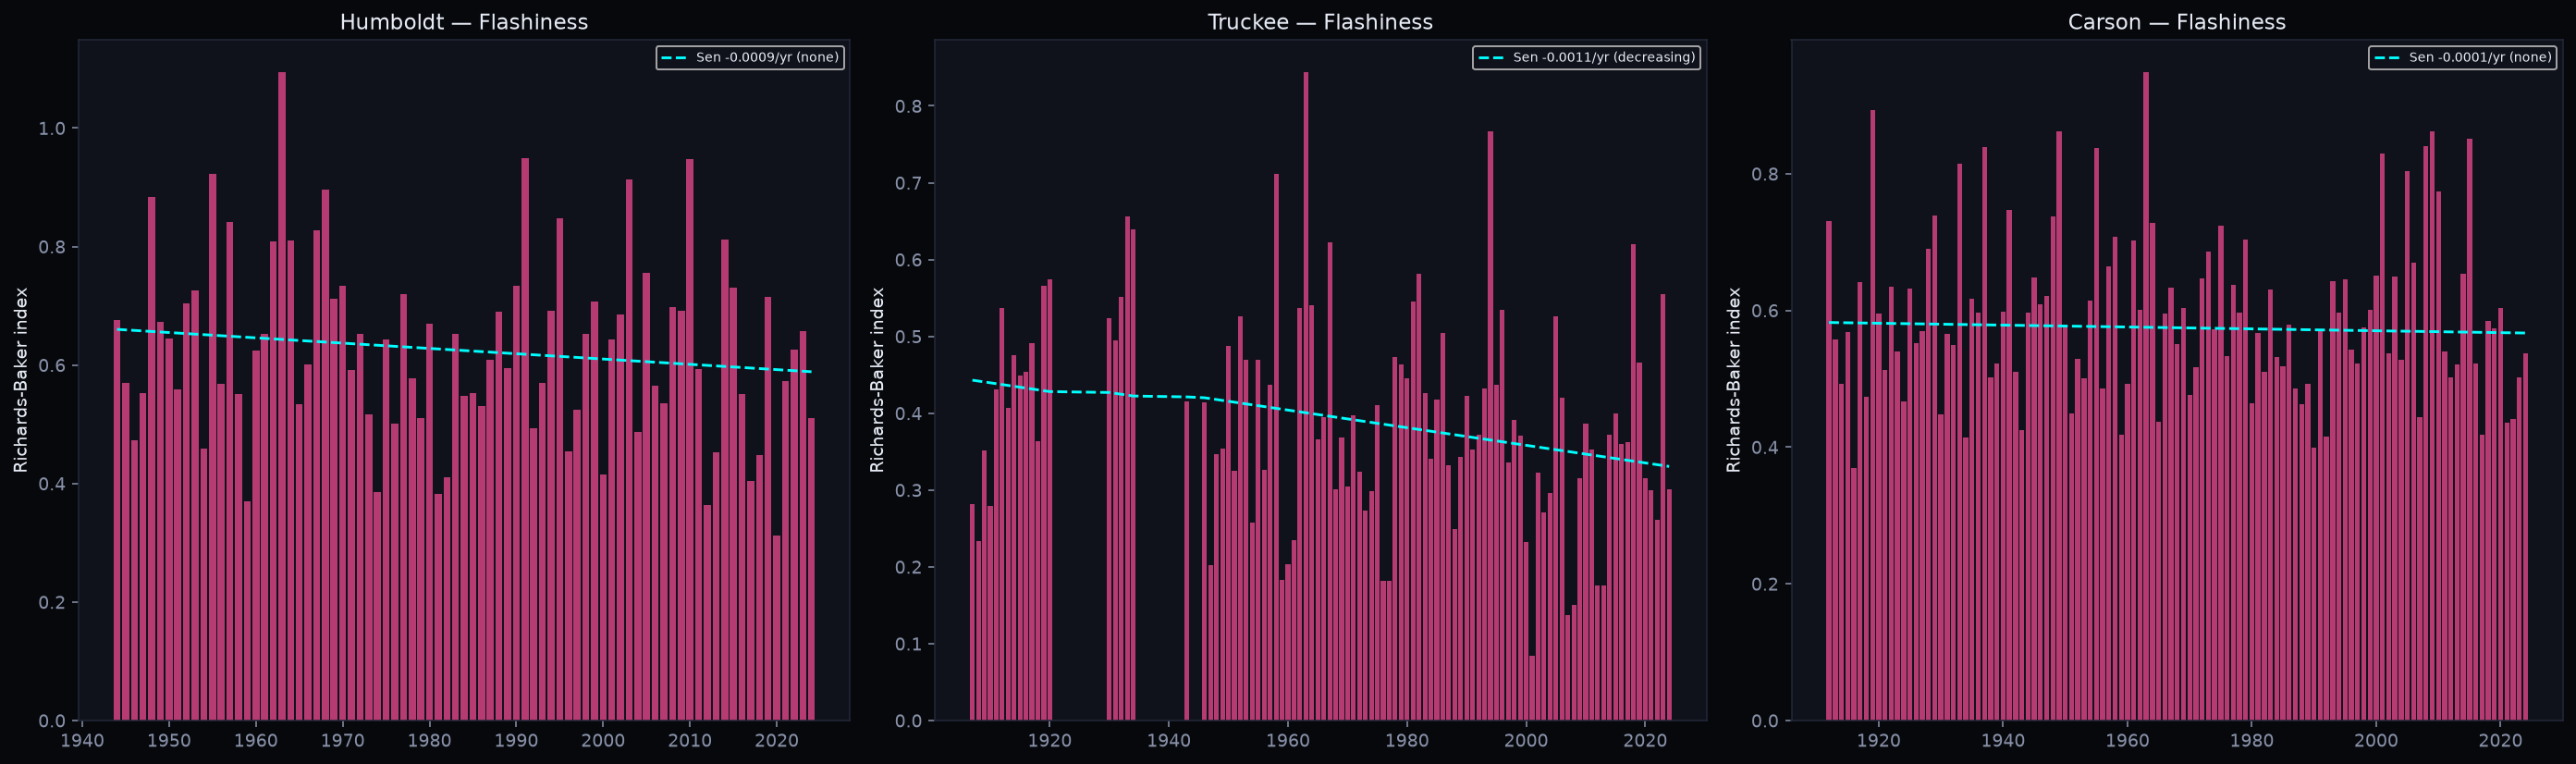

In [15]:
def plot_flashiness(obs, title, ax):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    flash = [fm.flashiness(clean[y]) for y in years]
    mk = fm.mann_kendall(flash)
    slope = fm.sens_slope(flash)
    x = np.arange(len(years))
    fit = np.median(flash) + slope * (x - np.median(x))
    ax.bar(years, flash, color=MAGENTA, alpha=0.7, width=0.8)
    ax.plot(years, fit, "--", color=CYAN, lw=1.5,
            label=f"Sen {slope:+.4f}/yr ({mk.trend})")
    ax.set_ylabel("Richards-Baker index")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_flashiness(hum_c, "Humboldt — Flashiness", axes[0])
plot_flashiness(tru_c, "Truckee — Flashiness", axes[1])
plot_flashiness(car_c, "Carson — Flashiness", axes[2])
plt.tight_layout()
save(fig, "flashiness")
plt.show()

---
## 15. Rolling 30-Year Climate Normals

Sliding 30-year mean of annual flow — the slow multi-decadal signal.
The Truckee's long record reveals the full PDO cycle and the impact
of 20th-century water diversions.

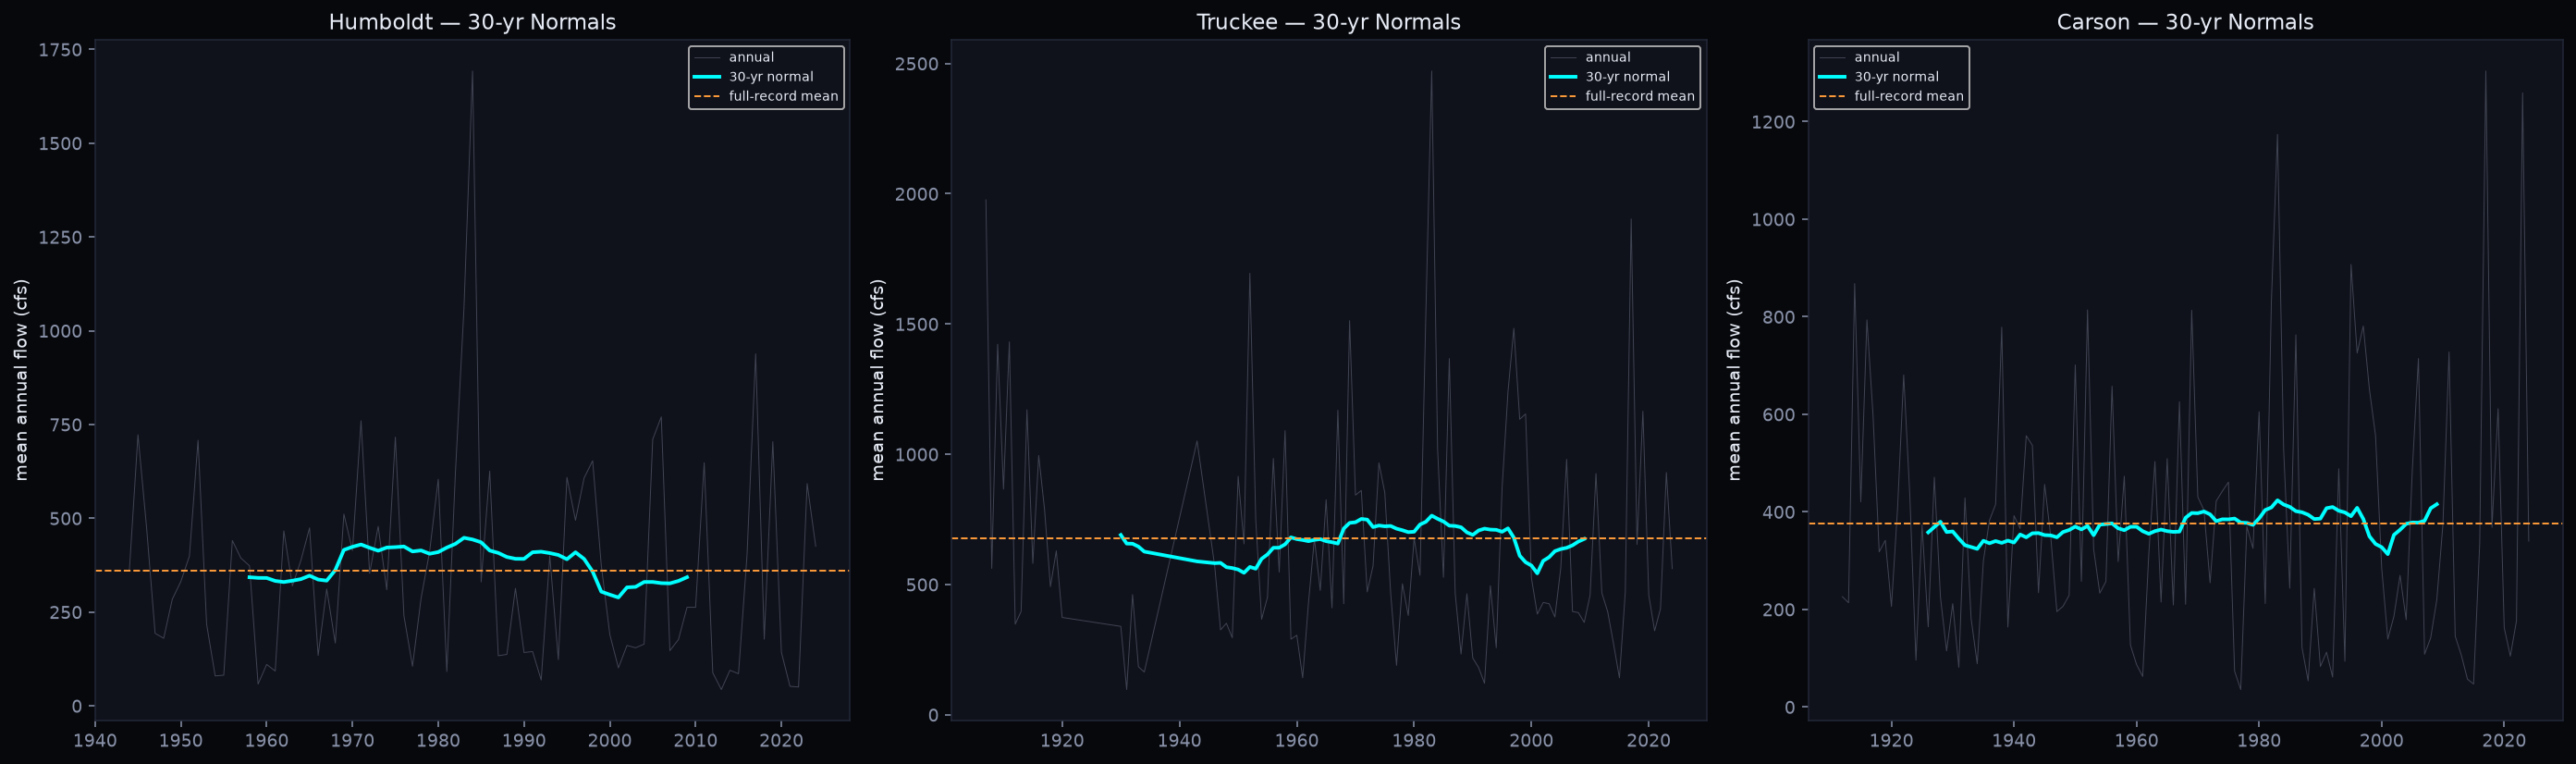

In [16]:
def plot_rolling_normals(obs, title, ax):
    years = sorted(obs.keys())
    annual = [float(np.nanmean(obs[y])) for y in years]
    if len(years) < 30:
        ax.text(0.5, 0.5, "< 30 years", ha="center", va="center",
                transform=ax.transAxes, color=MUTED)
        return
    rm = np.convolve(annual, np.ones(30)/30, mode="valid")
    ax.plot(years, annual, color=MUTED, lw=0.5, alpha=0.4, label="annual")
    ax.plot(years[14:-15], rm, color=CYAN, lw=2, label="30-yr normal")
    ax.axhline(np.mean(annual), color=AMBER, ls="--", lw=1, label="full-record mean")
    ax.set_ylabel("mean annual flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_rolling_normals(hum_c, "Humboldt — 30-yr Normals", axes[0])
plot_rolling_normals(tru_c, "Truckee — 30-yr Normals", axes[1])
plot_rolling_normals(car_c, "Carson — 30-yr Normals", axes[2])
plt.tight_layout()
save(fig, "rolling_normals")
plt.show()

---
## 16. Monthly Flow Histograms

Distribution of flow values for each calendar month across all years.
May and June should show wide, right-skewed distributions (big
snowmelt years); August–October should be tightly clustered near zero.

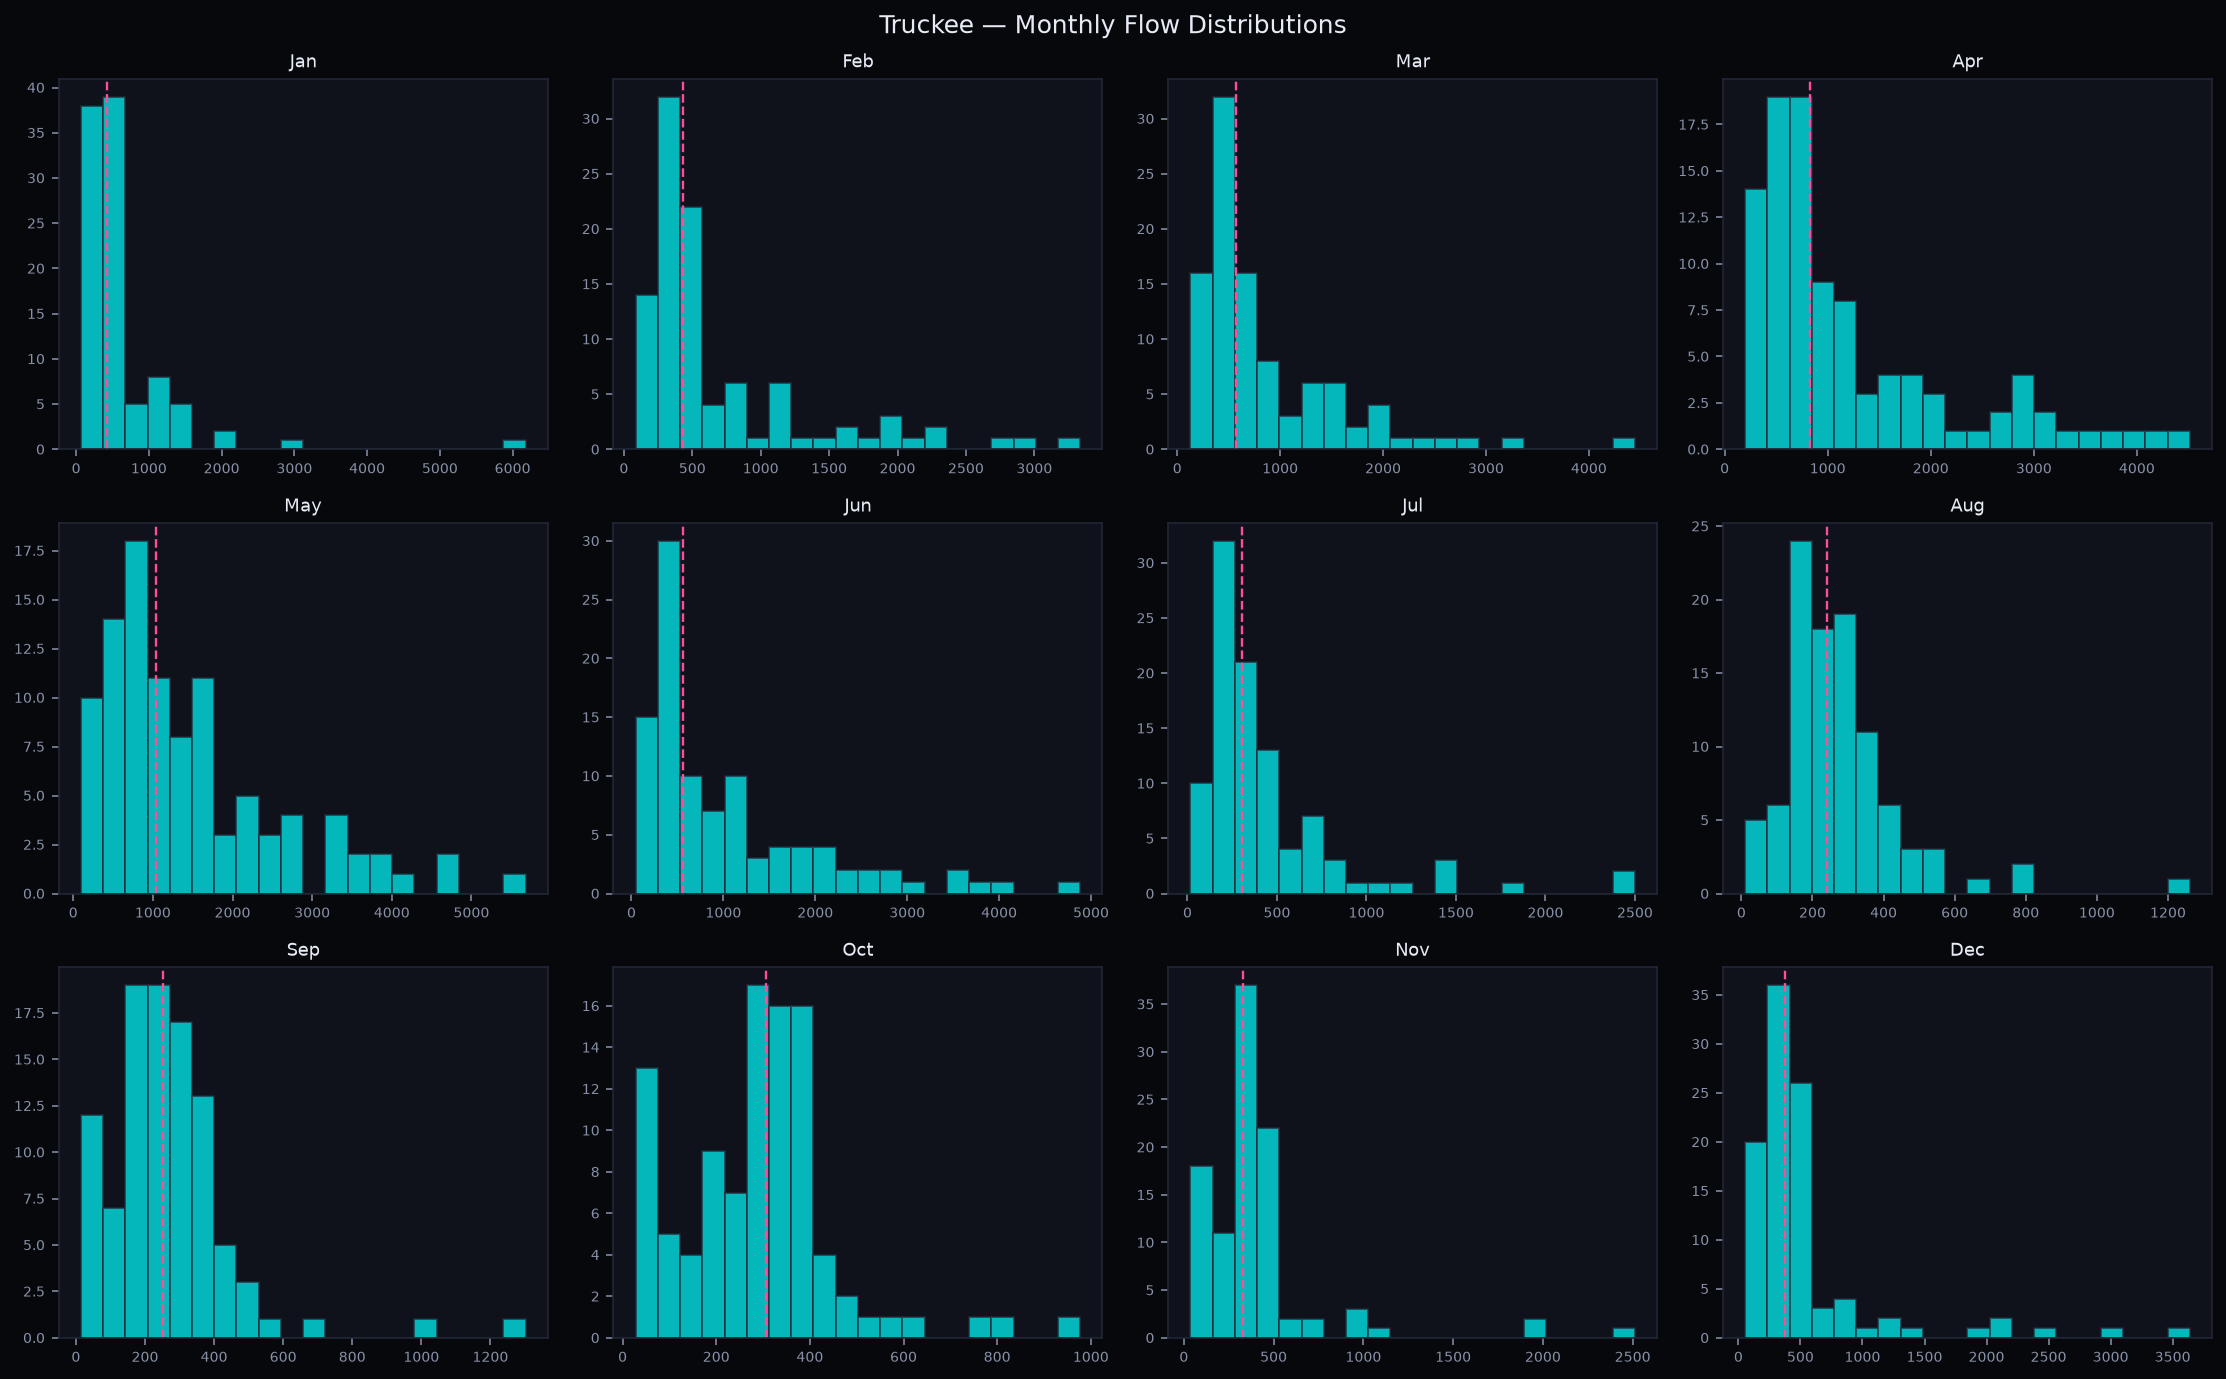

In [17]:
def plot_monthly_histograms(obs, title):
    years = sorted(obs.keys())
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    for m in range(12):
        ax = axes[m // 4, m % 4]
        vals = [obs[y][m] for y in years if np.isfinite(obs[y][m])]
        ax.hist(vals, bins=20, color=CYAN, alpha=0.7, edgecolor="#232838")
        ax.axvline(np.median(vals), color=MAGENTA, ls="--", lw=1.2)
        ax.set_title(MONTH_ABBR[m], fontsize=9)
        ax.tick_params(labelsize=7)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    return fig

fig = plot_monthly_histograms(tru_c, "Truckee — Monthly Flow Distributions")
save(fig, "monthly_hist")
plt.show()

---
## 17. Annual Flow Histogram + Kernel Density

The distribution of annual-mean flows. Nevada's arid climate produces
a strongly right-skewed distribution — most years are dry, with
occasional wet El Niño years pulling the tail.

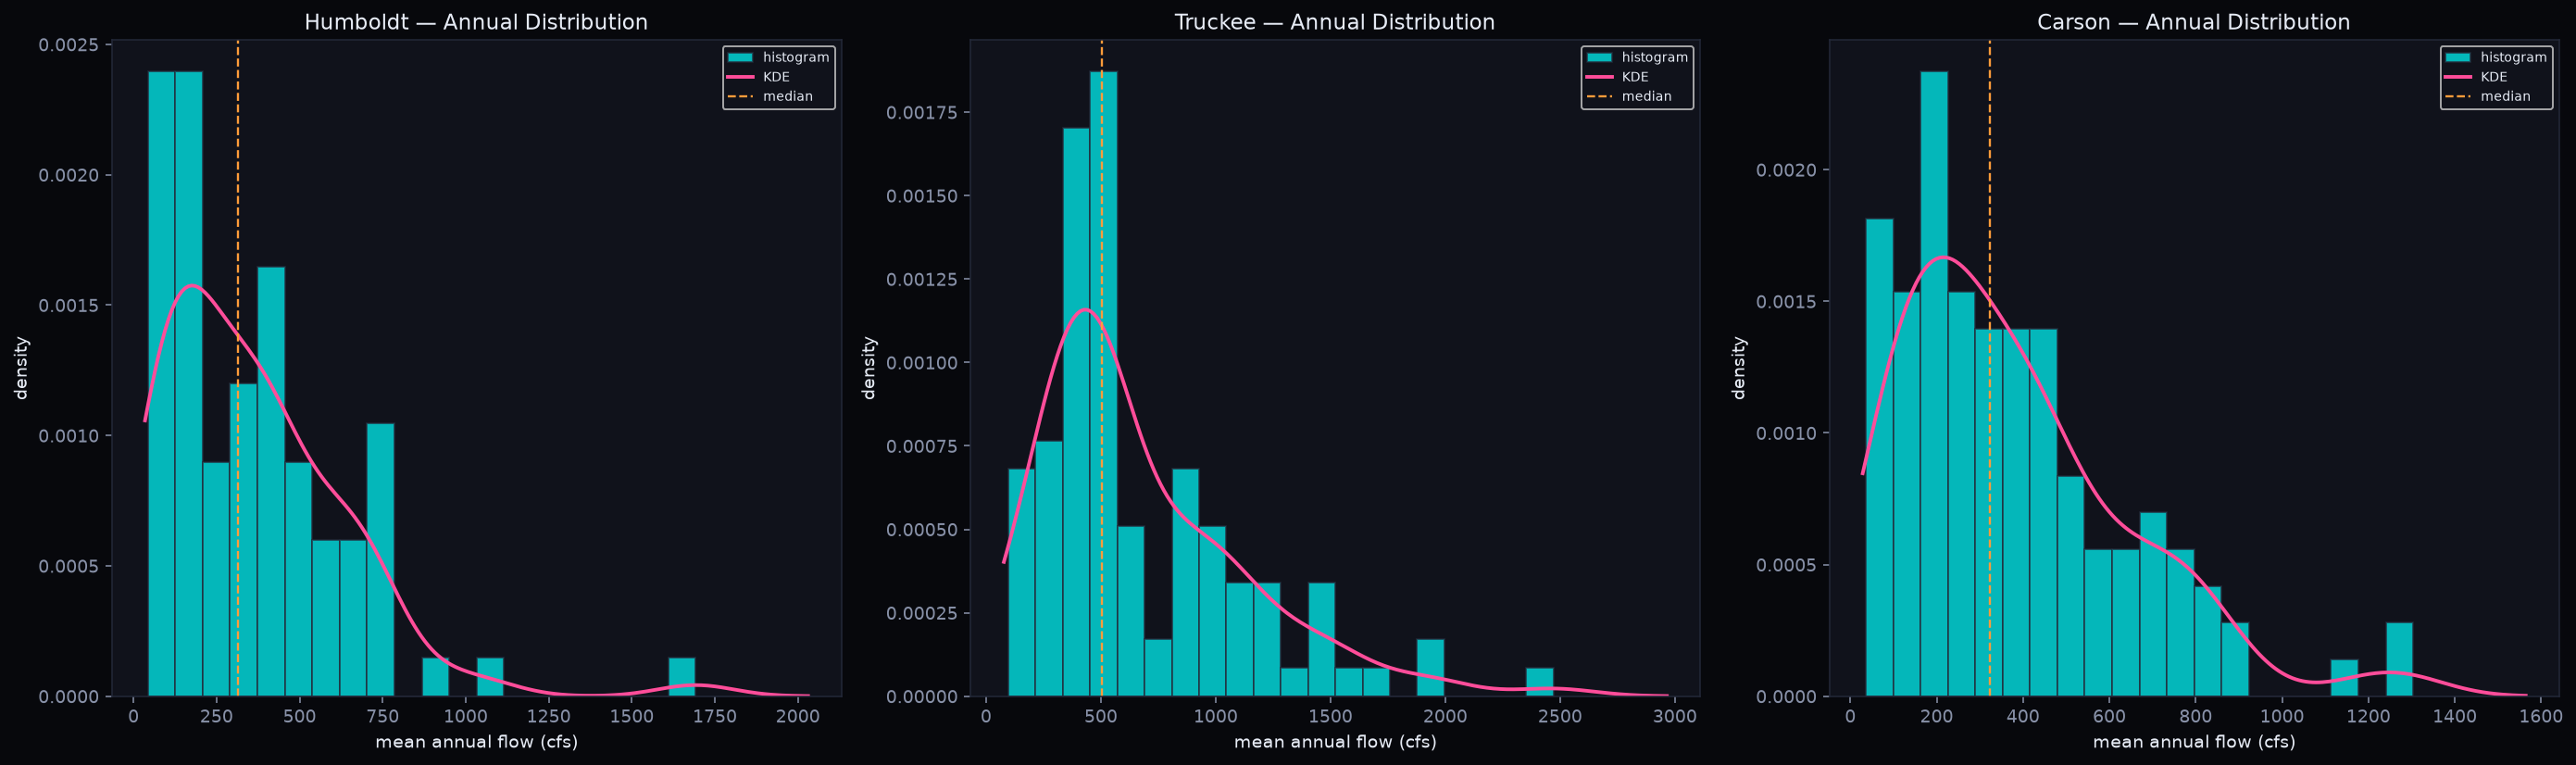

In [18]:
def plot_annual_histogram(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    ax.hist(annual, bins=20, color=CYAN, alpha=0.7, edgecolor="#232838",
            density=True, label="histogram")
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(annual)
    xr = np.linspace(annual.min() * 0.8, annual.max() * 1.2, 200)
    ax.plot(xr, kde(xr), color=MAGENTA, lw=2, label="KDE")
    ax.axvline(np.median(annual), color=AMBER, ls="--", lw=1.2, label="median")
    ax.set_xlabel("mean annual flow (cfs)")
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_annual_histogram(hum_c, "Humboldt — Annual Distribution", axes[0])
plot_annual_histogram(tru_c, "Truckee — Annual Distribution", axes[1])
plot_annual_histogram(car_c, "Carson — Annual Distribution", axes[2])
plt.tight_layout()
save(fig, "annual_hist")
plt.show()

---
## 18. Heatmap — Month × Year Flow Matrix

Color-coded matrix of flow by month and year. The May–June column
should glow hottest; look for the drought bands (2012–2016) and
the El Niño spikes (1983, 1997, 2017).

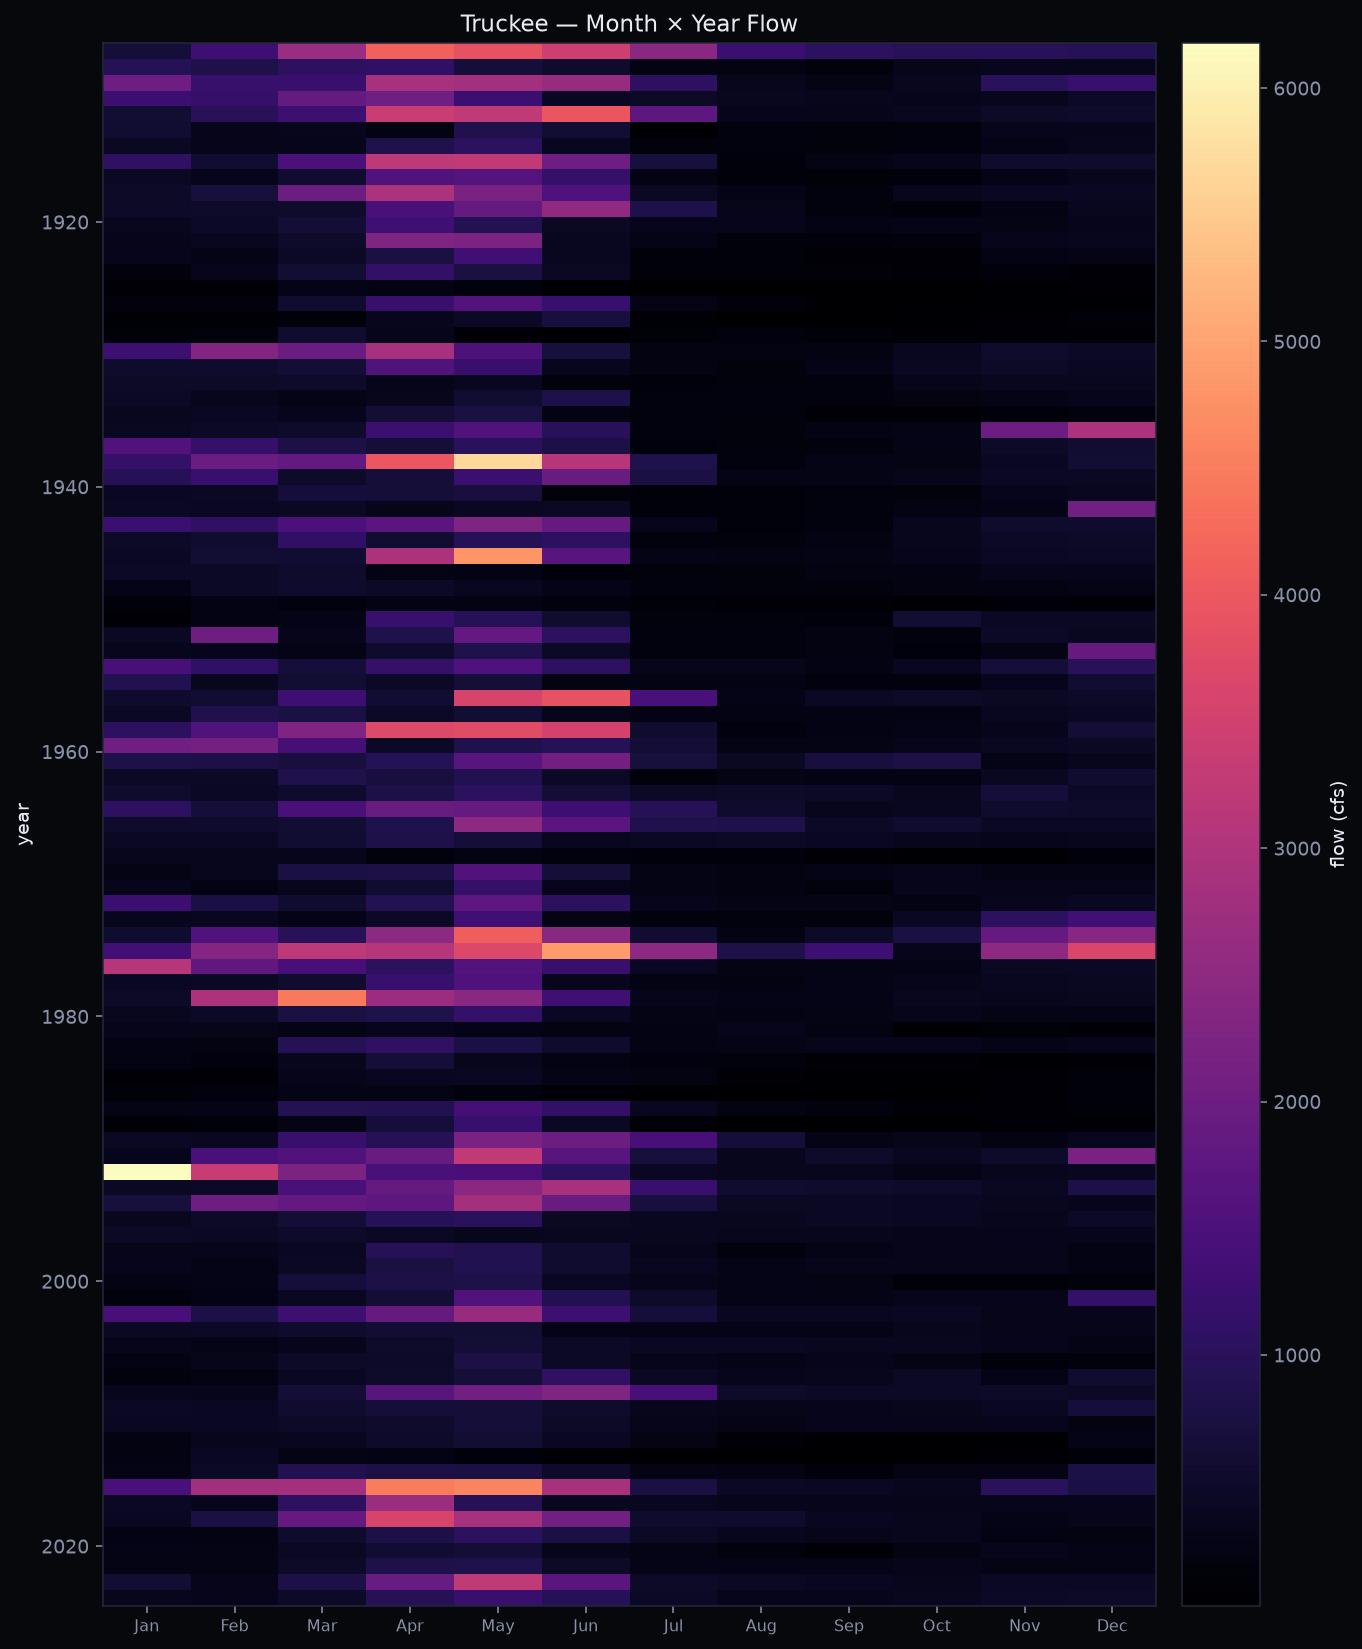

In [19]:
def plot_heatmap(obs, title):
    years = sorted(obs.keys())
    mat = np.array([obs[y] for y in years])
    fig, ax = plt.subplots(figsize=(10, max(6, len(years) * 0.12)))
    im = ax.imshow(mat, aspect="auto", cmap="magma",
                   extent=[0.5, 12.5, years[-1] + 0.5, years[0] - 0.5])
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=8)
    ax.set_ylabel("year")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="flow (cfs)", pad=0.02)
    plt.tight_layout()
    return fig

fig = plot_heatmap(tru_c, "Truckee — Month × Year Flow")
save(fig, "heatmap")
plt.show()

---
## 19. Box Plots — Monthly Flow Distributions

Box-and-whisker for each calendar month — compact multi-river comparison.

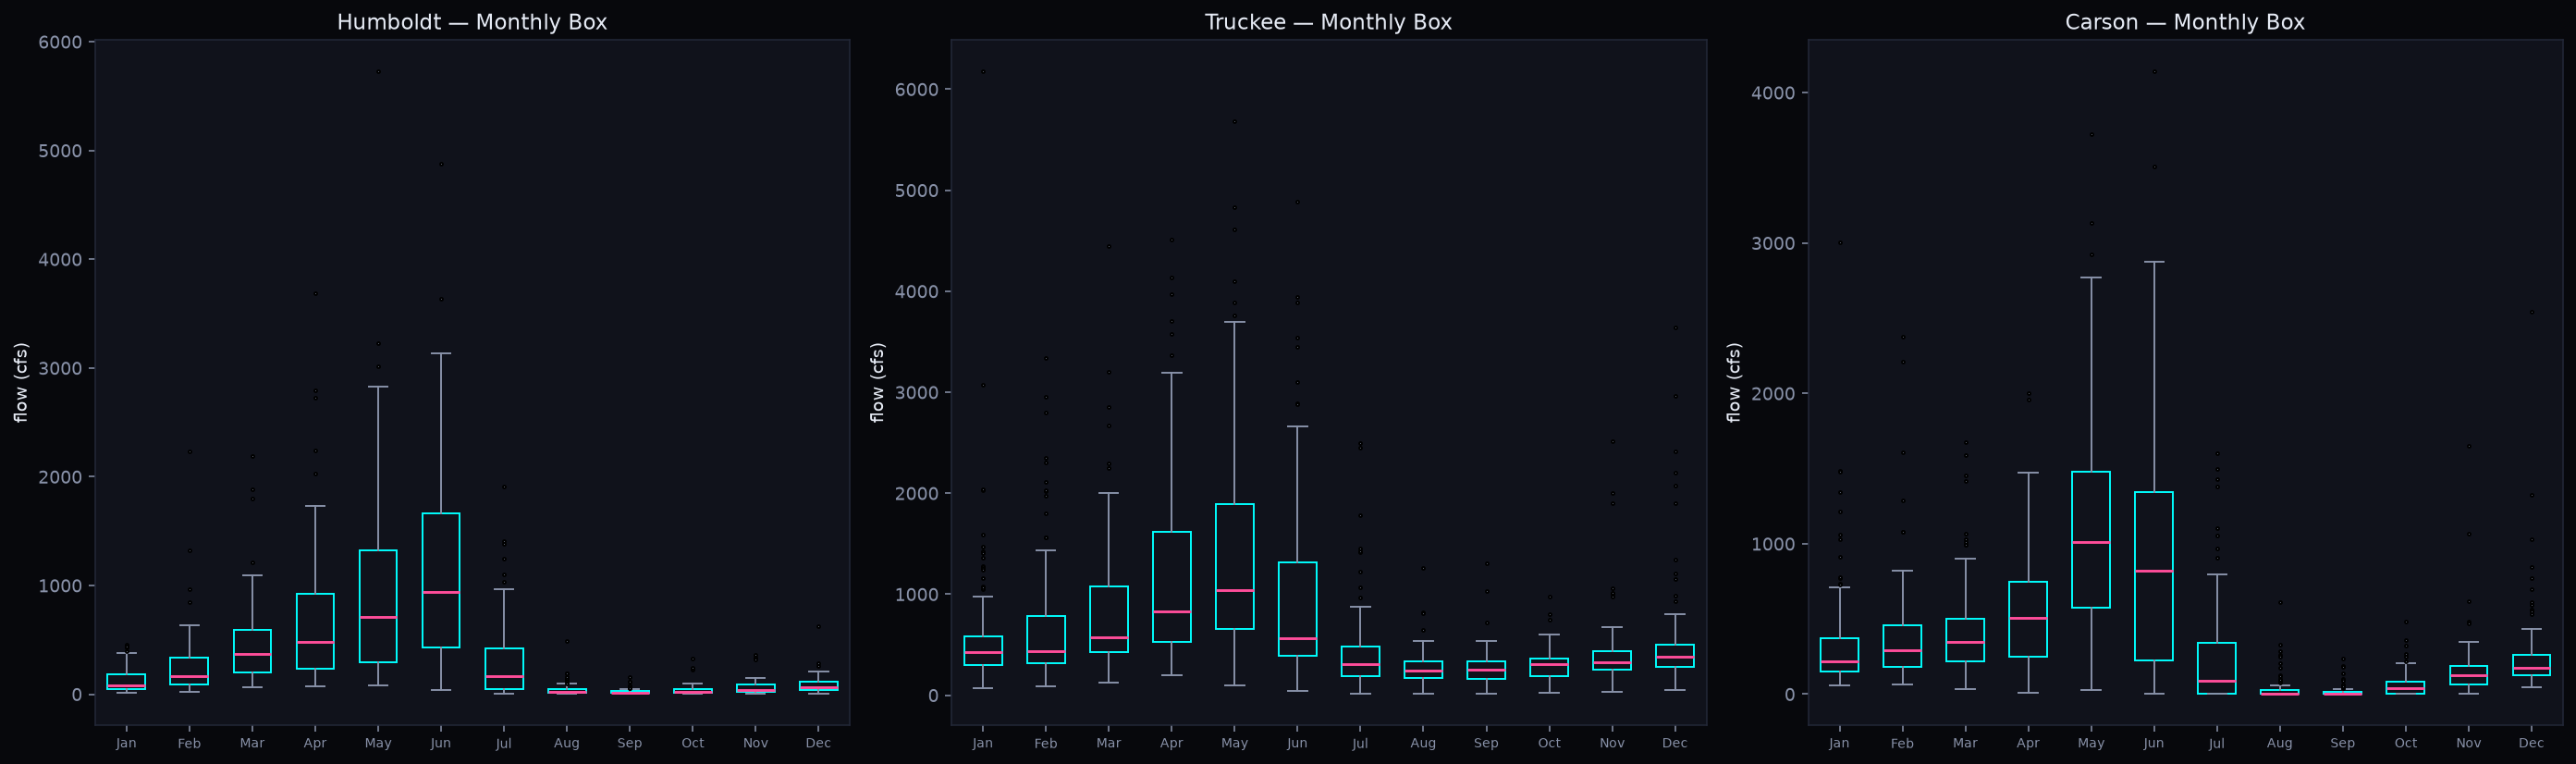

In [20]:
def plot_monthly_box(obs, title, ax):
    years = sorted(obs.keys())
    data = [[obs[y][m] for y in years if np.isfinite(obs[y][m])] for m in range(12)]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                    boxprops=dict(facecolor="#10121b", edgecolor=CYAN),
                    whiskerprops=dict(color=MUTED),
                    capprops=dict(color=MUTED),
                    medianprops=dict(color=MAGENTA, lw=1.5),
                    flierprops=dict(marker=".", markerfacecolor=MUTED, markersize=3))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_monthly_box(hum_c, "Humboldt — Monthly Box", axes[0])
plot_monthly_box(tru_c, "Truckee — Monthly Box", axes[1])
plot_monthly_box(car_c, "Carson — Monthly Box", axes[2])
plt.tight_layout()
save(fig, "monthly_box")
plt.show()

---
## 20. PDO Teleconnection — Peak Flow vs. PDO

The Pacific Decadal Oscillation modulates Sierra snowpack on
multi-decadal timescales. Positive PDO tends to enhance El Niño
effects in the Great Basin; negative PDO amplifies La Niña drying.

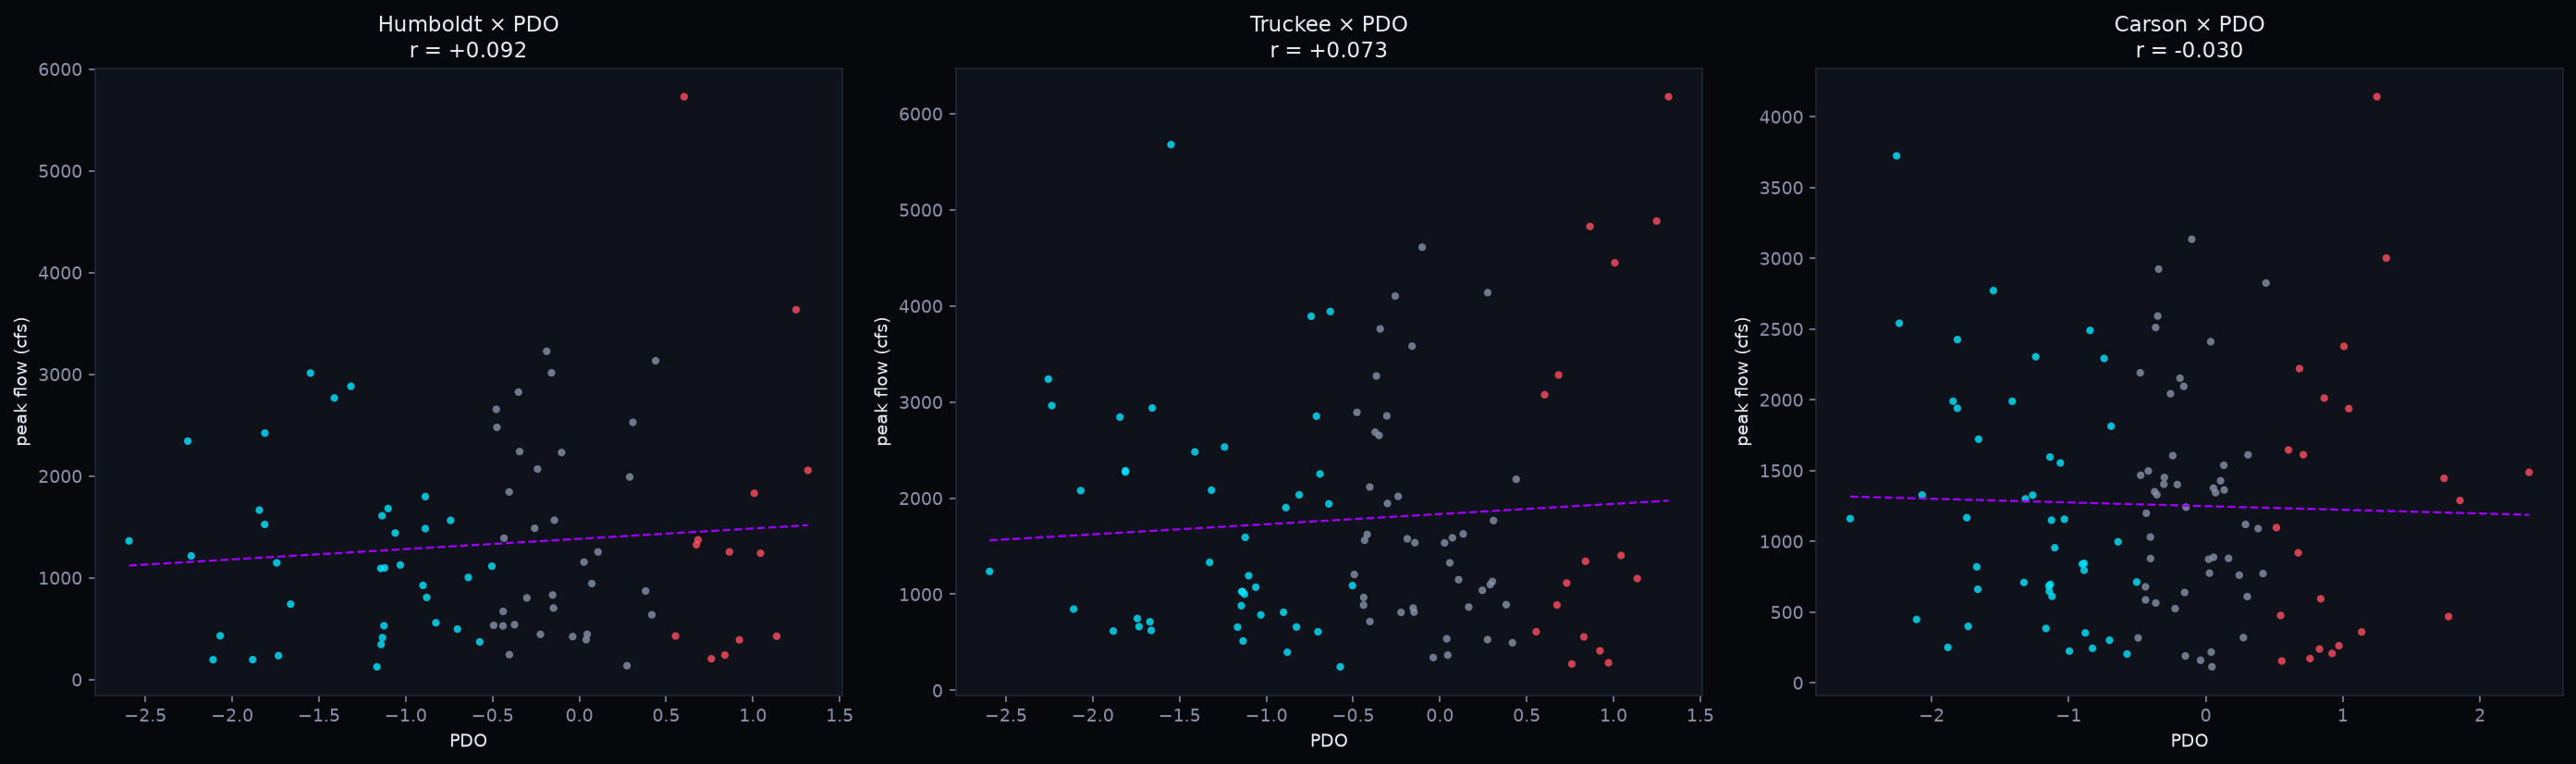

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_enso(hum_c, pdo, "Humboldt × PDO", axes[0], index_name="PDO")
plot_enso(tru_c, pdo, "Truckee × PDO", axes[1], index_name="PDO")
plot_enso(car_c, pdo, "Carson × PDO", axes[2], index_name="PDO")
plt.tight_layout()
save(fig, "pdo")
plt.show()

---
## 21. Climate Index Time Series — ONI + PDO

The raw climate indices overlaid for visual inspection. Nevada's
biggest flow years should line up with warm (El Niño) ONI phases.

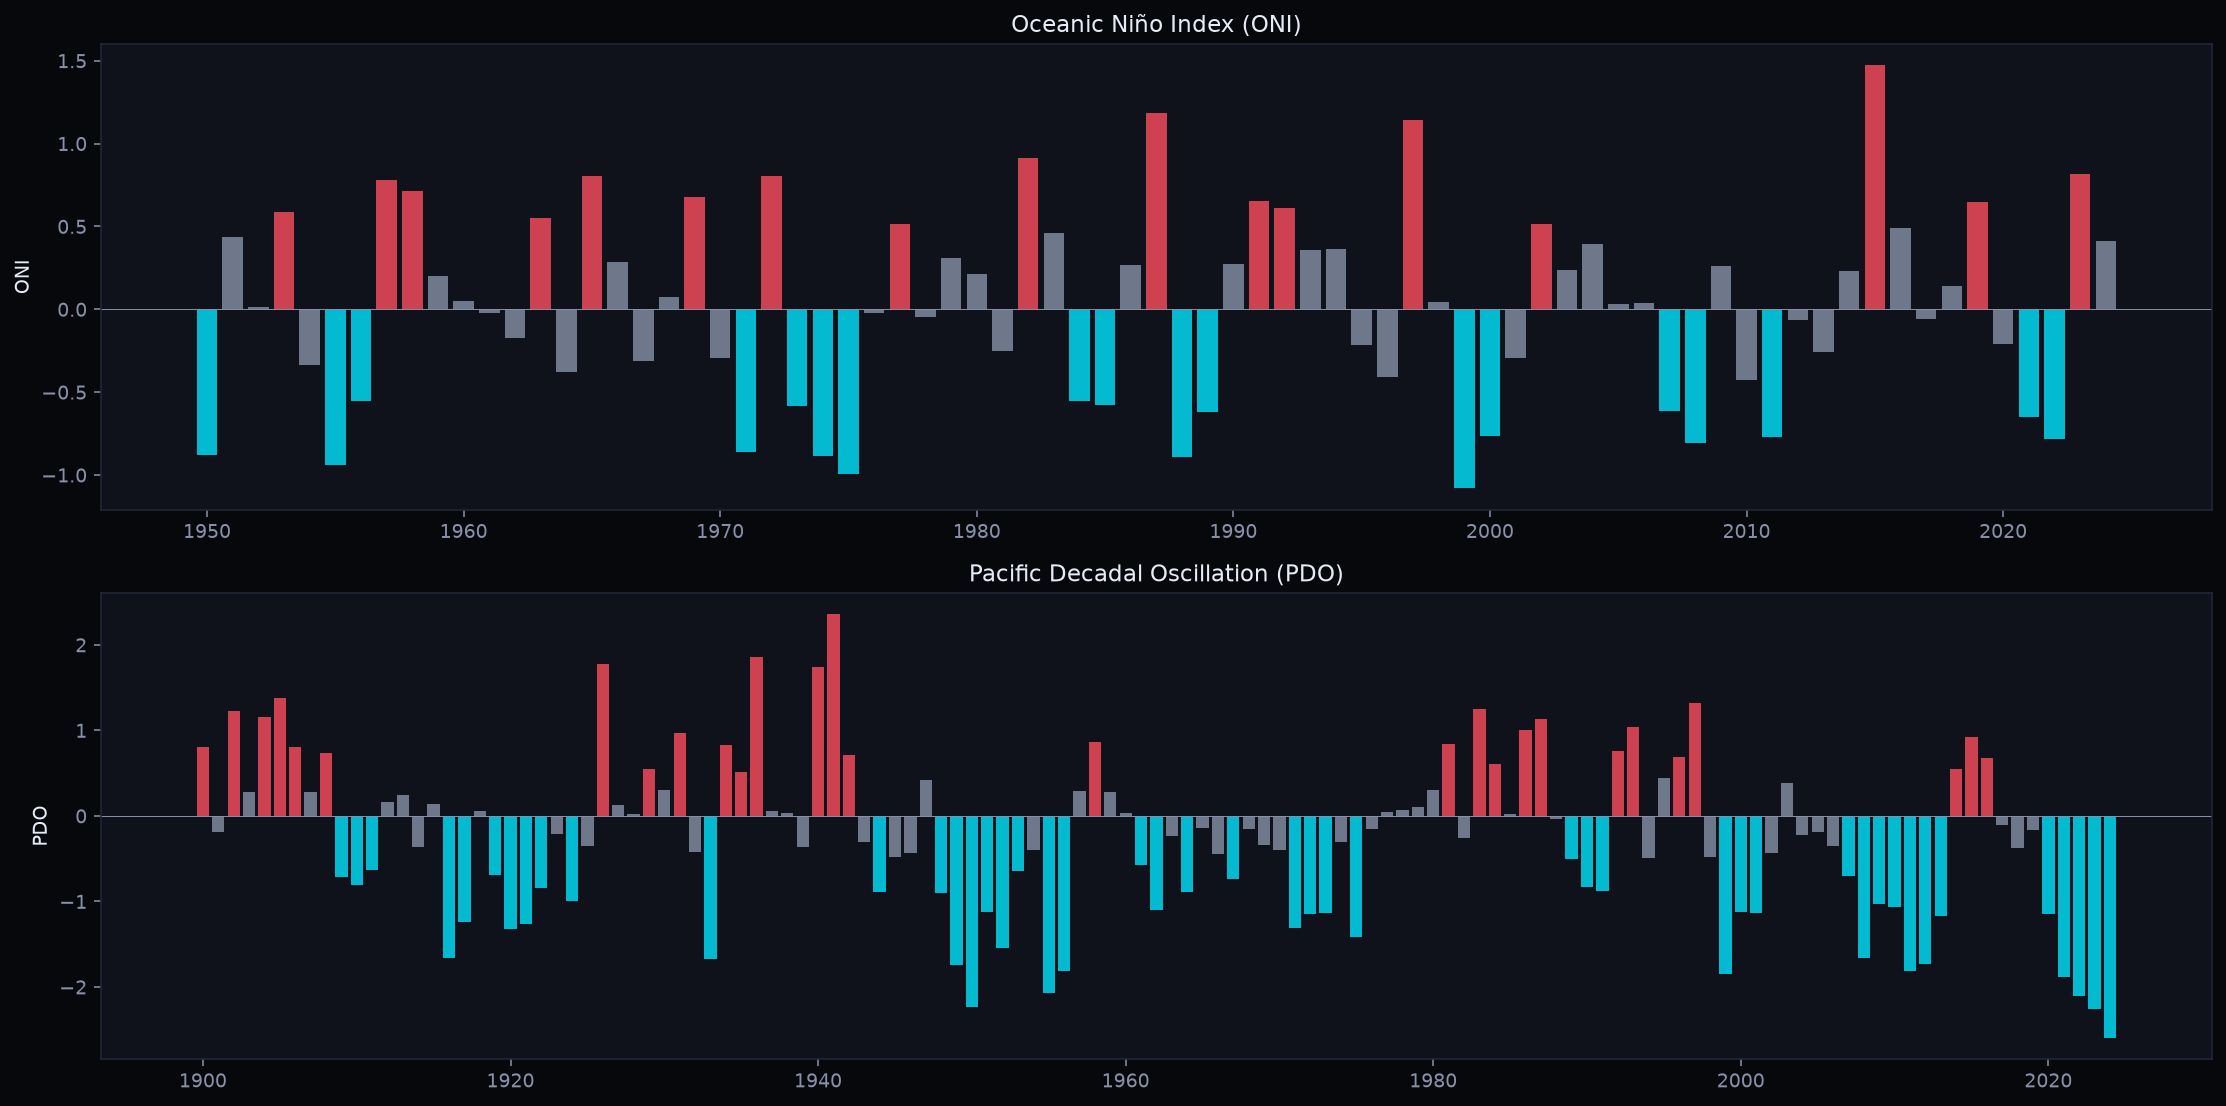

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))
years_oni = sorted(oni.keys())
vals_oni = [oni[y] for y in years_oni]
colors_oni = [RED if v > 0.5 else COOL_BLUE if v < -0.5 else MUTED for v in vals_oni]
ax1.bar(years_oni, vals_oni, color=colors_oni, width=0.8, alpha=0.8)
ax1.axhline(0, color=MUTED, lw=0.5)
ax1.set_ylabel("ONI")
ax1.set_title("Oceanic Niño Index (ONI)")

years_pdo = sorted(pdo.keys())
vals_pdo = [pdo[y] for y in years_pdo]
colors_pdo = [RED if v > 0.5 else COOL_BLUE if v < -0.5 else MUTED for v in vals_pdo]
ax2.bar(years_pdo, vals_pdo, color=colors_pdo, width=0.8, alpha=0.8)
ax2.axhline(0, color=MUTED, lw=0.5)
ax2.set_ylabel("PDO")
ax2.set_title("Pacific Decadal Oscillation (PDO)")
plt.tight_layout()
save(fig, "climate_indices")
plt.show()

---
## 22. Decadal Shift Analysis

Mean hydrograph shape per decade overlaid. Is the snowmelt peak
shrinking or shifting earlier decade by decade? This is the key
climate-change diagnostic for Nevada's water supply.

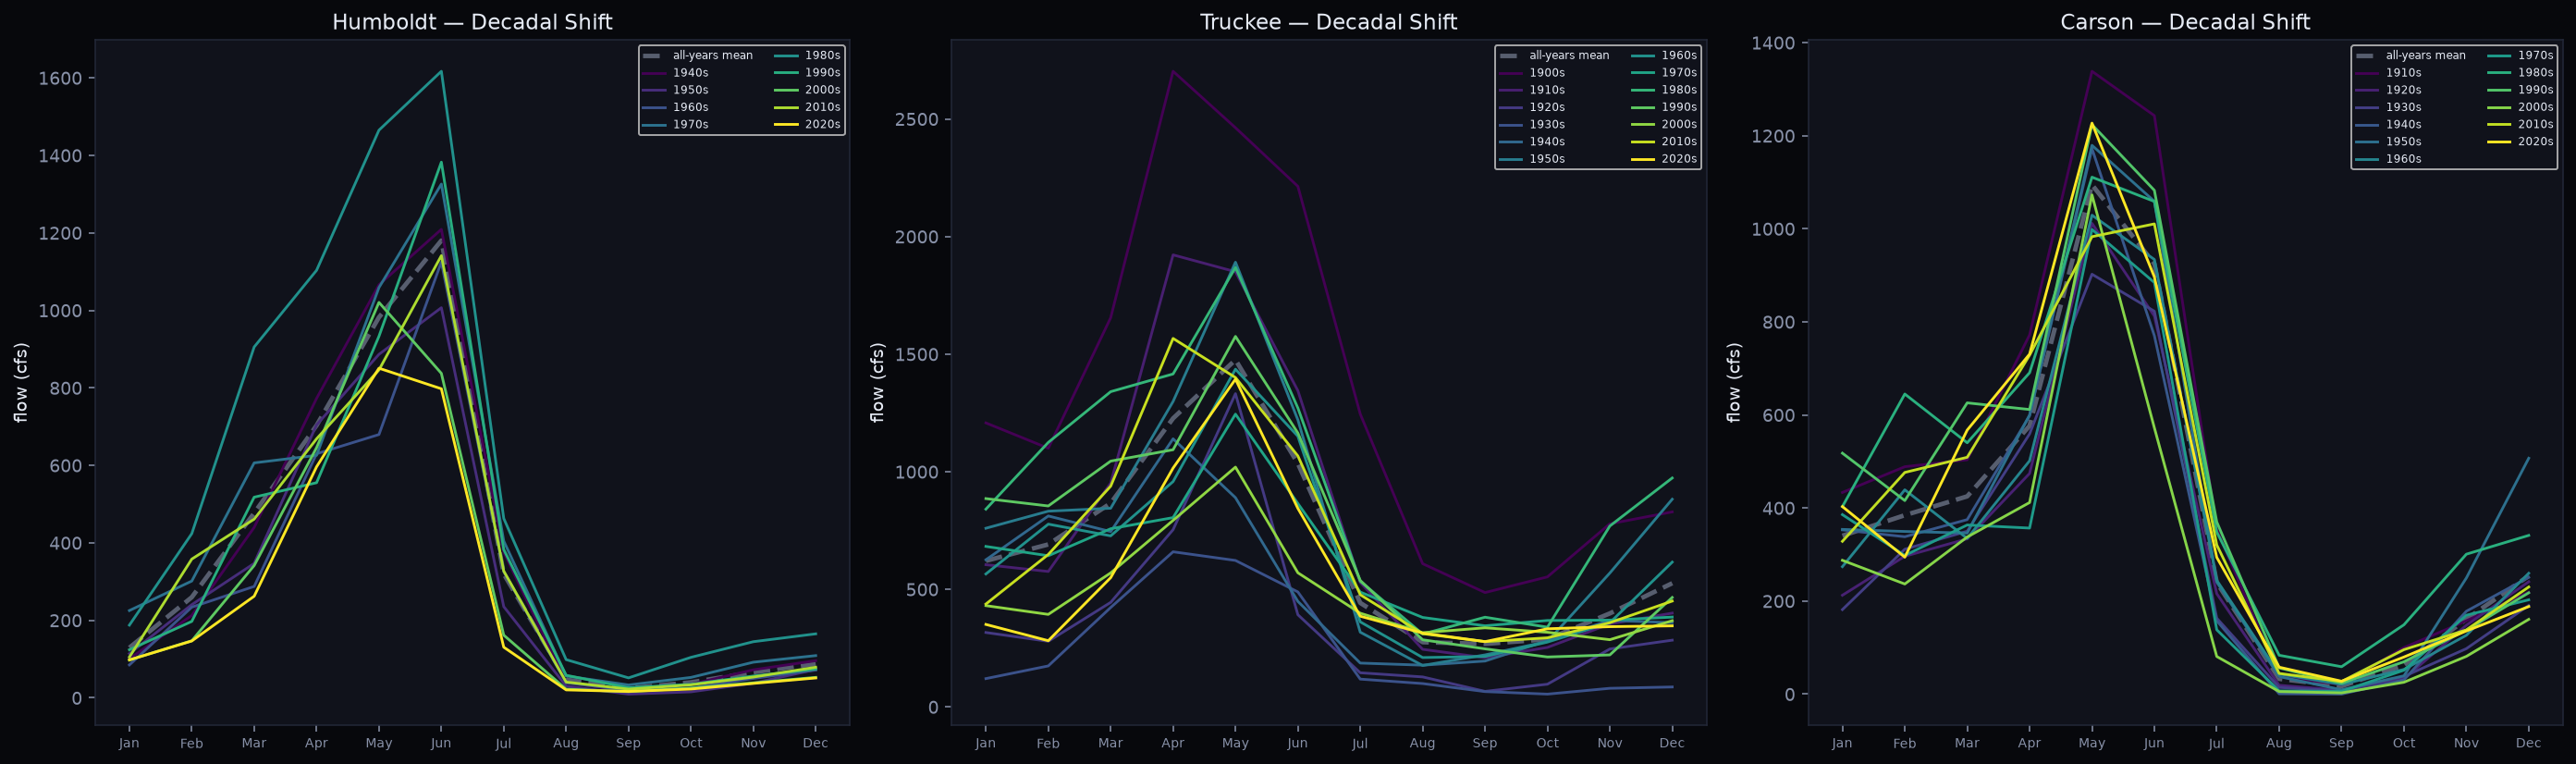

In [23]:
def plot_decadal_shift(obs, title, ax):
    years = sorted(obs.keys())
    overall_mean = np.nanmean([obs[y] for y in years], axis=0)
    decades = {}
    for y in years:
        d = (y // 10) * 10
        decades.setdefault(d, []).append(obs[y])
    cmap = plt.get_cmap("viridis")
    dec_list = sorted(decades.keys())
    span = max(1, len(dec_list) - 1)
    m = range(1, 13)
    ax.plot(m, overall_mean, color=MUTED, lw=2.5, ls="--", label="all-years mean", alpha=0.6)
    for i, d in enumerate(dec_list):
        c = cmap(i / span)
        dmean = np.nanmean(decades[d], axis=0)
        ax.plot(m, dmean, color=c, lw=1.5, label=f"{d}s")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=6, ncol=2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_decadal_shift(hum_c, "Humboldt — Decadal Shift", axes[0])
plot_decadal_shift(tru_c, "Truckee — Decadal Shift", axes[1])
plot_decadal_shift(car_c, "Carson — Decadal Shift", axes[2])
plt.tight_layout()
save(fig, "decadal_shift")
plt.show()

---
## 23. Anomaly Stripes — Annual Departure from Normal

"Warming stripes" for water — each bar is one year, colored by
departure from the long-term average. Blue = wetter, red = drier.
Clusters reveal multi-year drought spells that stress Nevada's
terminal lake ecosystems.

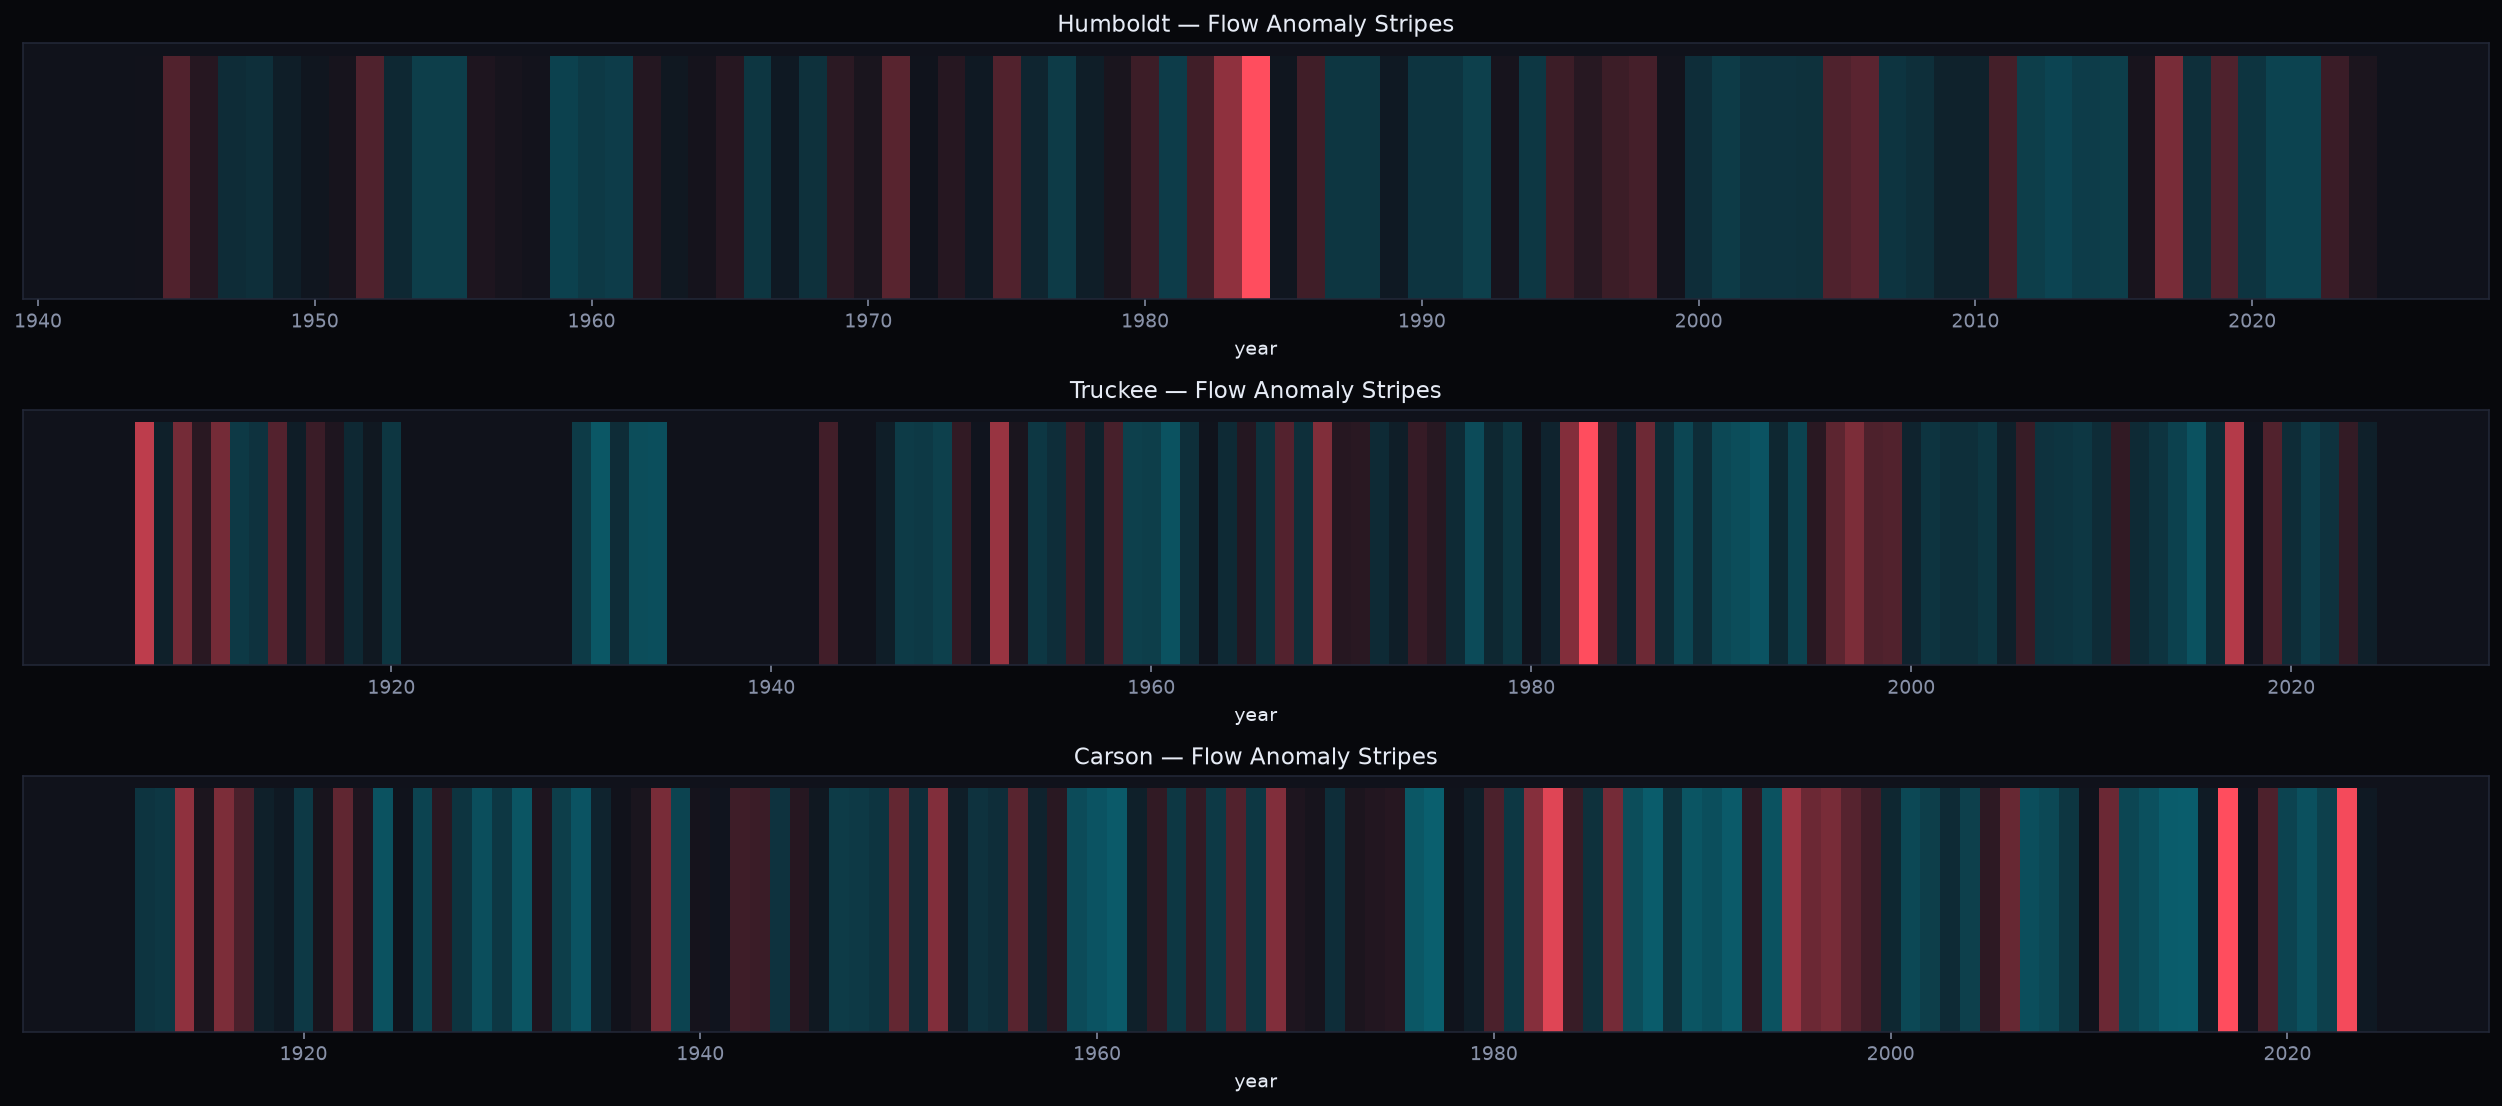

In [24]:
def plot_anomaly_stripes(obs, title, ax):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    normal = np.mean(annual)
    anomalies = annual - normal
    vmax = max(abs(anomalies.min()), abs(anomalies.max()))
    cmap_div = LinearSegmentedColormap.from_list(
        "anomaly", [COOL_BLUE, "#10121b", RED])
    for i, (y, a) in enumerate(zip(years, anomalies)):
        color = cmap_div((a / vmax + 1) / 2)
        ax.bar(y, 1, color=color, width=1.0, bottom=0)
    ax.set_yticks([])
    ax.set_xlabel("year")
    ax.set_title(title)

fig, axes = plt.subplots(3, 1, figsize=(18, 8))
plot_anomaly_stripes(hum_c, "Humboldt — Flow Anomaly Stripes", axes[0])
plot_anomaly_stripes(tru_c, "Truckee — Flow Anomaly Stripes", axes[1])
plot_anomaly_stripes(car_c, "Carson — Flow Anomaly Stripes", axes[2])
plt.tight_layout()
save(fig, "anomaly_stripes")
plt.show()

---
## 24. Cumulative Flow — Water Year Accumulation

Cumulative monthly flow through each water year. In Nevada, the
curve should be nearly flat Oct–Mar (snow storage), then rocket
upward May–Jun (melt), then plateau Jul–Sep (dry).

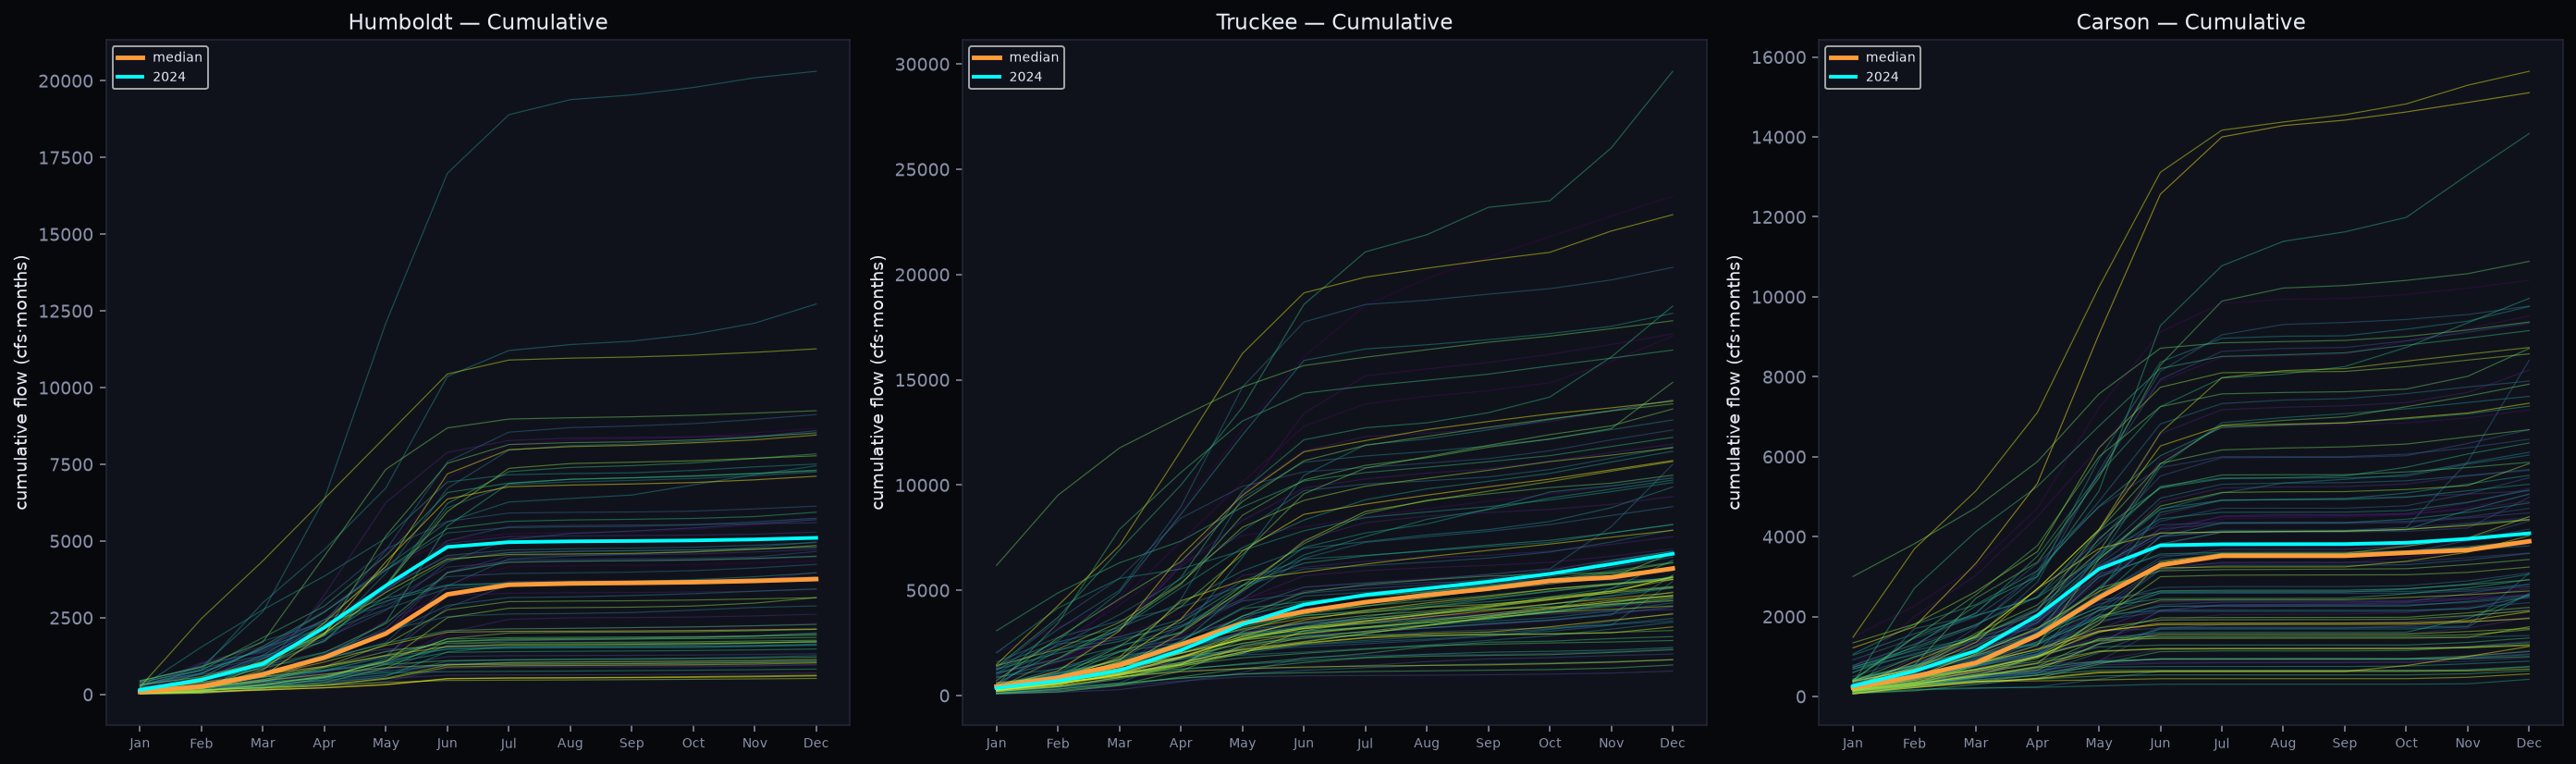

In [25]:
def plot_cumulative(obs, title, ax):
    years = sorted(obs.keys())
    cmap = plt.get_cmap("viridis")
    span = max(years) - min(years) or 1
    for y in years:
        c = cmap((y - min(years)) / span)
        cumul = np.cumsum(obs[y])
        ax.plot(range(1, 13), cumul, color=c, lw=0.6, alpha=0.5)
    stack = np.array([np.cumsum(obs[y]) for y in years])
    median_c = np.median(stack, axis=0)
    ax.plot(range(1, 13), median_c, color=AMBER, lw=2.5, label="median")
    latest = max(years)
    ax.plot(range(1, 13), np.cumsum(obs[latest]), color=CYAN, lw=2,
            label=f"{latest}")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("cumulative flow (cfs·months)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_cumulative(hum_c, "Humboldt — Cumulative", axes[0])
plot_cumulative(tru_c, "Truckee — Cumulative", axes[1])
plot_cumulative(car_c, "Carson — Cumulative", axes[2])
plt.tight_layout()
save(fig, "cumulative")
plt.show()

---
## 25. Return Period Estimate — Annual Peaks

Flood frequency analysis using Weibull plotting position. Critical
for Reno/Sparks flood management on the Truckee, where rain-on-snow
events produce the most dangerous floods (January 1997 flood of record).

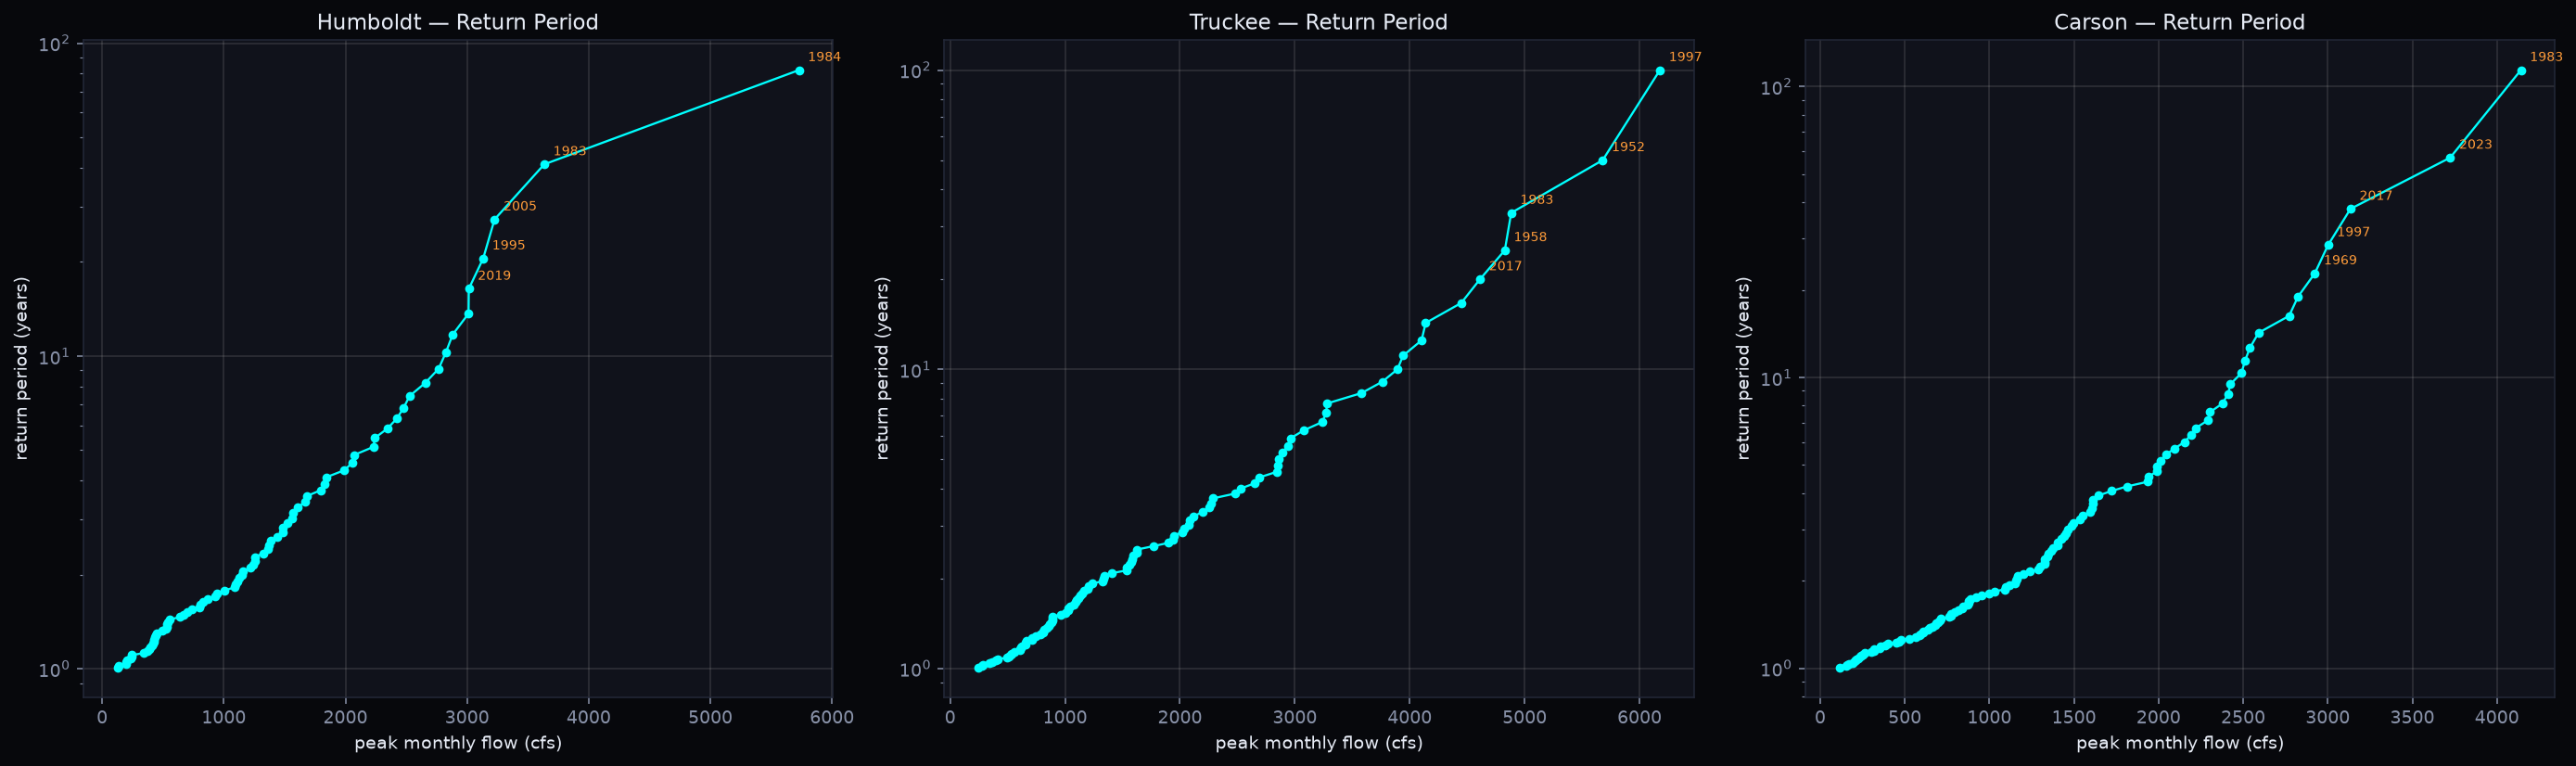

In [26]:
def plot_return_period(obs, title, ax):
    years = sorted(obs.keys())
    peaks = np.array([float(np.nanmax(obs[y])) for y in years])
    n = len(peaks)
    sorted_peaks = np.sort(peaks)[::-1]
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    ax.semilogy(sorted_peaks, return_period, "o-", color=CYAN, ms=4, lw=1.2)
    for i in range(min(5, n)):
        yr_idx = int(np.where(peaks == sorted_peaks[i])[0][0])
        ax.annotate(str(years[yr_idx]), (sorted_peaks[i], return_period[i]),
                    fontsize=7, color=AMBER, xytext=(5, 5),
                    textcoords="offset points")
    ax.set_xlabel("peak monthly flow (cfs)")
    ax.set_ylabel("return period (years)")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_return_period(hum_c, "Humboldt — Return Period", axes[0])
plot_return_period(tru_c, "Truckee — Return Period", axes[1])
plot_return_period(car_c, "Carson — Return Period", axes[2])
plt.tight_layout()
save(fig, "return_period")
plt.show()

---
## 26. Lag-1 Autocorrelogram — Year Memory

Does this year's flow predict next year's? In Nevada, persistent
drought (groundwater depletion, snowpack deficit carry-over) should
produce significant lag-1 autocorrelation — dry begets dry.

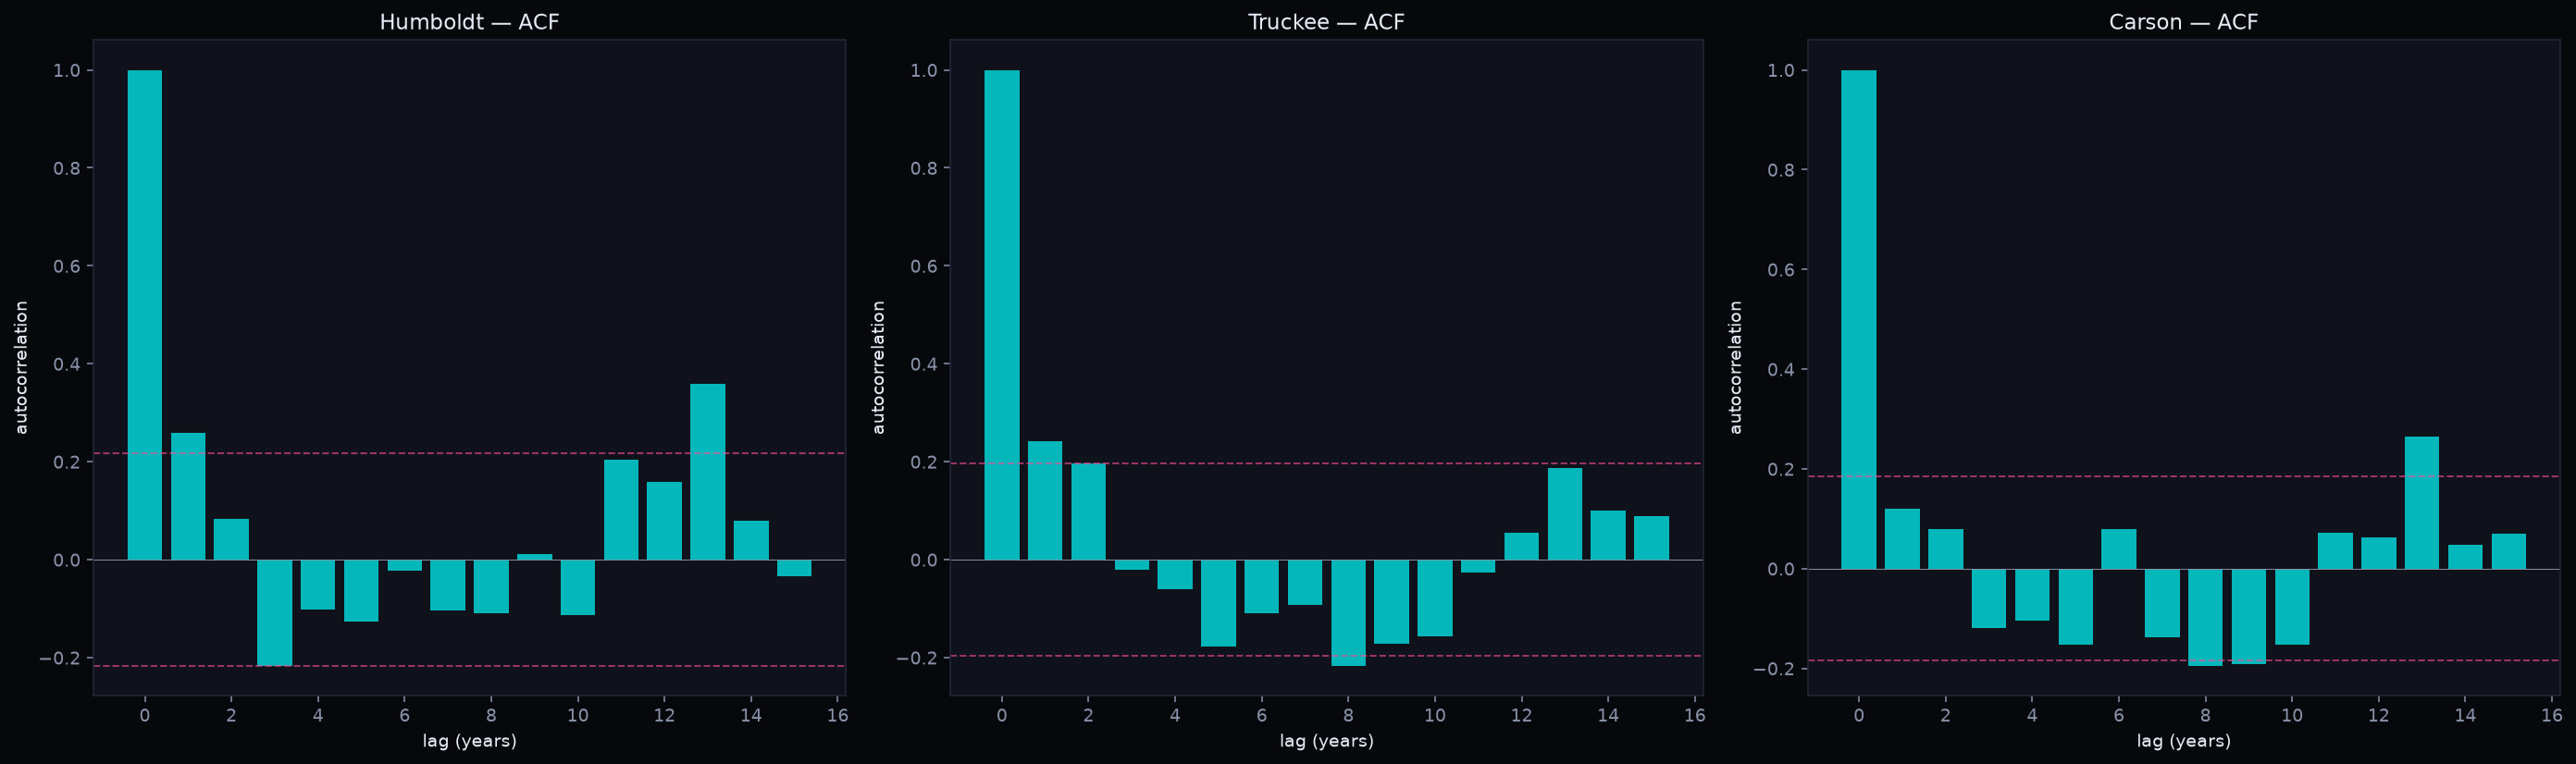

In [34]:
def plot_autocorrelation(obs, title, ax, *, max_lag=15):
    years = sorted(obs.keys())
    annual = np.array([float(np.nanmean(obs[y])) for y in years])
    n = len(annual)
    mean = annual.mean()
    var = annual.var()
    acf = []
    for lag in range(max_lag + 1):
        if lag >= n:
            break
        cov = np.mean((annual[:n-lag] - mean) * (annual[lag:] - mean)) if lag > 0 else var
        acf.append(cov / var if var > 0 else 0)
    lags = range(len(acf))
    ax.bar(lags, acf, color=CYAN, alpha=0.7, width=0.8)
    ci = 1.96 / np.sqrt(n)
    ax.axhline(ci, color=MAGENTA, ls="--", lw=1, alpha=0.6)
    ax.axhline(-ci, color=MAGENTA, ls="--", lw=1, alpha=0.6)
    ax.axhline(0, color=MUTED, lw=0.5)
    ax.set_xlabel("lag (years)")
    ax.set_ylabel("autocorrelation")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_autocorrelation(hum_c, "Humboldt — ACF", axes[0])
plot_autocorrelation(tru_c, "Truckee — ACF", axes[1])
plot_autocorrelation(car_c, "Carson — ACF", axes[2])
plt.tight_layout()
save(fig, "autocorrelation")
plt.show()

---
## 27. Percentile Rank Forecast Context

Where does the most recent year sit in the historical distribution?
Each month ranked against all prior years. Green = above median,
red = below — a quick read on whether the latest year was wet or dry.

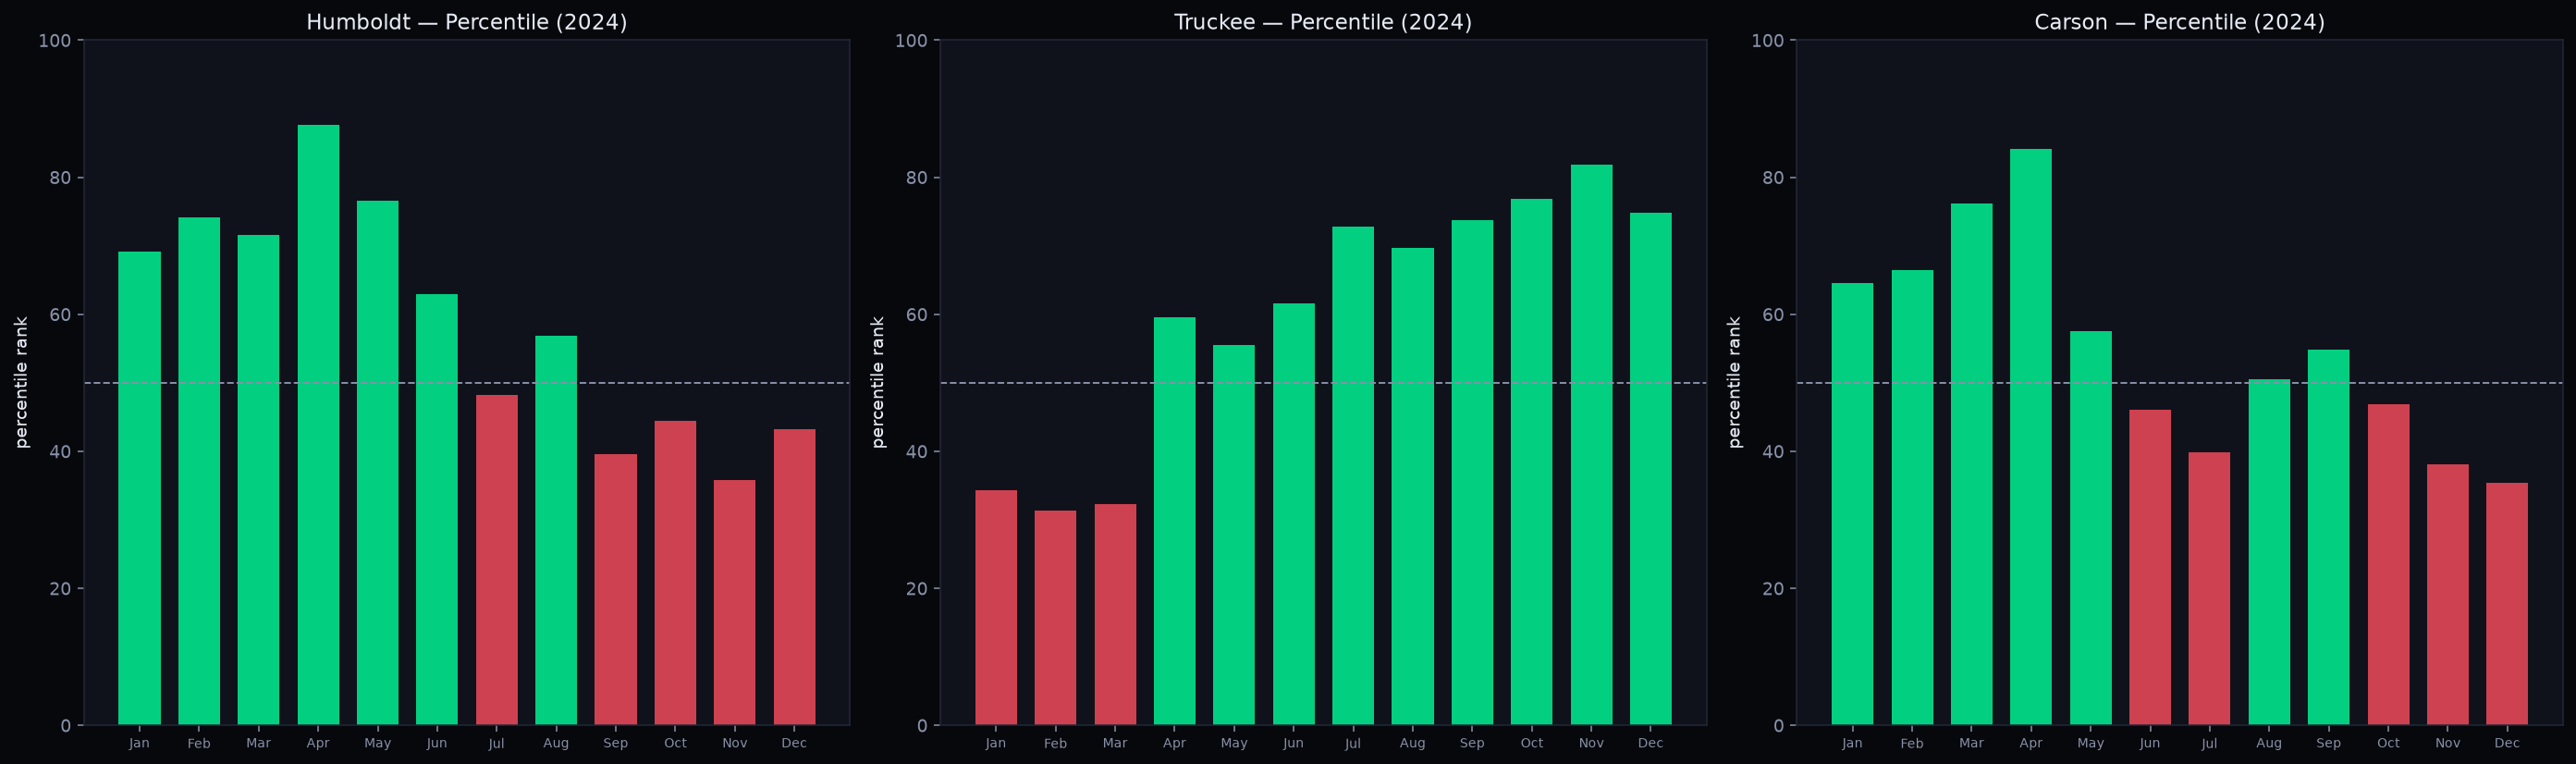

In [35]:
def plot_percentile_context(obs, title, ax):
    years = sorted(obs.keys())
    latest = years[-1]
    stack = np.array([obs[y] for y in years])
    pctiles = []
    for m in range(12):
        col = stack[:, m]
        pct = np.sum(col <= obs[latest][m]) / len(col) * 100
        pctiles.append(pct)
    colors = [LIME if p >= 50 else RED for p in pctiles]
    ax.bar(range(1, 13), pctiles, color=colors, alpha=0.8, width=0.7)
    ax.axhline(50, color=MUTED, ls="--", lw=1)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("percentile rank")
    ax.set_ylim(0, 100)
    ax.set_title(f"{title} ({latest})")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_percentile_context(hum_c, "Humboldt — Percentile", axes[0])
plot_percentile_context(tru_c, "Truckee — Percentile", axes[1])
plot_percentile_context(car_c, "Carson — Percentile", axes[2])
plt.tight_layout()
save(fig, "percentile_context")
plt.show()

---
## 28. Cross-Gauge Correlation

How tightly do the three gauges track each other? The Truckee and
Carson share Sierra Nevada headwaters and should correlate strongly.
The Humboldt, fed by the Ruby Mountains 300 miles east, may diverge —
revealing when the Great Basin interior dries out independently of
the Sierra.

Overlap period: 1946–2024 (79 years)


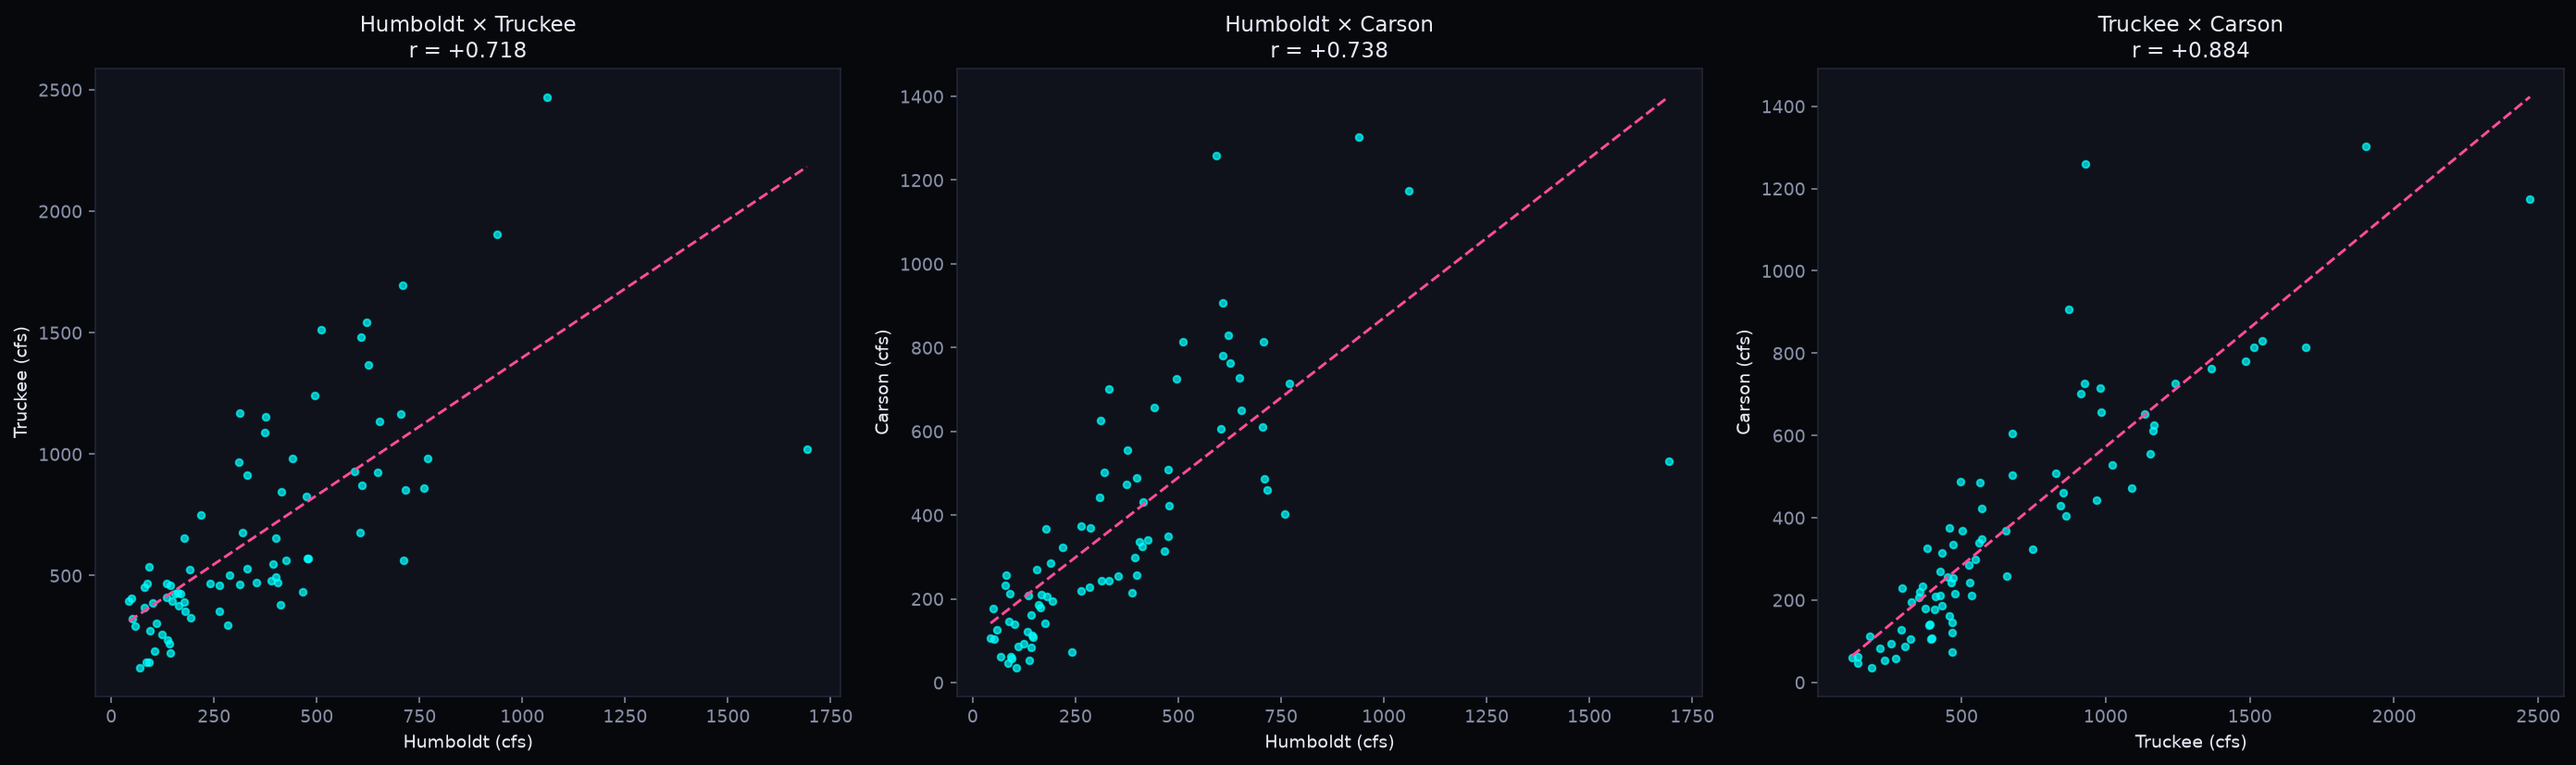

In [29]:
# overlap period — all three rivers
all_years = sorted(set(hum_c) & set(tru_c) & set(car_c))
print(f"Overlap period: {all_years[0]}–{all_years[-1]} ({len(all_years)} years)")

hum_ann = {y: float(np.mean(hum_c[y])) for y in all_years}
tru_ann = {y: float(np.mean(tru_c[y])) for y in all_years}
car_ann = {y: float(np.mean(car_c[y])) for y in all_years}

pairs = [
    ("Humboldt × Truckee", hum_ann, tru_ann),
    ("Humboldt × Carson", hum_ann, car_ann),
    ("Truckee × Carson", tru_ann, car_ann),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (label, a, b) in zip(axes, pairs):
    xs = [a[y] for y in all_years]
    ys = [b[y] for y in all_years]
    r = fm.correlate(a, b)
    ax.scatter(xs, ys, color=CYAN, s=15, alpha=0.7)
    z = np.polyfit(xs, ys, 1)
    xr = np.linspace(min(xs), max(xs), 50)
    ax.plot(xr, np.polyval(z, xr), "--", color=MAGENTA, lw=1.5)
    ax.set_xlabel(label.split(" × ")[0] + " (cfs)")
    ax.set_ylabel(label.split(" × ")[1] + " (cfs)")
    ax.set_title(f"{label}\nr = {r:+.3f}")
plt.tight_layout()
save(fig, "cross_gauge")
plt.show()

---
## 29. Forecast: Naive Climatological Projection

What does the historical record predict for next year? The simplest
forecast: mean monthly hydrograph with P10–P90 bounds. In Nevada's
variable climate, the confidence band is wide — a testament to the
feast-or-famine nature of Great Basin hydrology.

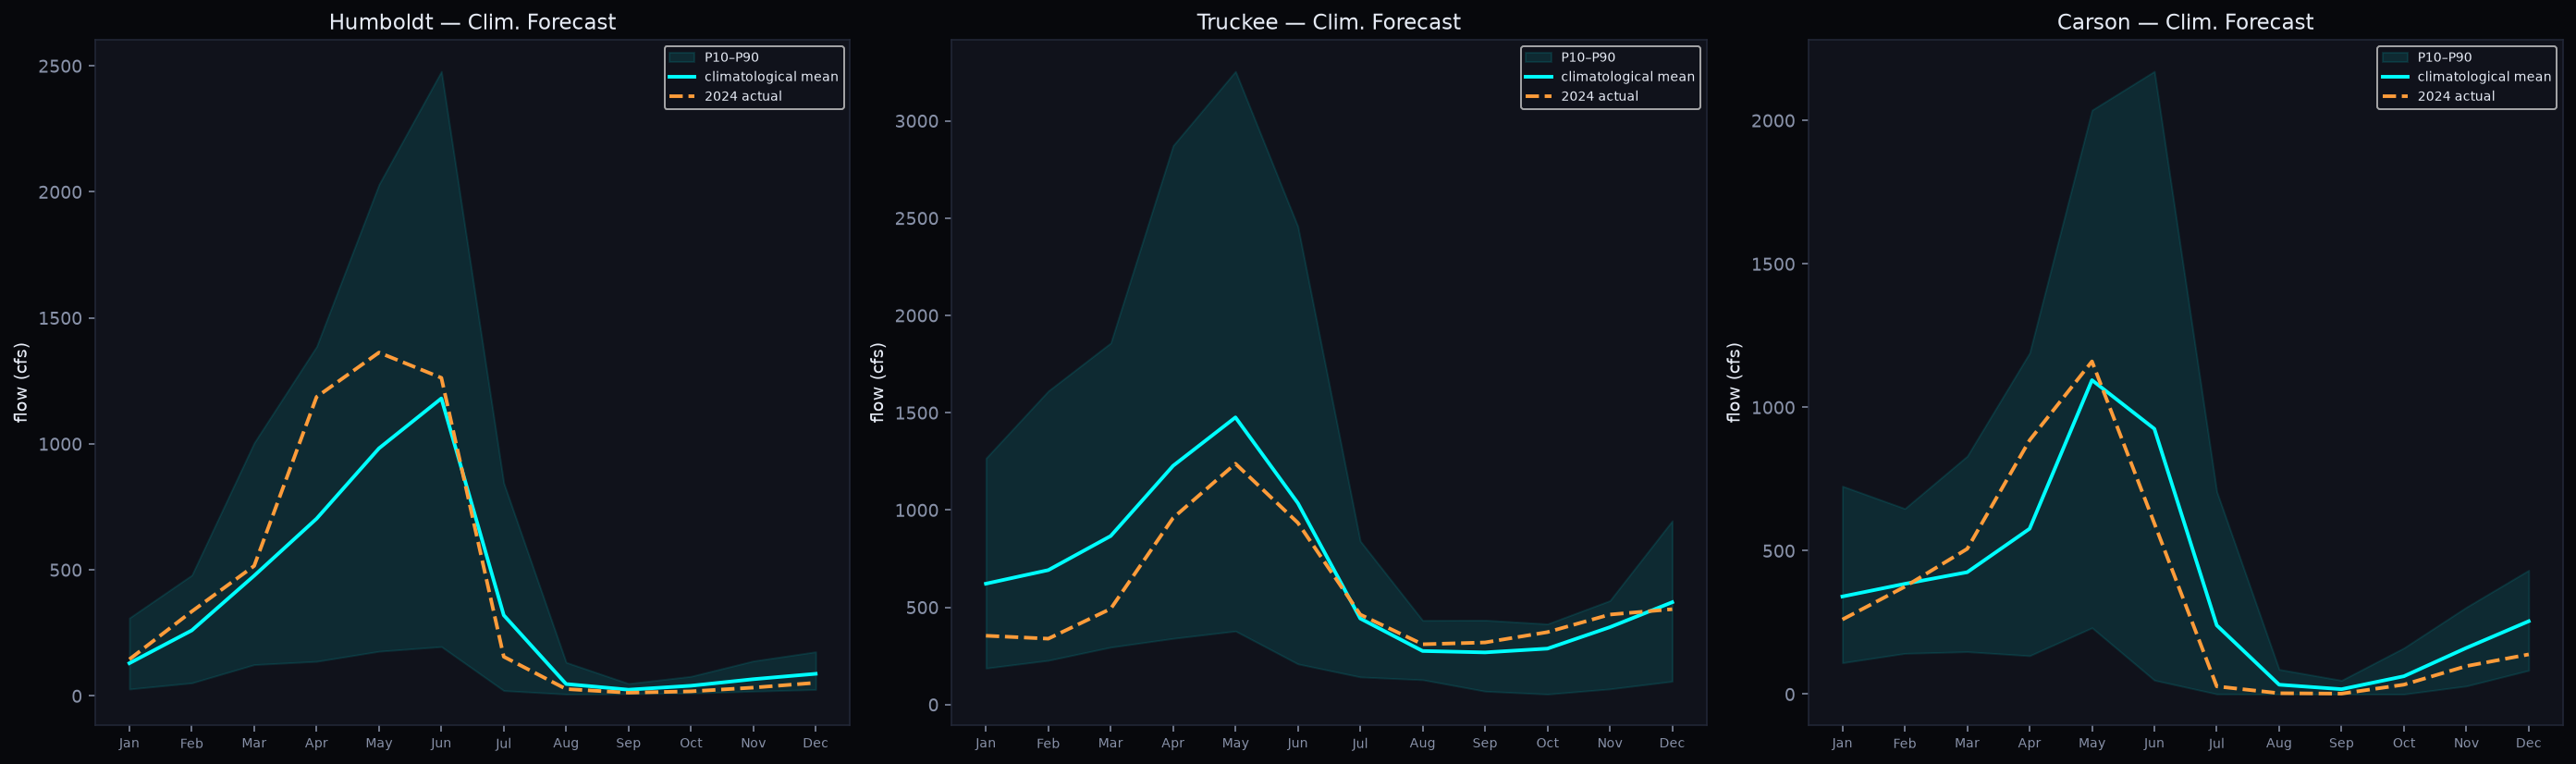

In [30]:
def plot_climatological_forecast(obs, title, ax):
    years = sorted(obs.keys())
    latest = years[-1]
    stack = np.array([obs[y] for y in years])
    mean = np.nanmean(stack, axis=0)
    p10 = np.nanpercentile(stack, 10, axis=0)
    p90 = np.nanpercentile(stack, 90, axis=0)
    m = range(1, 13)
    ax.fill_between(m, p10, p90, color=CYAN, alpha=0.1, label="P10–P90")
    ax.plot(m, mean, color=CYAN, lw=2, label="climatological mean")
    ax.plot(m, obs[latest], color=AMBER, lw=2, ls="--",
            label=f"{latest} actual")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(title)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_climatological_forecast(hum_c, "Humboldt — Clim. Forecast", axes[0])
plot_climatological_forecast(tru_c, "Truckee — Clim. Forecast", axes[1])
plot_climatological_forecast(car_c, "Carson — Clim. Forecast", axes[2])
plt.tight_layout()
save(fig, "clim_forecast")
plt.show()

---
## 30. ENSO-Conditioned Forecast

If we know this winter's ENSO state, can we narrow the forecast?
In Nevada — where ENSO is a strong driver — the composite for the
current phase should meaningfully narrow the confidence interval
compared to raw climatology.

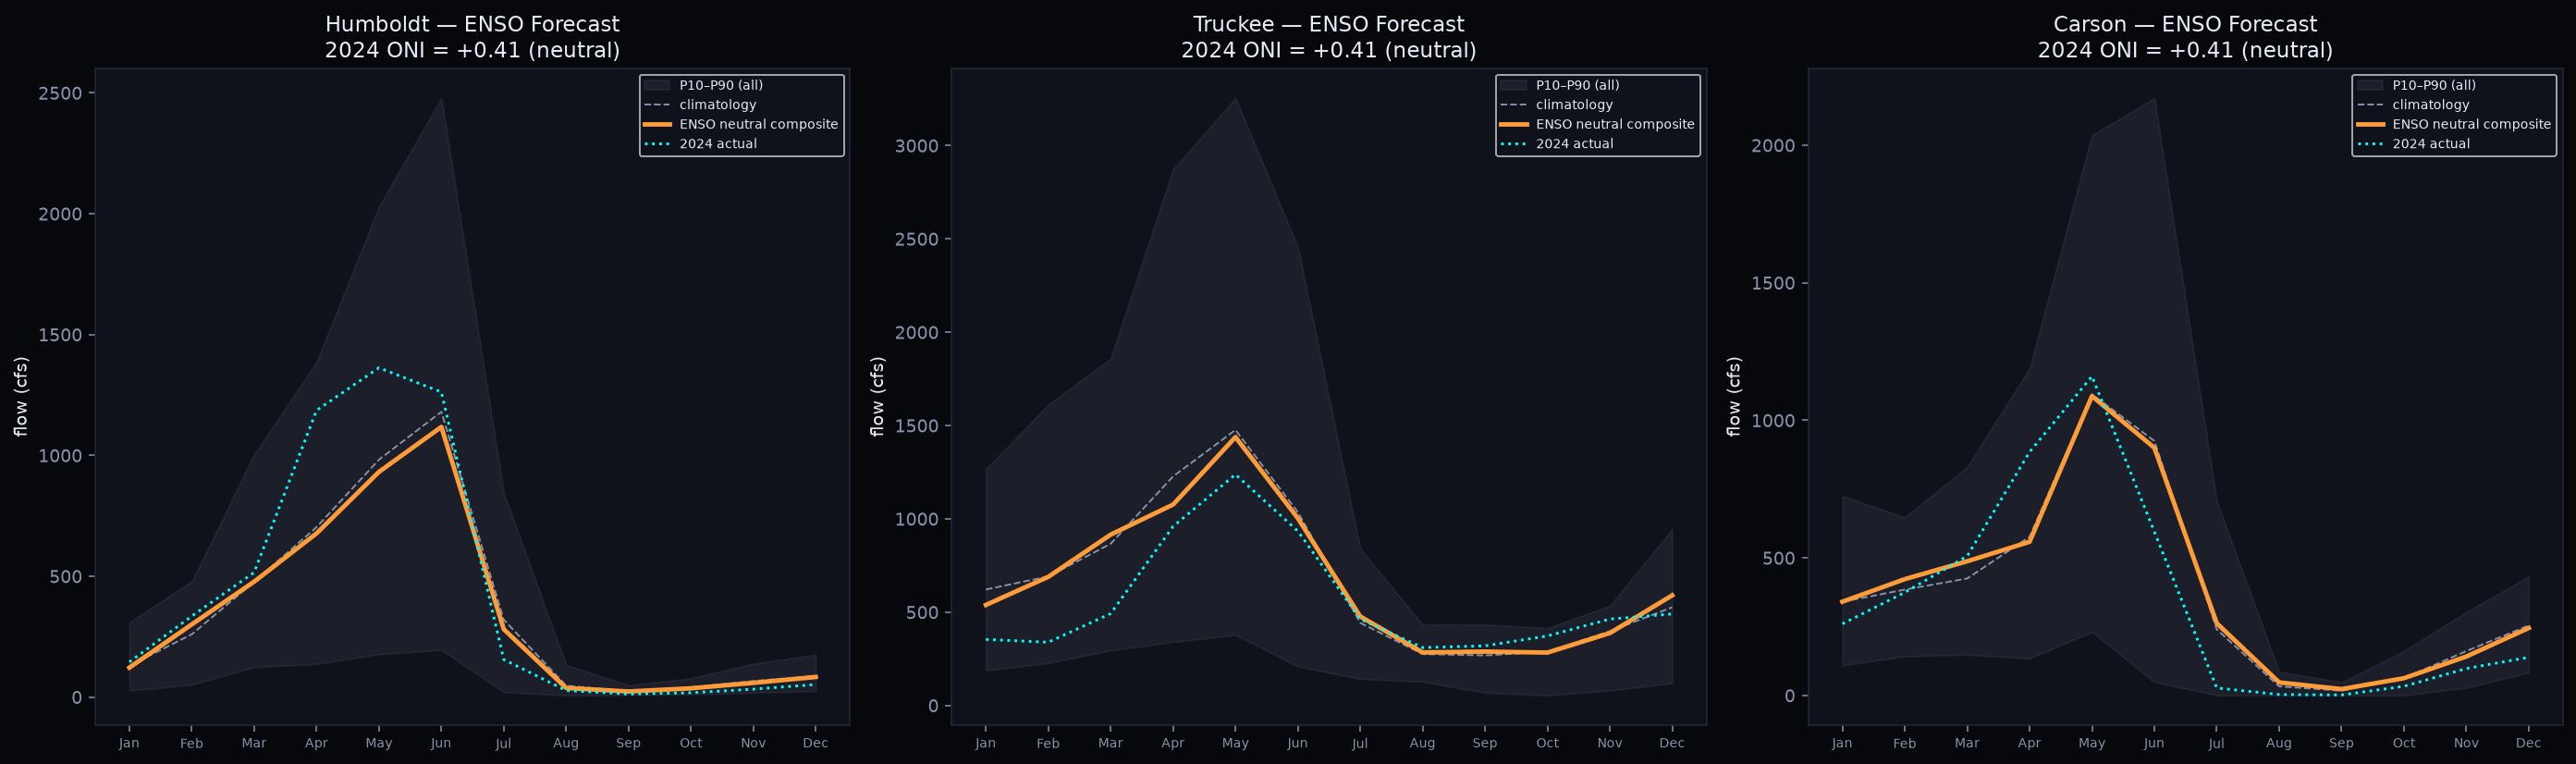

In [31]:
def plot_enso_forecast(obs, oni_idx, title, ax):
    clean = complete_years(obs)
    latest_oni_year = max(y for y in oni_idx if y in clean)
    latest_oni = oni_idx[latest_oni_year]
    phase = "warm" if latest_oni > 0.5 else "cool" if latest_oni < -0.5 else "neutral"
    pc = fm.composite_hydrographs(clean, oni_idx)
    forecast = {"warm": pc.warm, "neutral": pc.neutral, "cool": pc.cool}[phase]
    stack = np.array([clean[y] for y in sorted(clean)])
    p10 = np.nanpercentile(stack, 10, axis=0)
    p90 = np.nanpercentile(stack, 90, axis=0)
    m = range(1, 13)
    ax.fill_between(m, p10, p90, color=MUTED, alpha=0.1, label="P10–P90 (all)")
    ax.plot(m, np.nanmean(stack, axis=0), color=MUTED, lw=1, ls="--", label="climatology")
    color = RED if phase == "warm" else COOL_BLUE if phase == "cool" else AMBER
    ax.plot(m, forecast, color=color, lw=2.5,
            label=f"ENSO {phase} composite")
    ax.plot(m, clean[latest_oni_year], color=CYAN, lw=1.5, ls=":",
            label=f"{latest_oni_year} actual")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=7)
    ax.set_ylabel("flow (cfs)")
    ax.set_title(f"{title}\n{latest_oni_year} ONI = {latest_oni:+.2f} ({phase})")
    ax.legend(fontsize=7)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_enso_forecast(hum_c, oni, "Humboldt — ENSO Forecast", axes[0])
plot_enso_forecast(tru_c, oni, "Truckee — ENSO Forecast", axes[1])
plot_enso_forecast(car_c, oni, "Carson — ENSO Forecast", axes[2])
plt.tight_layout()
save(fig, "enso_forecast")
plt.show()

---
## 31. Multi-Metric Dashboard

Key metrics at a glance for all three gauges — a one-table summary
of Nevada's hydrologic character. The driest state in the nation,
where every drop is accounted for.

In [32]:
def compute_metrics(obs):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual = [float(np.mean(clean[y])) for y in years]
    peaks = [float(np.max(clean[y])) for y in years]
    lows = [float(np.min(clean[y][6:9])) for y in years]
    flash = [fm.flashiness(clean[y]) for y in years]
    mean_flow = np.mean([clean[y] for y in years], axis=0)
    cot = fm.center_of_timing(mean_flow)
    sr = np.mean([fm.seasonal_ratio(clean[y]) for y in years])
    return {
        "Mean Flow": f"{np.mean(annual):,.0f} cfs",
        "Mean Peak": f"{np.mean(peaks):,.0f} cfs",
        "Mean Low": f"{np.mean(lows):,.0f} cfs",
        "Center of Timing": f"{cot:.1f}",
        "Seasonal Ratio": f"{sr:.2f}",
        "Mean Flashiness": f"{np.mean(flash):.4f}",
        "Record": f"{years[0]}–{years[-1]}",
        "N Years": len(years),
    }

print(f"{'Metric':<22} {'Humboldt':>14} {'Truckee':>14} {'Carson':>14}")
print("─" * 66)
mh = compute_metrics(hum_c)
mt = compute_metrics(tru_c)
mc = compute_metrics(car_c)
for k in mh:
    print(f"{k:<22} {str(mh[k]):>14} {str(mt[k]):>14} {str(mc[k]):>14}")

Metric                       Humboldt        Truckee         Carson
──────────────────────────────────────────────────────────────────
Mean Flow                     360 cfs        676 cfs        376 cfs
Mean Peak                   1,334 cfs      1,788 cfs      1,257 cfs
Mean Low                       23 cfs        238 cfs         16 cfs
Center of Timing                  5.1            5.5            5.2
Seasonal Ratio                   0.87           1.32           1.49
Mean Flashiness                0.6286         0.3955         0.5935
Record                      1944–2024      1907–2024      1912–2024
N Years                            81             99            113


---
## 32. Summary Statistics

Full statistical summary for each gauge — trend tests, teleconnections,
timing drift, and regime classification.

In [33]:
def full_summary(obs, name):
    clean = complete_years(obs)
    years = sorted(clean.keys())
    annual = np.array([float(np.mean(clean[y])) for y in years])
    peaks = np.array([float(np.max(clean[y])) for y in years])
    lows = np.array([float(np.min(clean[y][6:9])) for y in years])
    mean_hydro = np.mean([clean[y] for y in years], axis=0)

    mk_ann = fm.mann_kendall(annual)
    mk_peak = fm.mann_kendall(peaks)
    mk_low = fm.mann_kendall(lows)
    tt = fm.center_of_timing_trend(clean)

    oni_r = fm.correlate({y: float(np.max(clean[y])) for y in years}, oni)
    pdo_r = fm.correlate({y: float(np.max(clean[y])) for y in years}, pdo)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Record:              {years[0]}–{years[-1]} ({len(years)} complete years)")
    print(f"  Mean annual flow:    {np.mean(annual):,.1f} cfs")
    print(f"  Std annual flow:     {np.std(annual):,.1f} cfs")
    print(f"  CV (std/mean):       {np.std(annual)/np.mean(annual):.2f}")
    print(f"  Mean peak monthly:   {np.mean(peaks):,.1f} cfs")
    print(f"  Mean summer low:     {np.mean(lows):,.1f} cfs")
    print(f"  Center of timing:    {fm.center_of_timing(mean_hydro):.2f} (month)")
    print(f"  Mean flashiness:     {np.mean([fm.flashiness(clean[y]) for y in years]):.4f}")
    print(f"  Mean seasonal ratio: {np.mean([fm.seasonal_ratio(clean[y]) for y in years]):.2f}")
    print(f"  ──── Trends ────")
    print(f"  Annual mean trend:   {mk_ann.trend} (τ={mk_ann.tau:+.3f}, p={mk_ann.p:.4f})")
    print(f"  Peak flow trend:     {mk_peak.trend} (τ={mk_peak.tau:+.3f}, p={mk_peak.p:.4f})")
    print(f"  Summer low trend:    {mk_low.trend} (τ={mk_low.tau:+.3f}, p={mk_low.p:.4f})")
    print(f"  Timing drift:        {tt.days_per_decade:+.1f} days/decade ({tt.trend})")
    print(f"  Annual Sen's slope:  {fm.sens_slope(annual):+.2f} cfs/yr")
    print(f"  ──── Teleconnections ────")
    print(f"  Peak × ONI (ENSO):   r = {oni_r:+.3f}")
    print(f"  Peak × PDO:          r = {pdo_r:+.3f}")

full_summary(hum_c, "Humboldt River near Carlin, NV (10321000)")
full_summary(tru_c, "Truckee River at Reno, NV (10348000)")
full_summary(car_c, "Carson River near Fort Churchill, NV (10312000)")


  Humboldt River near Carlin, NV (10321000)
  Record:              1944–2024 (81 complete years)
  Mean annual flow:    359.7 cfs
  Std annual flow:     276.0 cfs
  CV (std/mean):       0.77
  Mean peak monthly:   1,334.0 cfs
  Mean summer low:     23.0 cfs
  Center of timing:    5.07 (month)
  Mean flashiness:     0.6286
  Mean seasonal ratio: 0.87
  ──── Trends ────
  Annual mean trend:   none (τ=-0.057, p=0.4555)
  Peak flow trend:     none (τ=-0.086, p=0.2552)
  Summer low trend:    none (τ=+0.052, p=0.4907)
  Timing drift:        -0.5 days/decade (none)
  Annual Sen's slope:  -0.75 cfs/yr
  ──── Teleconnections ────
  Peak × ONI (ENSO):   r = -0.019
  Peak × PDO:          r = +0.092

  Truckee River at Reno, NV (10348000)
  Record:              1907–2024 (99 complete years)
  Mean annual flow:    676.1 cfs
  Std annual flow:     447.1 cfs
  CV (std/mean):       0.66
  Mean peak monthly:   1,787.7 cfs
  Mean summer low:     237.7 cfs
  Center of timing:    5.47 (month)
  Mean flas

---

## Report Complete

**Nevada — The Driest State** — 32 analytics panels across 3 gauges,
covering 80–115 years of observed discharge in the Great Basin. Key findings:

- **Regime:** Arid snowmelt — Sierra Nevada and Ruby Mountain snow drives
  a sharp May–June freshet; near-zero flow by late summer
- **Terminal basins:** All three rivers are endorheic — Humboldt → Humboldt Sink,
  Truckee → Pyramid Lake, Carson → Carson Sink. No water reaches the ocean.
- **ENSO dominance:** Nevada sits in one of the strongest ENSO teleconnection
  zones in the continental US — El Niño winters deliver heavy Sierra snowpack
- **Climate sensitivity:** At the southern edge of the snowmelt zone, Nevada's
  rivers are acutely sensitive to warming — small temperature increases flip
  snow to rain at critical elevation bands
- **Variability:** Extreme coefficient of variation — feast-or-famine hydrology
  where a single El Niño winter can deliver more water than several dry years combined

All data: USGS NWIS (federal public domain). All figures saved to `notebooks/figures/nevada_*.png`.